In [37]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Para el excel del mercado laboral

In [38]:
%pip install xlrd
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Para grafos

In [39]:
pip install libpysal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [40]:
!pip install matplotlib pyarrow
%pip install geopandas, libpysal, pickle, libpysal


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'geopandas,'

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
import pandas as pd
import json
import os
from typing import Dict, Union
import seaborn as sns
import geopandas as gpd
import pickle

#Limpieza de datos
from limpieza.votos import limpieza_votos_partidos, generar_columnas_pct_votos, SLOT_MAPPING_DEFAULT
from limpieza.rentas import procesar_archivo_ine, procesar_archivo_gini, procesar_fuente_ingresos
from limpieza.paro_contratos import limpiar_y_exportar_sepe
from limpieza.superficie import procesar_geografia_municipios
from limpieza.poblacion import procesar_poblacion_maestro
from limpieza.funciones_genericas_limpieza import leer_json, leer_archivo_csv
from limpieza.renta_navarra import generar_renta_con_navarra
from limpieza.edad_media import procesar_edad_media_municipios, procesar_edad_media_provincias

#EDA
from EDA.demografia_superficie import eda_demografia_superficie
from EDA.edad_media import eda_edad_media
from EDA.mercado_laboral import eda_mercado_laboral
from EDA.desigualdad_renta import gestion_nulos_desigualdad, eda_gini_p80p20, analizar_similitud_vecinal_economica
from EDA.fuente_ingresos_renta import eda_fuente_ingresos
from EDA.indicadores_renta import eda_indicadores_renta, visualizar_histogramas_renta
from EDA.votos import eda_votos_granularidad_total, analizar_umbral_votos_nacional, participacion_electoral, participacion_electoral_100, eda_slots_pct_votos
from EDA.funciones_generales import unificar_datos_eda, imputar_datos_socioeconomicos, analizar_correlaciones_eda
from EDA.grafos_estructura import generar_grafo_adyacencia, visualizar_grafo_maestro

# Función ETL limpieza
Creamos una función la cual segun los años nos crea el listado de bases datos a gtraves de procesar los datos en sucio y transformarlos en data limpia.

In [42]:
def ETL_limpieza(year: Union[int, str], config_path: str = "config_path.json") -> Dict[str, pd.DataFrame]:
    """
    Funcion orquestadora ETL de los archivos de la carpeta "limpieza".
    Orquesta la ejecucion de funciones individuales de limpieza, gestiona la
    cache segun el estado de los archivos y carga los resultados
    en memoria inyectandolos como variables globales.
    Args:
        year (Union[int, str]): Anio objetivo para procesar los datos.
        config_path (str, optional): Ruta al archivo JSON de configuracion. Por defecto "config_path.json".
    Returns:
        Dict[str, pd.DataFrame]: Diccionario con los DataFrames instanciados.
    Raises:
        ValueError: Si el anio proporcionado no esta definido en el config.
    """
    year_str = str(year)

    config = leer_json(config_path)

    if year_str not in config:
        raise ValueError(f"El anio {year_str} no existe en el archivo {config_path}.")

    raw_paths = config[year_str]["raw"]
    proc_paths = config[year_str]["processed"]

    dataframes: Dict[str, pd.DataFrame] = {}

    for clave, ruta_procesada in proc_paths.items():
        nombre_df = f"df_{year_str}_{clave}"
        es_carpeta = "carpeta" in clave.lower()

        ya_procesado = False
        archivos_votos_esperados = []

        if clave == "carpeta_votos":
            archivos_votos_esperados = [
                f"arbol_candidaturas_{year_str}.json",
                f"candidaturas_ideologia_{year_str}.json",
                f"maestro_ideologia_{year_str}.json",
                f"Votos_Agrupados_Padres_{year_str}.csv",
                f"Votos_Granularidad_Total_{year_str}.csv"
            ]
            if os.path.exists(ruta_procesada):
                ya_procesado = all(
                    os.path.exists(os.path.join(ruta_procesada, arch))
                    for arch in archivos_votos_esperados
                )
        else:
            ya_procesado = os.path.exists(ruta_procesada)

        if not ya_procesado:
            if es_carpeta:
                os.makedirs(ruta_procesada, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(ruta_procesada), exist_ok=True)

            try:
                if clave in ["poblacion_csv", "poblacion_json"]:
                    ruta_json = proc_paths["poblacion_json"]
                    ruta_csv = proc_paths["poblacion_csv"]
                    if not (os.path.exists(ruta_json) and os.path.exists(ruta_csv)):
                        procesar_poblacion_maestro(
                            path_lectura=raw_paths["poblacion"],
                            path_salida_json=ruta_json,
                            path_salida_csv=ruta_csv
                        )

                elif clave == "paro_contratos":
                    limpiar_y_exportar_sepe(raw_paths["paro_contratos"], ruta_procesada)

                elif clave == "geografia":
                    procesar_geografia_municipios(raw_paths["geografia"], ruta_procesada)

                elif clave == "carpeta_votos":
                    limpieza_votos_partidos(
                        fichero_cis=raw_paths["ideologias"],
                        fichero_03=raw_paths["votos_candidaturas"],
                        fichero_05=raw_paths["votos_municipios_totales"],
                        fichero_06=raw_paths["Votos_candidaturas_agrupados"],
                        ruta_guardado=ruta_procesada,
                        anio=year_str
                    )

                elif clave == "votos_pct":
                    generar_columnas_pct_votos(
                        csv_votos_granular=os.path.join(proc_paths["carpeta_votos"], f"Votos_Granularidad_Total_{year_str}.csv"),
                        anio=year_str,
                        output_file=ruta_procesada
                    )

                elif clave == "datos_unificados":
                    unificar_datos_eda(int(year_str))

                elif clave == "renta_disponible":
                    procesar_archivo_ine(raw_paths["renta_disponible"], ruta_procesada)

                elif clave == "GINI_P80P20":
                    procesar_archivo_gini(raw_paths["GINI_P80P20"], ruta_procesada)

                elif clave == "fuente_ingresos":
                    procesar_fuente_ingresos(raw_paths["fuente_ingresos"], ruta_procesada)

                elif clave == "renta_navarra":
                    generar_renta_con_navarra(año=int(year_str))

                elif clave == "edad_media_municipios":
                    procesar_edad_media_municipios(
                        raw_paths["edad_media_municipios"], int(year_str), ruta_procesada
                    )

                elif clave == "edad_media_provincias":
                    procesar_edad_media_provincias(
                        raw_paths["edad_media_provincias"], int(year_str), ruta_procesada
                    )

            except Exception as e:
                print(f"Error al procesar '{clave}': {e}")

        # --- CARGA DE DATOS EN MEMORIA ---
        if not es_carpeta:
            if os.path.exists(ruta_procesada):
                try:
                    if ruta_procesada.endswith('.csv'):
                        dataframes[nombre_df] = leer_archivo_csv(ruta_procesada, decimal='.')
                    elif ruta_procesada.endswith('.json'):
                        dataframes[nombre_df] = pd.read_json(ruta_procesada)
                except Exception as e:
                    print(f"Error al cargar archivo '{nombre_df}': {e}")

        elif clave == "carpeta_votos":
            for archivo in archivos_votos_esperados:
                ruta_archivo = os.path.join(ruta_procesada, archivo)

                if os.path.exists(ruta_archivo):
                    nombre_sin_ext = os.path.splitext(archivo)[0]
                    nombre_df_carpeta = f"df_{year_str}_{nombre_sin_ext}"

                    try:
                        if archivo.endswith('.csv'):
                            dataframes[nombre_df_carpeta] = leer_archivo_csv(ruta_archivo, decimal='.')
                        elif archivo.endswith('.json'):
                            dataframes[nombre_df_carpeta] = pd.read_json(ruta_archivo)
                    except Exception as e:
                        print(f"Error al cargar el archivo '{archivo}': {e}")

    print(f"\nETL COMPLETADO ({year_str})")
    print("DataFrames generados y listos como variables:")
    for df_name in dataframes.keys():
        print(f"{df_name}")

    globals().update(dataframes)

    return dataframes

In [43]:
#dataframes = ETL_limpieza(2023, "config_path.json")

In [44]:
dataframes_2019 = ETL_limpieza(2019, "config_path.json")

[OK] 8131 municipios, 16 slots guardados en data_processed/data_end/2019/votos_pct_2019.csv
INICIANDO UNIFICACIÓN Y AUDITORÍA DE INTEGRIDAD (2019)

Auditoría de municipios extintos/fusionados contra el padrón:
 -> Dataset 'Gini/P80P20': 8 municipios extintos/fusionados detectados.
    - Descartado ID: 04039 (Darrical)
    - Descartado ID: 12066 (Gatova)
    - Descartado ID: 15026 (Cesuras)
    - Descartado ID: 15063 (Oza dos Ríos)
    - Descartado ID: 17122 (Palmerola)
    - Descartado ID: 36011 (Cerdedo)
    - Descartado ID: 36012 (Cotobade)
    - Descartado ID: 48916 (Usansolo)
 -> Dataset 'Renta Disponible': 8 municipios extintos/fusionados detectados.
    - Descartado ID: 04039 (Darrical)
    - Descartado ID: 12066 (Gatova)
    - Descartado ID: 15026 (Cesuras)
    - Descartado ID: 15063 (Oza dos Ríos)
    - Descartado ID: 17122 (Palmerola)
    - Descartado ID: 36011 (Cerdedo)
    - Descartado ID: 36012 (Cotobade)
    - Descartado ID: 48916 (Usansolo)
 -> Dataset 'Fuente Ingresos': 

# EDA 2019
PAra esto planteo fases y objetivos para no perder la idea durante el proceso

## Fase 1: Análisis de "Salud" y Distribución (Univariante)
En esta fase analizamos cada fichero por separado. Trabajaremos con los datos de 2019.

### 1.1. Demografía y Superficie, contexto físico
* Calcular la Densidad de Población (población_total / superficie_km2).

RESUMEN DEMOGRÁFICO
Población total: 47,026,208 habitantes



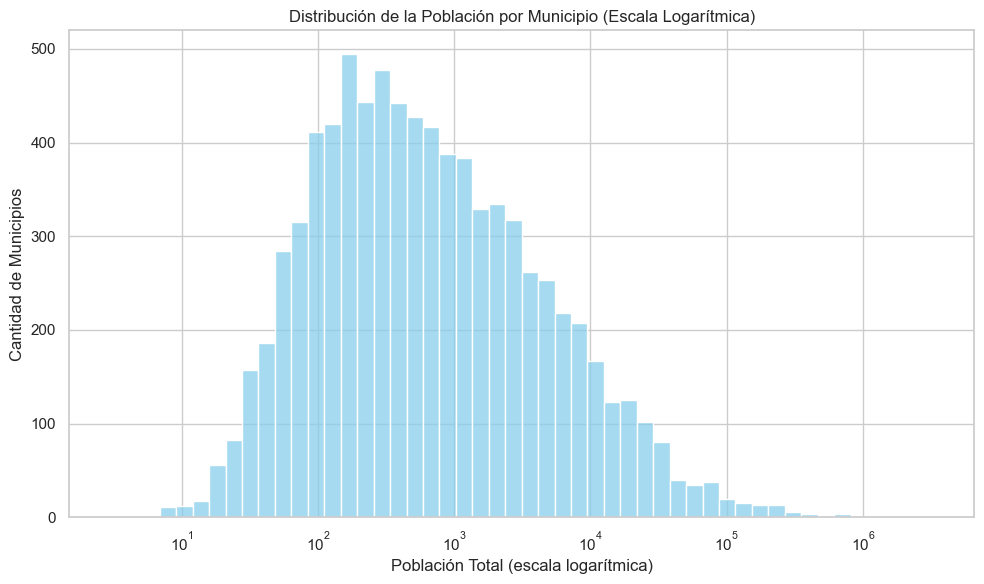

10 MUNICIPIOS MÁS POBLADOS
 1. Madrid                         |  3,266,126 habs.
 2. Barcelona                      |  1,636,762 habs.
 3. València                       |    794,288 habs.
 4. Sevilla                        |    688,592 habs.
 5. Zaragoza                       |    674,997 habs.
 6. Málaga                         |    574,654 habs.
 7. Murcia                         |    453,258 habs.
 8. Palma                          |    416,065 habs.
 9. Palmas de Gran Canaria, Las    |    379,925 habs.
10. Bilbao                         |    346,843 habs.

10 MUNICIPIOS MENOS POBLADOS
 1. Illán de Vacas                 |          3 habs.
 2. Villarroya                     |          5 habs.
 3. Jaramillo Quemado              |          7 habs.
 4. Arandilla del Arroyo           |          7 habs.
 5. Valtablado del Río             |          7 habs.
 6. Estepa de San Juan             |          7 habs.
 7. Castilnuevo                    |          8 habs.
 8. Valdemadera          

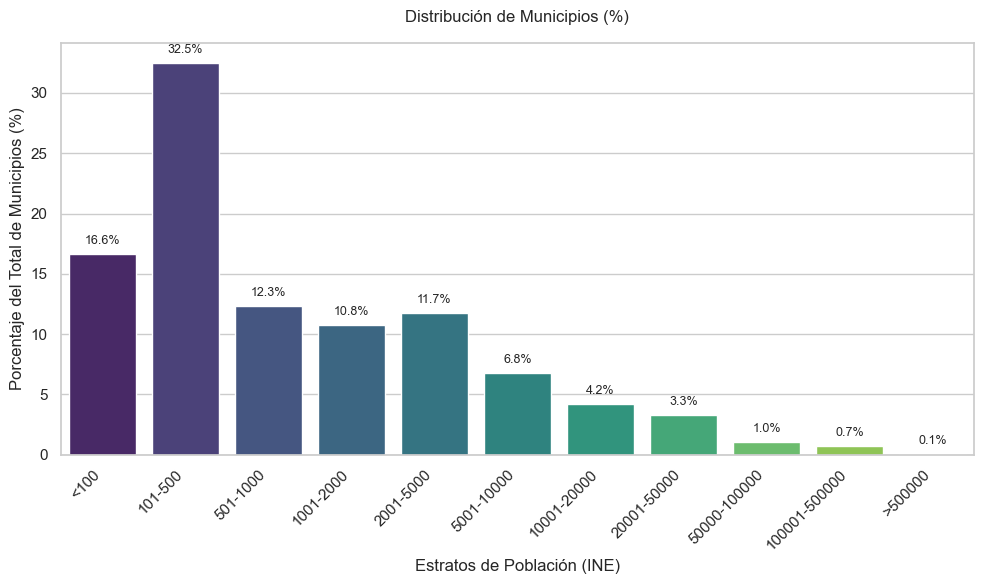

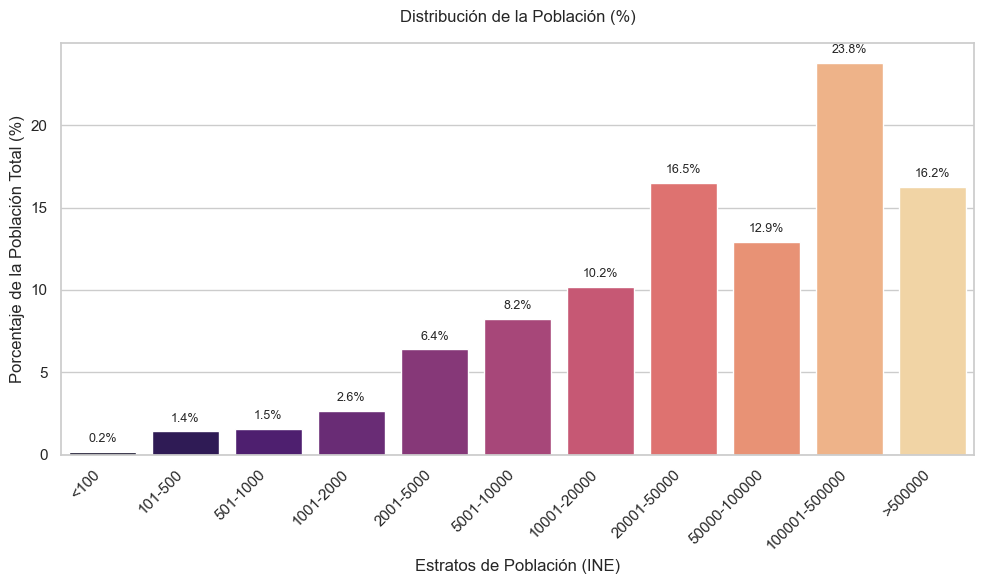

CONTROL DE CALIDAD GEOGRÁFICO
Densidad media nacional: 93.17 hab/km2
Municipios con superficie 0 o negativa: 0
Municipios con latitud fuera de rango: 0
Municipios con longitud fuera de rango: 0


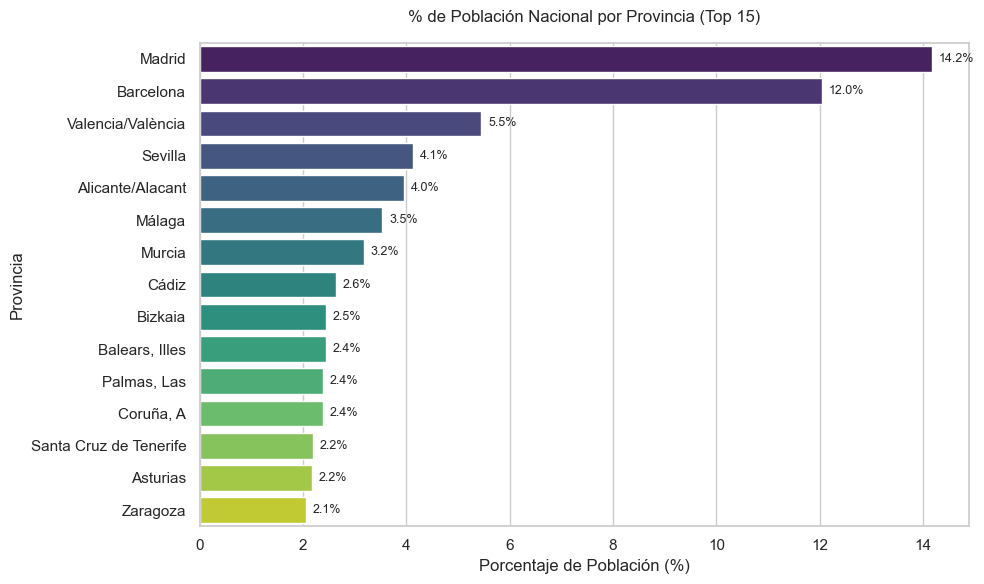

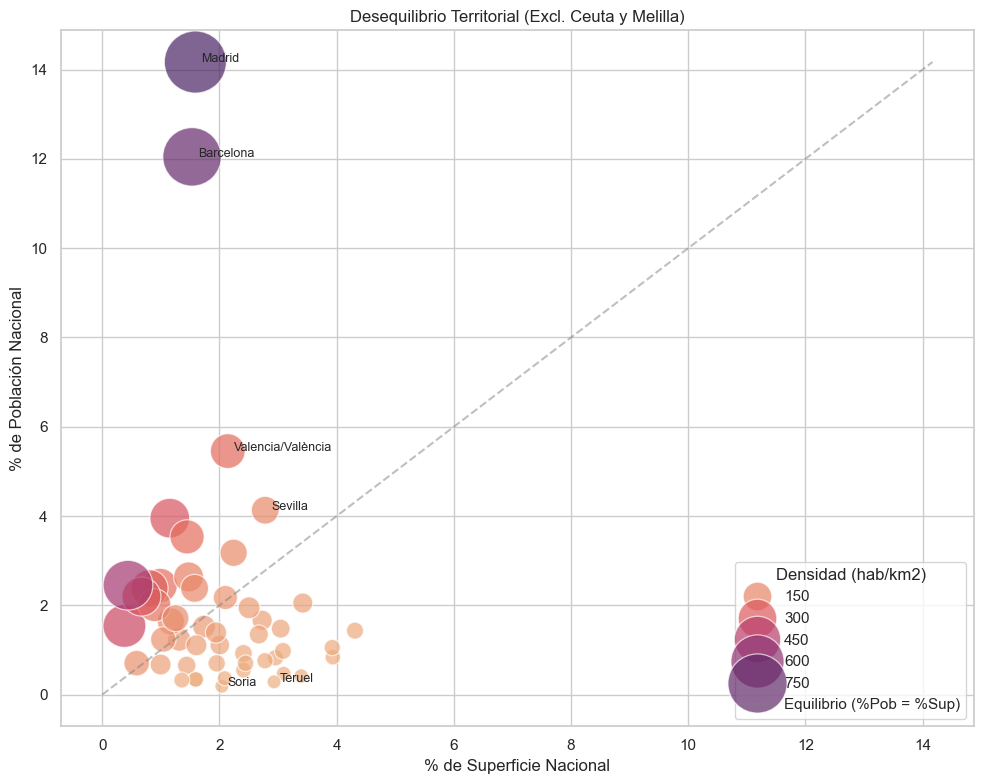

RESUMEN ESTADÍSTICO: CIUDADES AUTÓNOMAS (Excluidas del gráfico por densidad extrema)
- Ceuta: 84,777 hab | 19.87 km2 | Densidad: 4,266.58 hab/km2
- Melilla: 86,487 hab | 14.24 km2 | Densidad: 6,072.33 hab/km2


In [45]:
df_poblacion_superficie_2019 = eda_demografia_superficie(df_pob=df_2019_poblacion_csv, data_json=df_2019_poblacion_json, df_sup=df_2019_geografia)

Al hacer un primer análisis de los municipios y de cómo está distribuida la población española en 2019, podemos observar un fuerte contraste: los municipios con menos de 500 habitantes representan el 49,1% del total de municipios del Estado español, pero agrupan únicamente al 1,6% de la población. Por el contrario, los grandes municipios (aquellos de más de 100.000 habitantes) representan apenas el 0,8% de los ayuntamientos, pero concentran al 40% de la población. Destaca especialmente que la mayor acumulación demográfica se da en las ciudades de entre 100.000 y 500.000 habitantes, que por sí solas agrupan al 23,8% del total nacional.

Al observar el histograma de la distribución de la población, vemos que la mayor concentración de municipios se encuentra entre $10^2$ y $10^3$ en el eje X, lo que corresponde a poblaciones de entre 100 y 1.000 habitantes. En una escala lineal, esta variable presenta una fuerte asimetría con un marcado sesgo positivo (una larga cola hacia la derecha debido a unas pocas ciudades gigantes). Sin embargo, al aplicar la escala logarítmica, comprobamos que los datos adoptan una forma de campana, lo que indica que la población municipal en España sigue una distribución estadística log-normal.

Por último, si analizamos los extremos, vemos una enorme brecha demográfica. Los seis municipios más poblados del país superan el medio millón de habitantes, en un top 10 encabezado por Madrid (con 3.266.126 habitantes) y que cierra Bilbao en décima posición con más de 340.000 vecinos. En su contraparte, los 10 municipios menos poblados no logran superar los 8 habitantes. El municipio con menor población es Illán de Vacas, con únicamente 3 personas empadronadas, mientras que Villanueva de Gormaz marca el límite de este top 10 por abajo con 8 habitantes (un puesto que comparte con varios municipios más en esa misma situación).


Posteriormente, al trasladar el análisis al nivel provincial, se observa que Madrid y Barcelona se consolidan como los grandes polos demográficos, acumulando por sí solas el 26,2% de la población nacional. El diagrama de dispersión (scatterplot) aporta una perspectiva clave sobre este fenómeno mediante tres variables:

* Densidad Poblacional: Representada por el tamaño de las esferas, permite identificar visualmente la concentración de habitantes por kilómetro cuadrado, destacando de nuevo a las provincias de Madrid y Barcelona.

* Línea de Equilibrio (Bisectriz): Esta línea discontinua representa una distribución teórica ideal donde el peso demográfico de una provincia equivale a su peso territorial.

* Identificación de Desequilibrios: Las provincias situadas por debajo de la línea (como Soria o Teruel) muestran un claro desequilibrio territorial: poseen un alto porcentaje de superficie pero una baja carga demográfica. Al tener garantizado por ley un mínimo de dos escaños en el Congreso, estas provincias presentan una sobrerrepresentación electoral en relación con su censo.

En este análisis, se ha optado por excluir a las ciudades autónomas de Ceuta y Melilla del gráfico de dispersión. Al tratarse de entornos puramente urbanos con superficies muy reducidas, sus densidades extremas distorsionaban la escala visual del resto de provincias; no obstante, su peso ha sido documentado estadísticamente por separado. Por el contrario, las provincias situadas por encima de la línea (aquellas con mayor concentración de habitantes) sufren una subrepresentación, ya que, aunque eligen un mayor número de diputados, reciben menos de los que les corresponderían en un sistema de reparto estrictamente proporcional sin mínimos territoriales.


**Conclusiones: Impacto en el Sistema Electoral y la Ley D'Hondt**

Esta polarización demográfica es la raíz de la desproporcionalidad electoral en España. Al utilizar la provincia como circunscripción y asignar un mínimo de dos escaños fijos a cada una, el sistema transfiere peso político desde las urbes hacia el territorio.

La gran masa de municipios de menos de 500 habitantes (el 49,1% del total nacional) da lugar a provincias extensas pero poco pobladas, ubicadas bajo la línea de equilibrio, que actúan como circunscripciones pequeñas. En estas zonas, la fórmula D'Hondt agudiza el sesgo: al repartirse pocos escaños (2 o 3), el "precio" del diputado en votos es mucho más bajo, pero los partidos minoritarios quedan excluidos al no alcanzar los altos umbrales necesarios.

En consecuencia, el diseño actual otorga un peso electoral desproporcionado a las áreas rurales frente a los grandes núcleos urbanos (que concentran al 40% de la población en solo el 0,8% de los municipios), rompiendo la máxima de "un persona, un voto" en favor de la representación territorial.

*NOTA: las franjas para separar la población han sido basadas en como el INE separa las provincias según el padron: "https://www.ine.es/jaxiPx/Tabla.htm?path=/t20/e245/p04/a2002/l0/&file=000an001.px&L=0"*

Antes de abordar el mercado laboral, analizaremos la edad media de los municipios urbanos y las provincias. Debido a que el INE solo publica datos con este nivel de granularidad, no es posible realizar el análisis a escala municipal.


  EDA EDAD MEDIA - 2019

[1/3] Provincias - Ambos sexos
  Edad media Total Nacional (2019): 43.37 anos
  Rango provincial: 35.48 - 50.80 anos


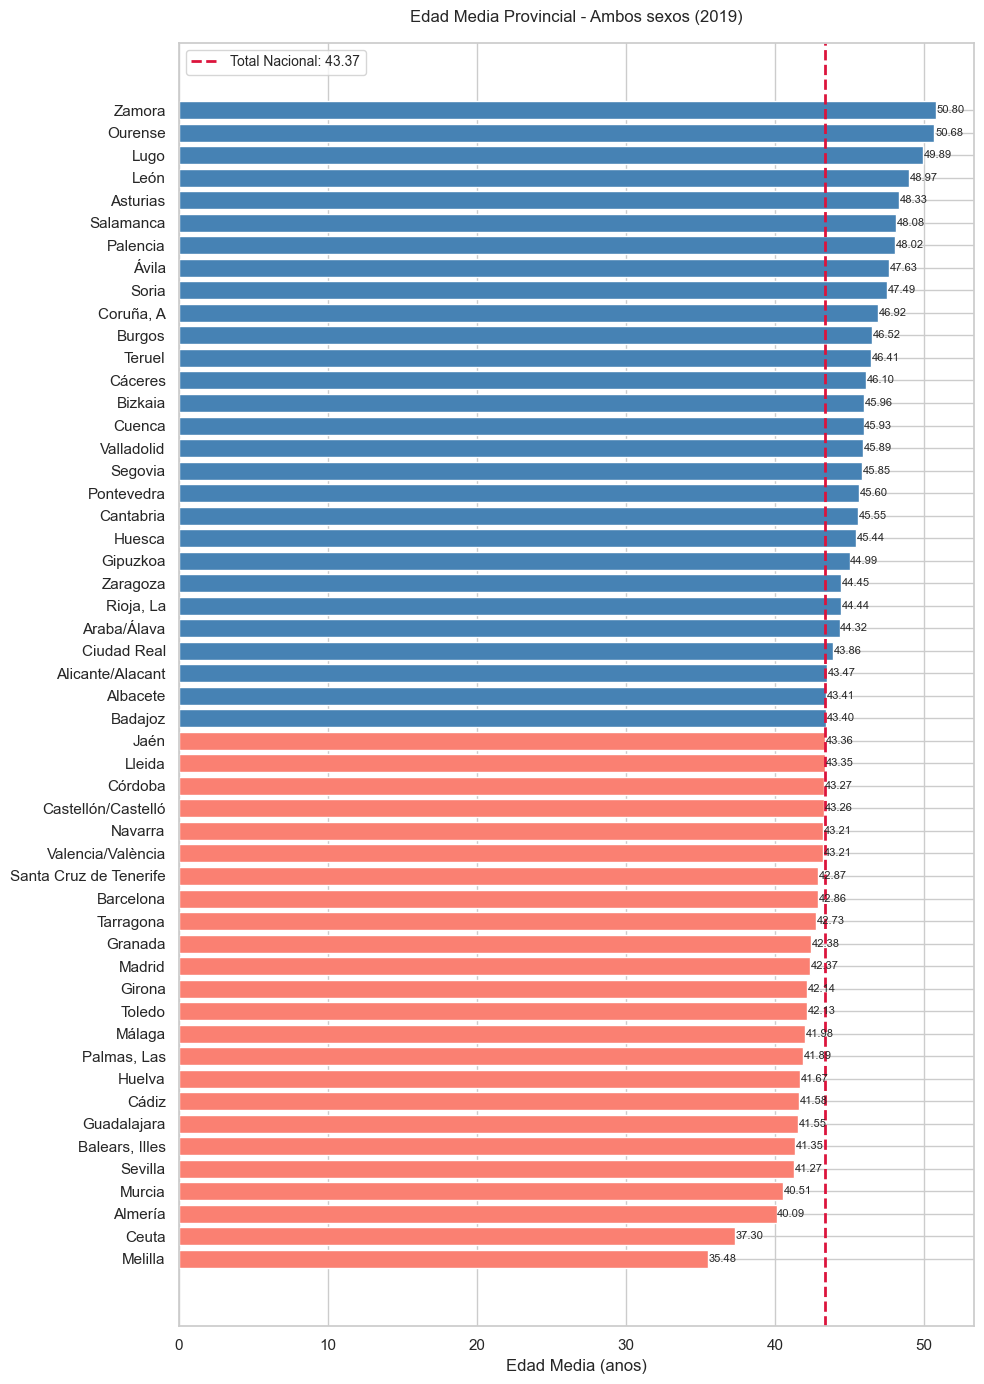


[2/3] Provincias - Por genero
  Hombres - Total Nacional (2019): 42.06 anos


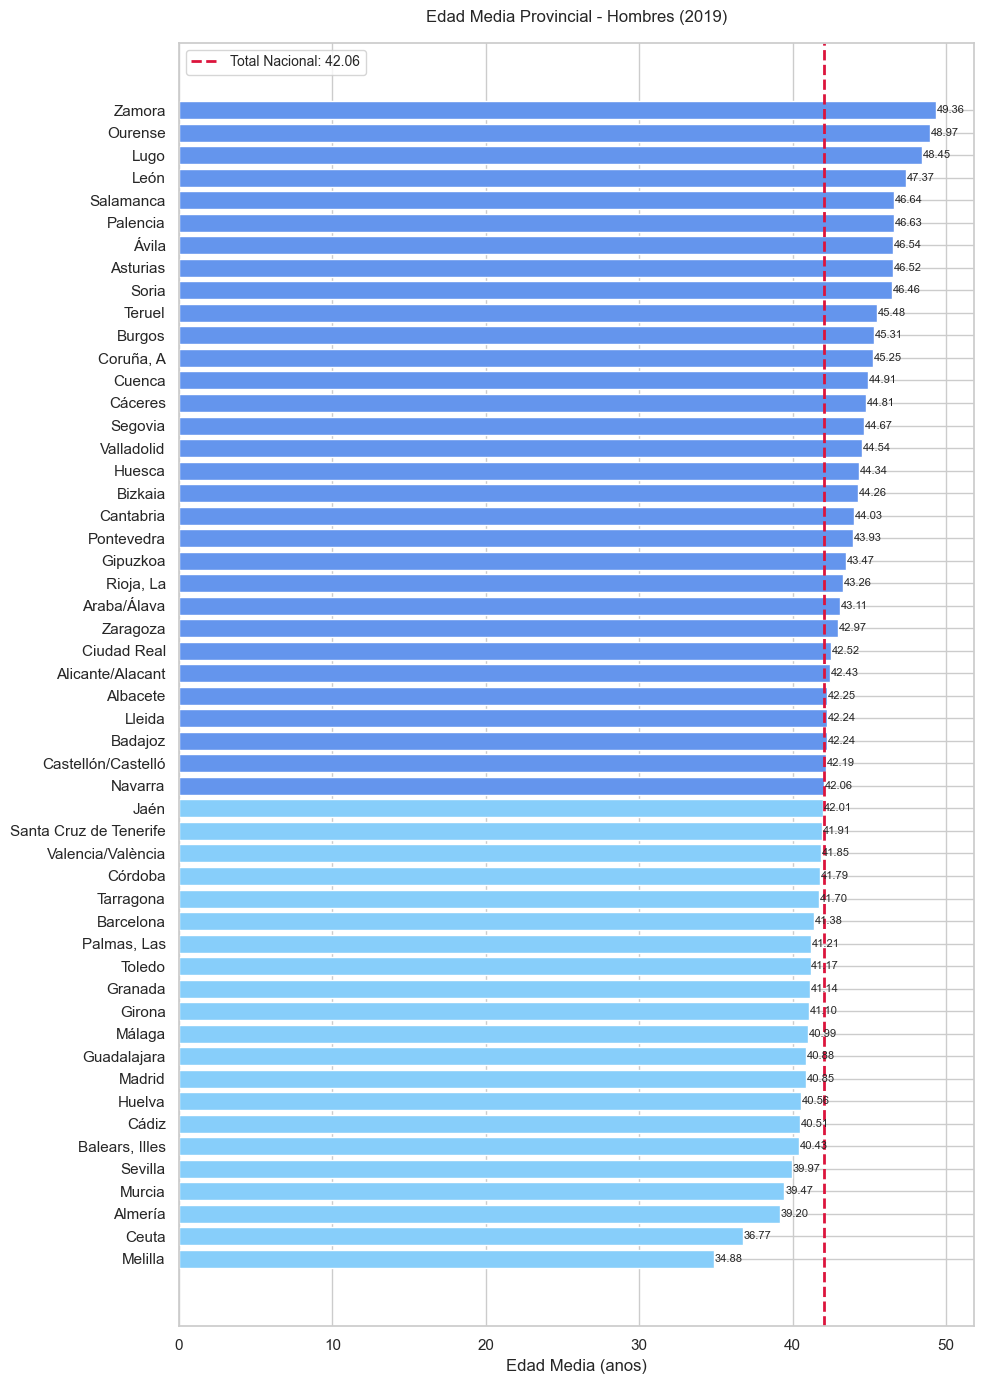

  Mujeres - Total Nacional (2019): 44.63 anos


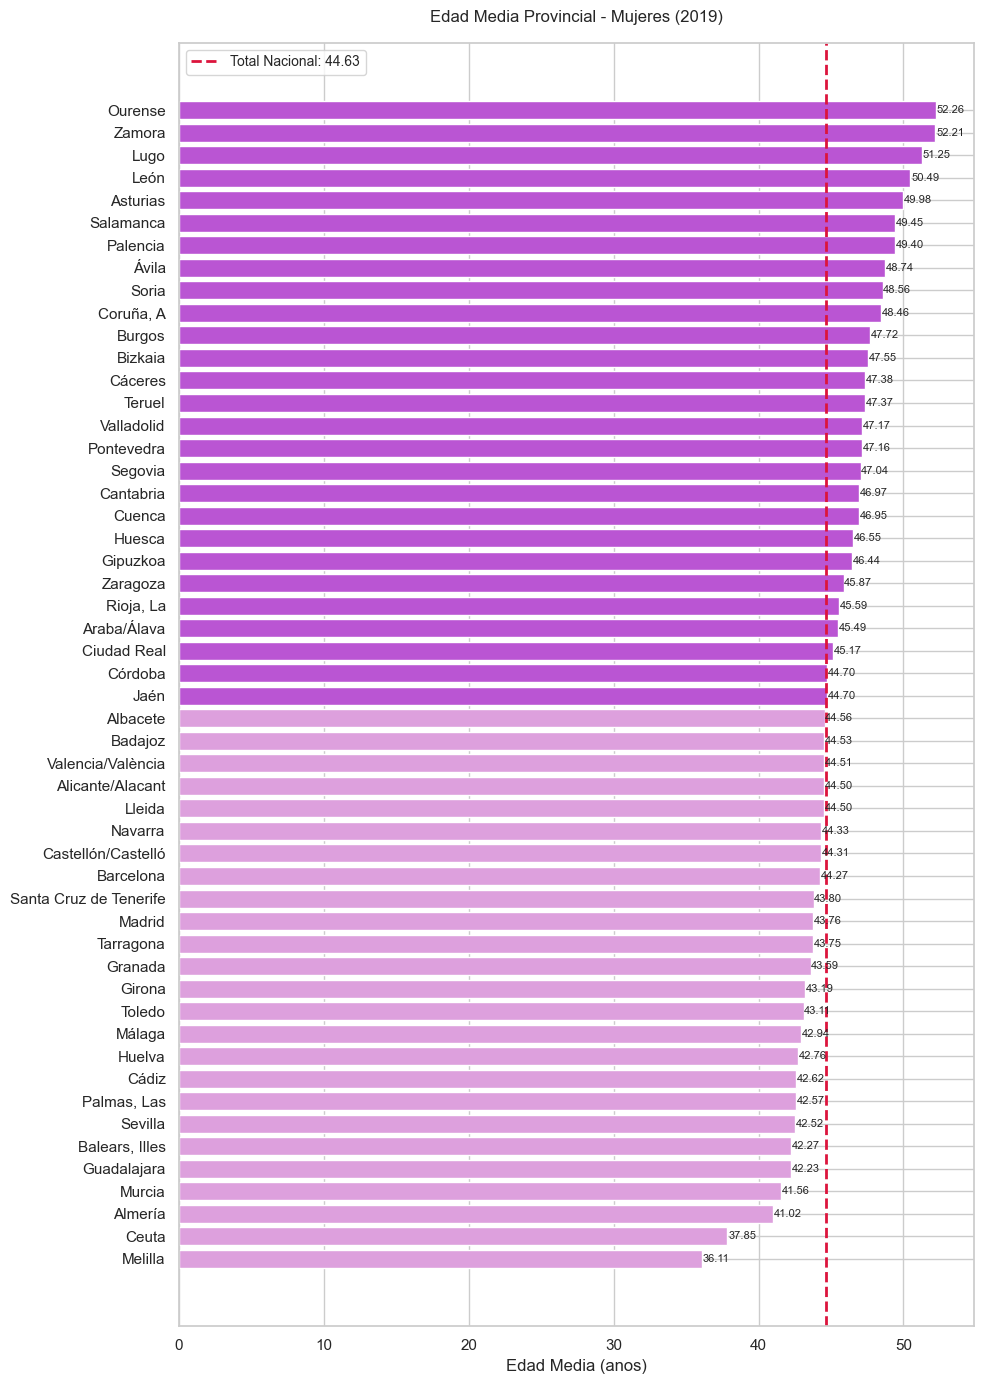


[3/3] Municipios
  Ambos sexos — municipios con dato: 150 | media: 42.50 | rango: 35.61 - 48.99 anos


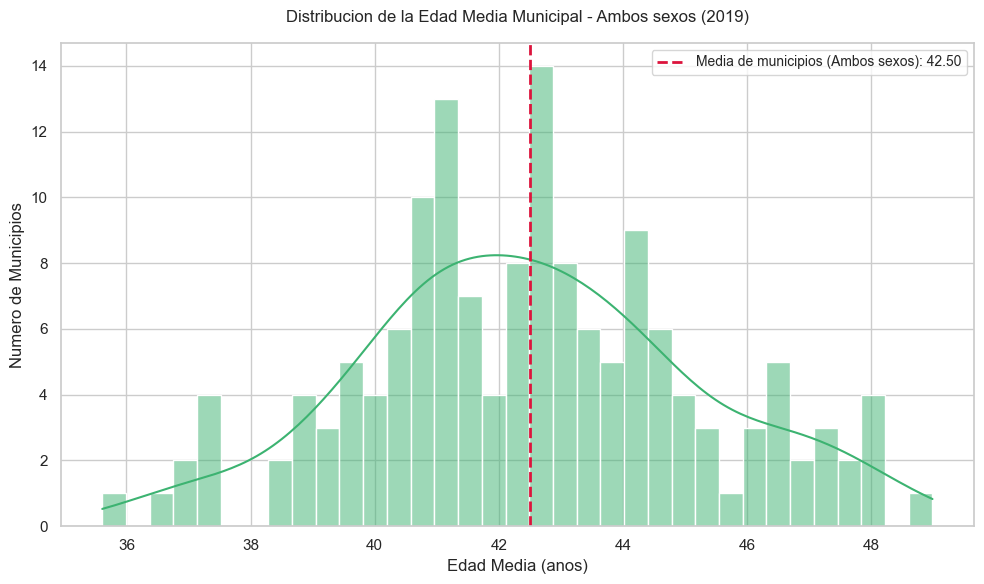

  Hombres — municipios con dato: 150 | media: 41.16 | rango: 35.04 - 46.48 anos


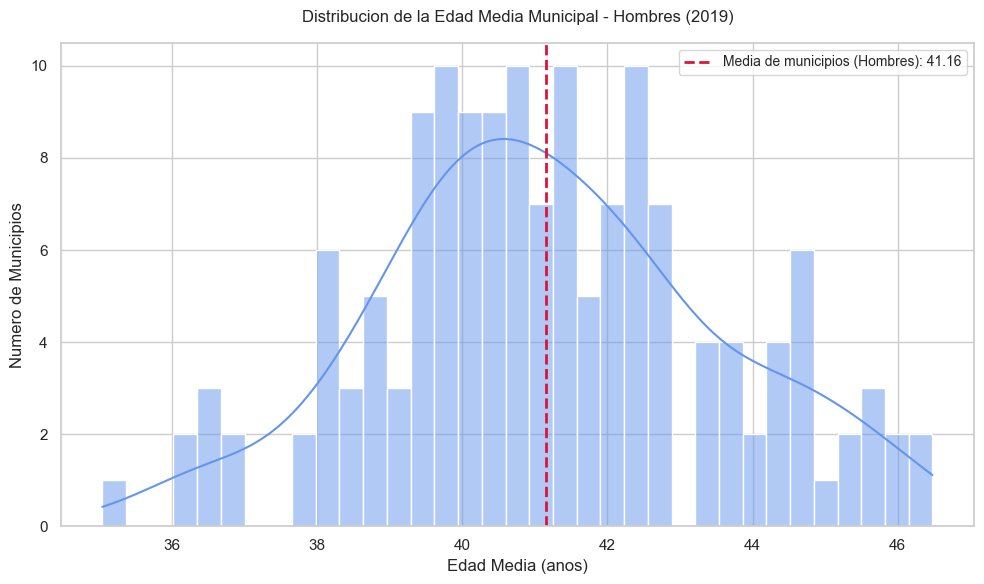

  Mujeres — municipios con dato: 150 | media: 43.75 | rango: 36.19 - 51.21 anos


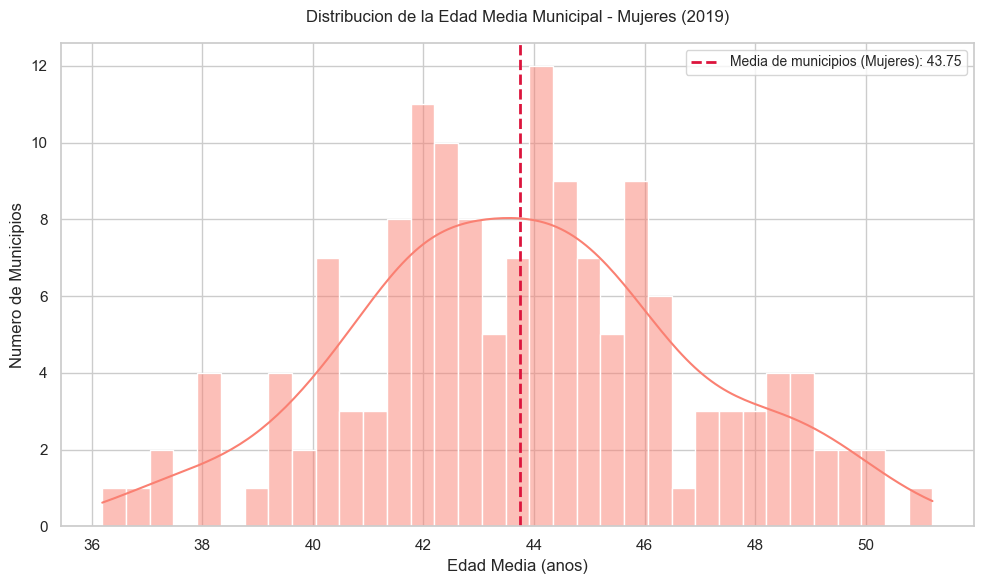

In [46]:
eda_edad_media(
      df_provincias=df_2019_edad_media_provincias,
      df_municipios=df_2019_edad_media_municipios,
      anio=2019
  )

### 1.2. Mercado Laboral (La salud del empleo)

* Sectores: ¿En cuántos municipios domina el sector servicios (p_ser) frente al agrario (p_agr)?
* Brecha: Compara total_paro de hombres vs mujeres.

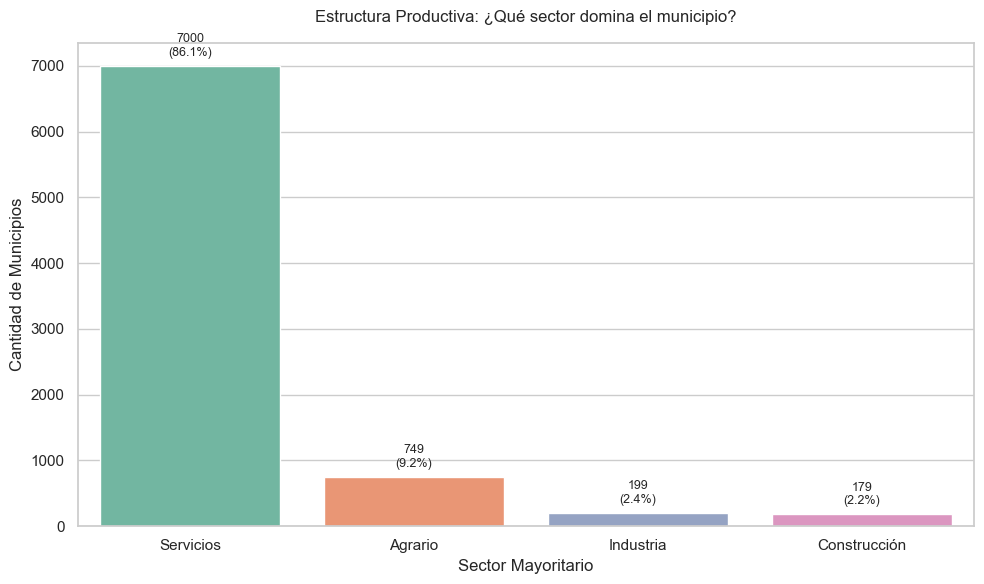

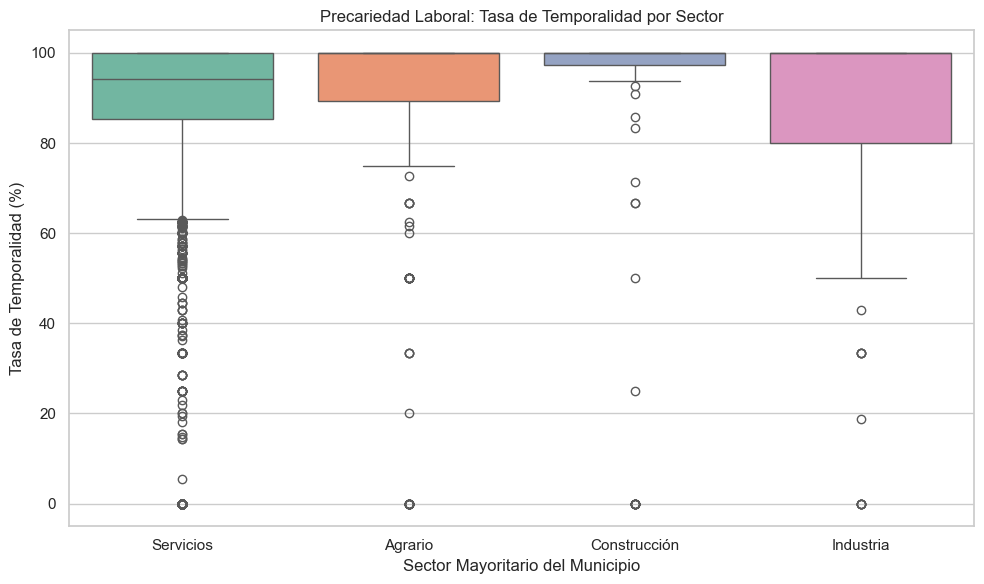

RADIOGRAFÍA DEL MERCADO LABORAL
Temporalidad real nacional (ponderada): 90.3% de los contratos
Peso medio del paro Femenino: 54.2% del total de parados
Peso medio del paro Juvenil (<25): 7.6% del total de parados
Peso medio del paro Senior (>45): 56.3% del total de parados

MÉTRICAS ESTRUCTURALES Y BRECHAS


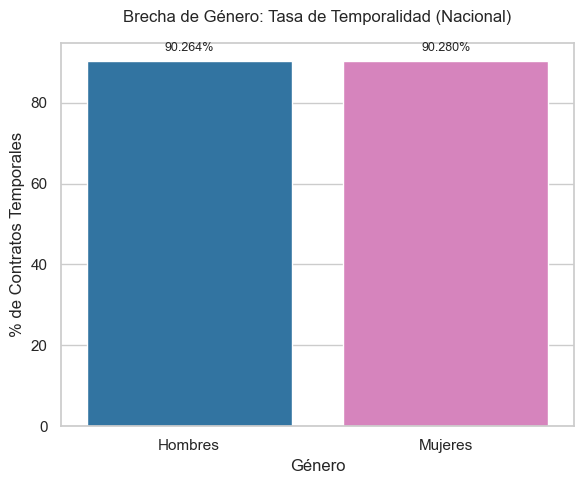

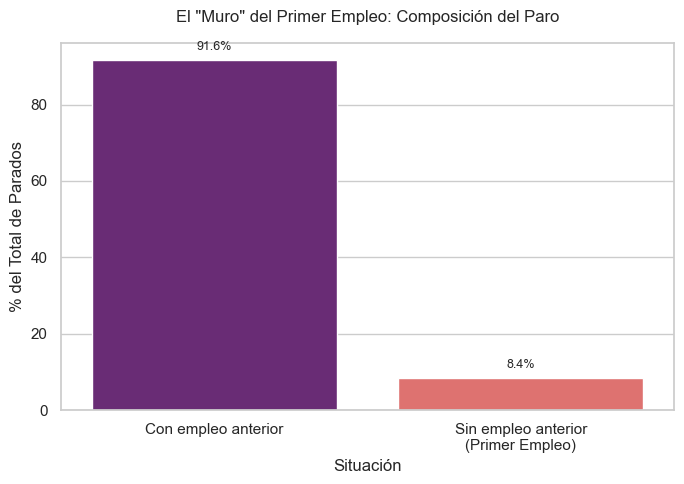

PRIMER EMPLEO: 269,615 parados (8.4% del total nacional) nunca han trabajado.


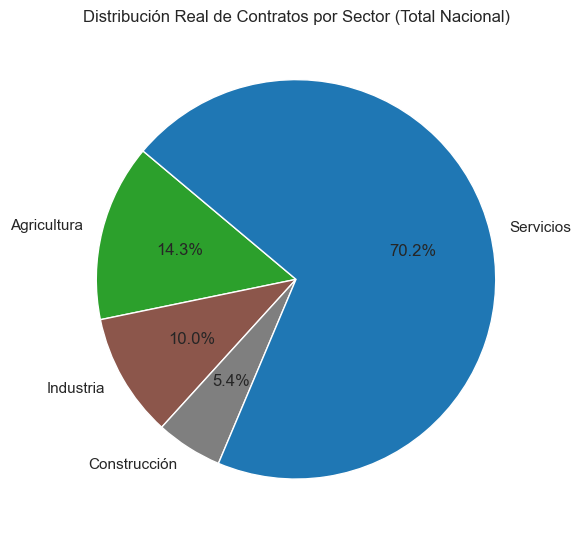

ESTRUCTURA DE CONTRATACIÓN NACIONAL:
Agricultura: 253,072 contratos
Industria: 176,832 contratos
Construcción: 95,032 contratos
Servicios: 1,238,712 contratos


In [47]:
df_mercado_laboral = eda_mercado_laboral(df_paro_contratos = df_2019_paro_contratos)

Los datos analizados corresponden a noviembre de 2019, mes en el que se celebraron las elecciones generales. En cuanto a la estructura de contratación, el sector servicios actúa como el motor principal, representando el 70,2% de los contratos a nivel nacional y consolidándose como el sector mayoritario en 7.000 municipios. Le sigue el sector agrícola, con un 14,3% de los contratos y siendo la principal fuente de empleo en 749 municipios. En tercer lugar, el sector industrial representa el 10% de las firmas, liderando la contratación en 199 localidades. Finalmente, con una presencia territorial similar a la industria pero menor volumen, la construcción agrupa el 5,4% de los contratos, siendo el sector dominante en apenas 179 municipios.

La tasa media de temporalidad nacional en este mes se sitúa en un altísimo 90,3%, al igual que la brecha por genero. Esta cifra, aunque elevada, responde fielmente al contexto socioeconómico del momento: noviembre marca el inicio de las contrataciones estacionales masivas para el Black Friday y la campaña de Navidad. Además, el mercado operaba bajo el marco legal previo a la reforma laboral de 2021, que posteriormente limitaría la contratación eventual, por lo que estas cifras reflejan la precariedad estructural de la época.

Al analizar la demografía del desempleo, se observan claras brechas. El peso medio del paro femenino asciende al 54,2% del total de desempleados. Sin embargo, el colectivo más afectado de forma estructural es el de los trabajadores sénior (mayores de 45 años), quienes suponen el 56,3% de los parados totales. En contraparte, los jóvenes menores de 25 años representan un peso medio del 7,6%. Adicionalmente, los datos revelan una fuerte barrera de entrada al mercado: 269.615 personas, el 8,4% de los parados del país, son demandantes de su primer empleo y nunca han cotizado previamente.

Por último, el análisis de dispersión (boxplot) de la temporalidad por sectores revela dinámicas muy distintas. La construcción presenta una menor dispersión en sus tasas de temporalidad, indicando un comportamiento más homogéneo en todo el país. La industria, en cambio, muestra una mayor variabilidad. Destaca especialmente el sector servicios, que acumula la mayor cantidad de valores atípicos (outliers), lo que evidencia realidades laborales extremadamente polarizadas dependiendo de la vocación turística o comercial de cada municipio.

### 1.3. Renta e Igualdad (El motor económico)
Acción: Filtrar solo las columnas de 2019.

Análisis:
* Indicador Clave: Usa Renta neta media por persona 2019. Mira su media y desviación estándar.
* Desigualdad: Analiza el Índice de Gini 2019. Un Gini alto (>35) indica mucha desigualdad. Mira si esos municipios coinciden con las rentas más altas o bajas.
* Dependencia: Calcula qué porcentaje de los ingresos viene de salario 2019 vs pensiones 2019.

Empezamos por el indice de GINI y el P80P20, tenemos que tener en cuenta que el ine no publica datos de los municipios de menos de 500 habitantes por secretos estadisticos, ademas Pais vasco y Navarra tienen regimenes forales propios por lo que puede faltar información. 


AUDITORÍA DE DATOS FALTANTES DESIGUALDAD (2019)
Total de municipios en el dataset: 8139
Nulos en Gini (Índice de Gini 2019):      1693 municipios (20.8% del total)
Nulos en P80/P20 (Distribución de la renta P80/P20 2019):   1693 municipios (20.8% del total)


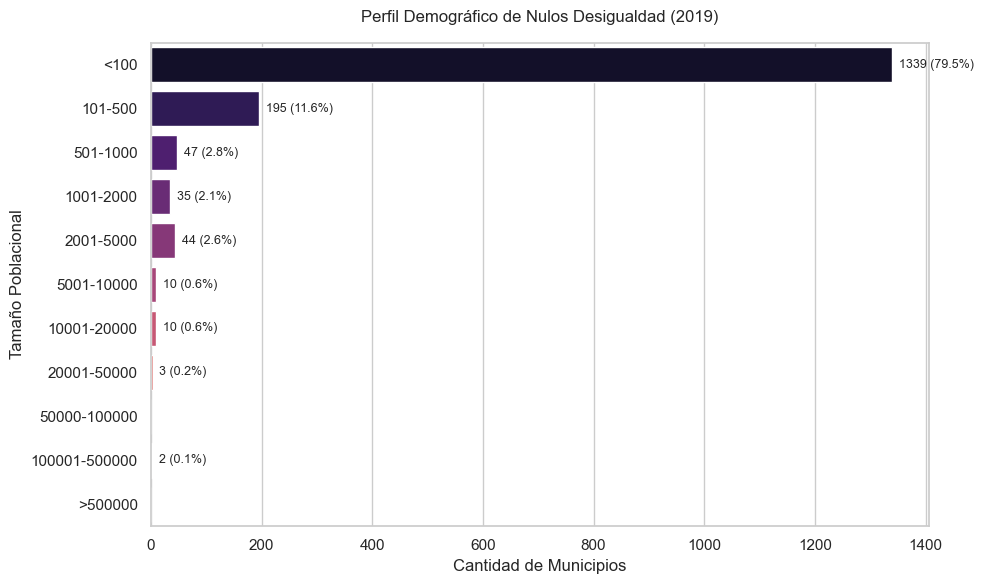


IMPACTO POR PROVINCIA Desigualdad (2019)
Top 10 provincias con más nulos Desigualdad:
 - Navarra             :  272 municipios (16.1%)
 - Guadalajara         :  182 municipios (10.8%)
 - Burgos              :  171 municipios (10.1%)
 - Soria               :  118 municipios (7.0%)
 - Ávila               :  100 municipios (5.9%)
 - Teruel              :   96 municipios (5.7%)
 - Zaragoza            :   88 municipios (5.2%)
 - Salamanca           :   87 municipios (5.2%)
 - Segovia             :   79 municipios (4.7%)
 - Cuenca              :   78 municipios (4.6%)

ANÁLISIS DE EXCEPCIONES AL SECRETO ESTADÍSTICO (<= 100 hab. en 2019)
Se han encontrado 13 municipios con datos a pesar de su pequeño tamaño (<= 100 hab).

RESUMEN DE EXCEPCIONES POR PROVINCIA:
 - Guadalajara: 2 municipio(s)
 - Cáceres: 1 municipio(s)
 - Castellón/Castelló: 1 municipio(s)
 - Cuenca: 1 municipio(s)
 - Huesca: 1 municipio(s)
 - Lleida: 1 municipio(s)
 - Salamanca: 1 municipio(s)
 - Soria: 1 municipio(s)
 - Tarra

In [48]:
gestion_nulos_desigualdad(df_gini = df_2019_GINI_P80P20, df_pob= df_poblacion_superficie_2019, anyo="2019")

En primer lugar, observamos que hay ocho municipios que ya no existen, lo cual se debe a que fueron fusionados con otros en el pasado. Por otro lado, Navarra presenta valores nulos en todos sus municipios; este es un punto clave de análisis dada su condición de comunidad foral uniprovincial. Asimismo, la norma de omitir datos en municipios con una población igual o inferior a 100 habitantes se incumple en 13 casos, una muestra demasiado pequeña para extrapolar los resultados al resto de las localidades.

Podemos observar que, en cuanto a los indicadores económicos, la Comunidad Foral de Navarra no publica sus datos junto al resto de comunidades autónomas en el INE. Por ello, obtenemos esta información de Nastat (https://nastat.navarra.es/es/tablas_powerbi/-/tag/estadistica-renta). Aunque no disponemos exactamente de los mismos indicadores que para el resto de las comunidades, sí contamos con una gran parte de ellos, lo que nos permite enriquecer nuestro conjunto de datos sobre esta región. Aplicamos nuevamente las funciones de ETL, las cuales nos devuelven un dataframe con todos los indicadores económicos del conjunto del Estado español. 

In [49]:
df_renta_completa = generar_renta_con_navarra(año=2019)

Iniciando proceso de integración para el año 2019...
Éxito: Archivo 'renta_con_navarra_2019.csv' generado correctamente.


Volvemos a mirar la cantidad de NA, pero con los datos de Navarra.


AUDITORÍA DE DATOS FALTANTES DESIGUALDAD (2019)
Total de municipios en el dataset: 8139
Nulos en Gini (Índice de Gini):      1421 municipios (17.5% del total)
Nulos en P80/P20 (Distribución de la renta P80/P20):   1421 municipios (17.5% del total)


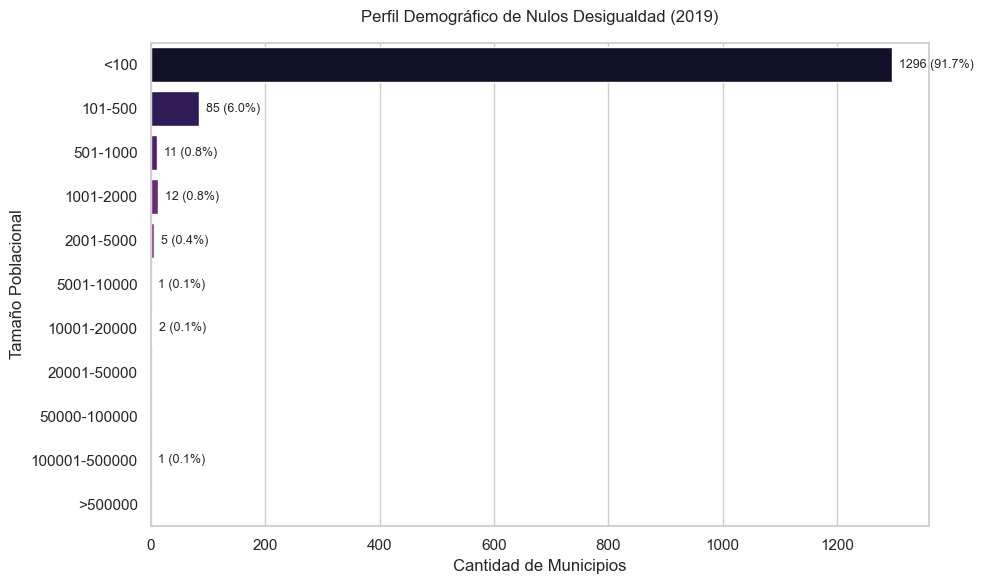


IMPACTO POR PROVINCIA Desigualdad (2019)
Top 10 provincias con más nulos Desigualdad:
 - Guadalajara         :  182 municipios (12.9%)
 - Burgos              :  171 municipios (12.1%)
 - Soria               :  118 municipios (8.4%)
 - Ávila               :  100 municipios (7.1%)
 - Teruel              :   96 municipios (6.8%)
 - Zaragoza            :   88 municipios (6.2%)
 - Salamanca           :   87 municipios (6.2%)
 - Segovia             :   79 municipios (5.6%)
 - Cuenca              :   78 municipios (5.5%)
 - Palencia            :   76 municipios (5.4%)

ANÁLISIS DE EXCEPCIONES AL SECRETO ESTADÍSTICO (<= 100 hab. en 2019)
Se han encontrado 56 municipios con datos a pesar de su pequeño tamaño (<= 100 hab).

RESUMEN DE EXCEPCIONES POR PROVINCIA:
 - Navarra: 43 municipio(s)
 - Guadalajara: 2 municipio(s)
 - Cáceres: 1 municipio(s)
 - Cuenca: 1 municipio(s)
 - Castellón/Castelló: 1 municipio(s)
 - Huesca: 1 municipio(s)
 - Lleida: 1 municipio(s)
 - Salamanca: 1 municipio(s)
 - Sor

In [50]:
gestion_nulos_desigualdad( df_gini = df_renta_completa.reset_index(), df_pob = df_poblacion_superficie_2019, anyo = "2019")

 INICIANDO ANÁLISIS DE DESIGUALDAD Y RENTA (2019)
Info: 1421 de 8139 municipios NO tienen datos de renta en 2019.

TOP 10 MUNICIPIOS MÁS DESIGUALES (2019)
 1. 25363.0                   | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 2. 25497.0                   | Gini: 45.2 | Los ricos ganan 3.6x más que los pobres
 3. 12835.0                   | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 4. 31650.0                   | Gini: 45.2 | Los ricos ganan 2.7x más que los pobres
 5. 21552.0                   | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 6. 21134.0                   | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 7. 19703.0                   | Gini: 44.9 | Los ricos ganan 4.2x más que los pobres
 8. 16090.0                   | Gini: 44.9 | Los ricos ganan 2.9x más que los pobres
 9. 18400.0                   | Gini: 44.6 | Los ricos ganan 3.0x más que los pobres
10. 17847.0                   | Gini: 44.2 | Los ricos ganan 4.6x más que los po

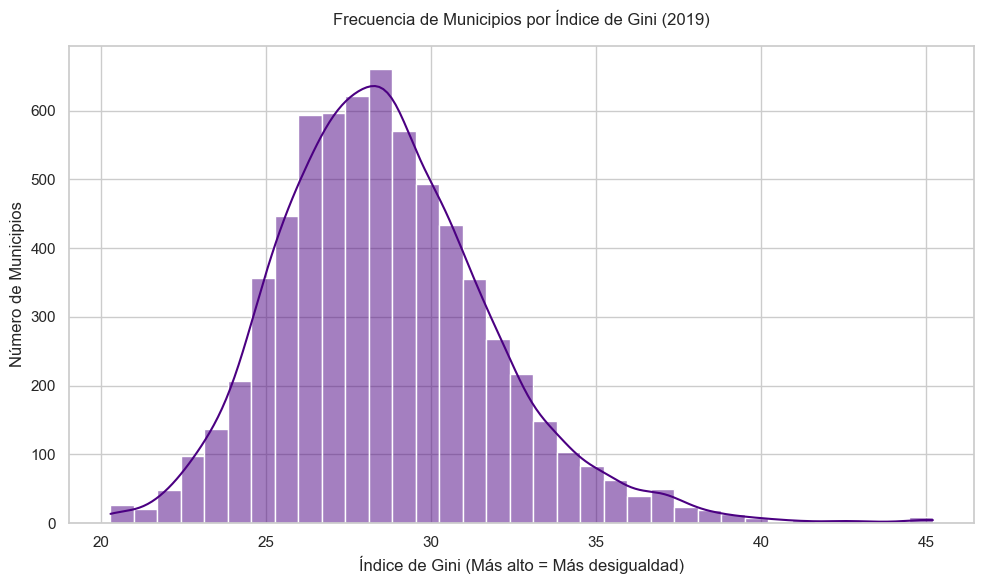

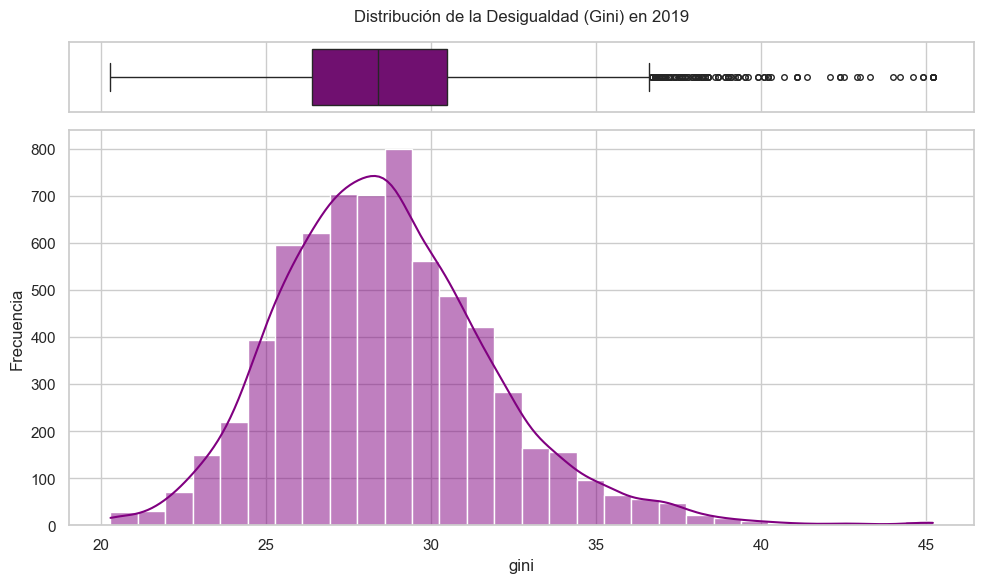

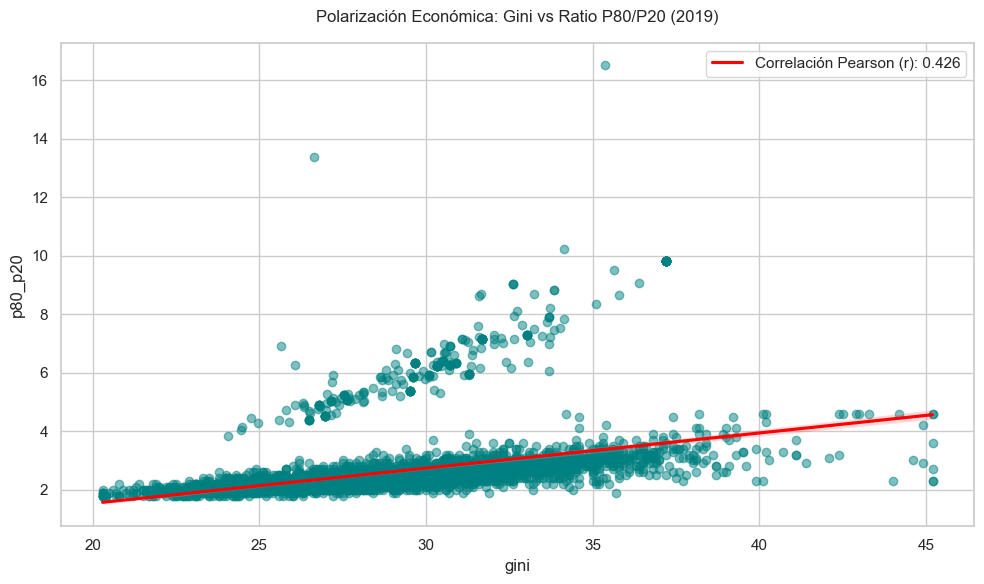

In [51]:
df_desigualdad_2019 = eda_gini_p80p20(df_gini_completo=df_renta_completa.reset_index(), anyo="2019")

Podemos observar que la gráfica de relación entre el índice de Gini y el P80/P20 presenta una dispersión considerable en los datos. Esto se debe a que, en el caso de Navarra, disponemos del indicador S80/S20 en lugar del P80/P20; al existir esta discrepancia, no lo consideramos un resultado válido para la comparativa. Por este motivo, nos centraremos únicamente en los histogramas de Gini.

A continuación, repetiremos el análisis excluyendo el dato de Navarra para observar la relación real. Sabemos que la correlación entre el índice de Gini y el P80/P20 es elevada, por lo que descartaremos esta última métrica al no disponer de la serie completa de datos. No obstante, esta decisión se confirmará más adelante mediante un mapa de correlaciones.

 INICIANDO ANÁLISIS DE DESIGUALDAD Y RENTA (2019)
Info: 1693 de 8139 municipios NO tienen datos de renta en 2019.

TOP 10 MUNICIPIOS MÁS DESIGUALES (2019)
 1. Benasau                   | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 2. Mediana de Voltoya        | Gini: 45.2 | Los ricos ganan 3.6x más que los pobres
 3. Carataunas                | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 4. Alocén                    | Gini: 45.2 | Los ricos ganan 2.7x más que los pobres
 5. Guadramiro                | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 6. Villarluengo              | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 7. Campillo de Ranas         | Gini: 44.9 | Los ricos ganan 4.2x más que los pobres
 8. Villardondiego            | Gini: 44.9 | Los ricos ganan 2.9x más que los pobres
 9. Pobla de Benifassà, la    | Gini: 44.6 | Los ricos ganan 3.0x más que los pobres
10. Sant Mori                 | Gini: 44.0 | Los ricos ganan 2.3x más que los po

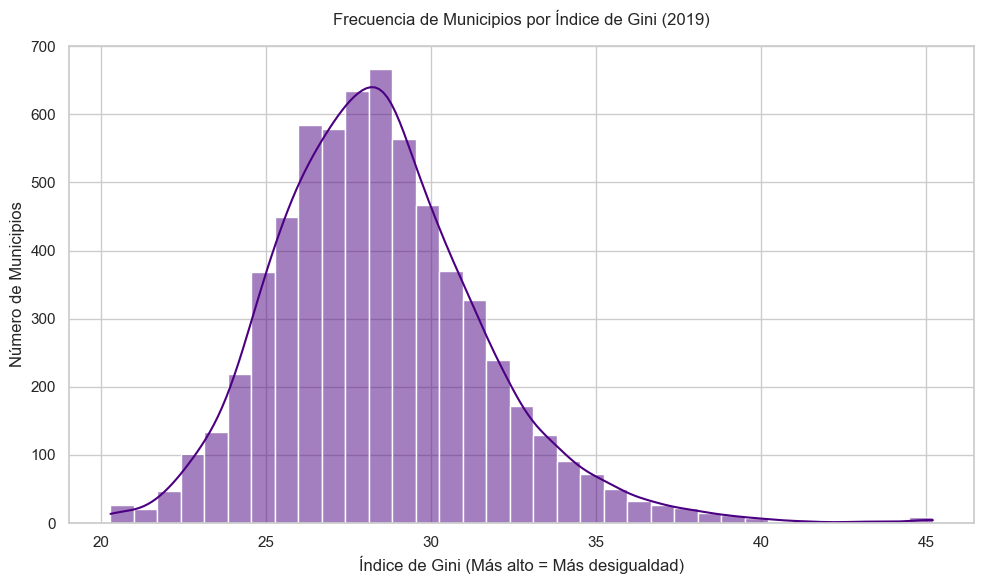

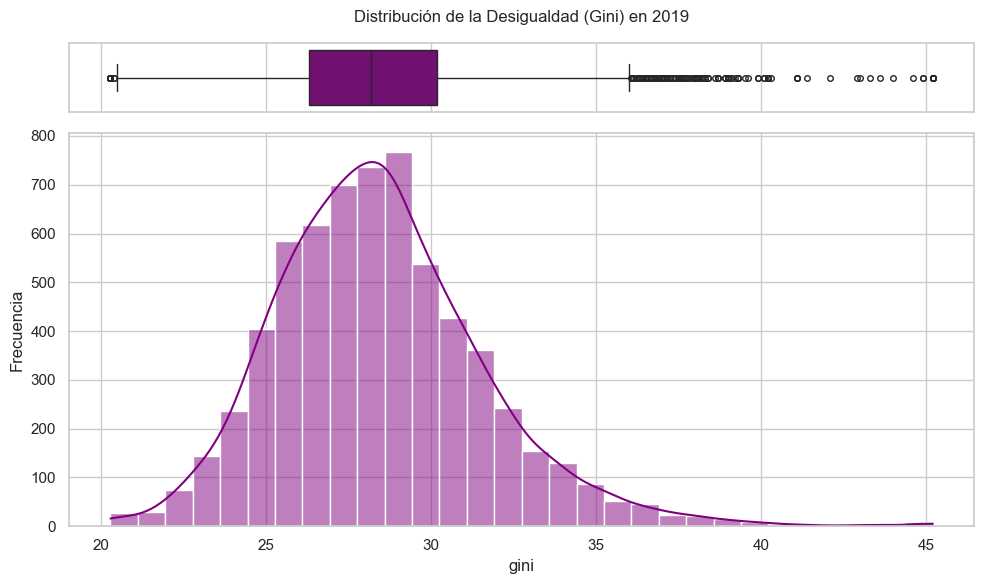

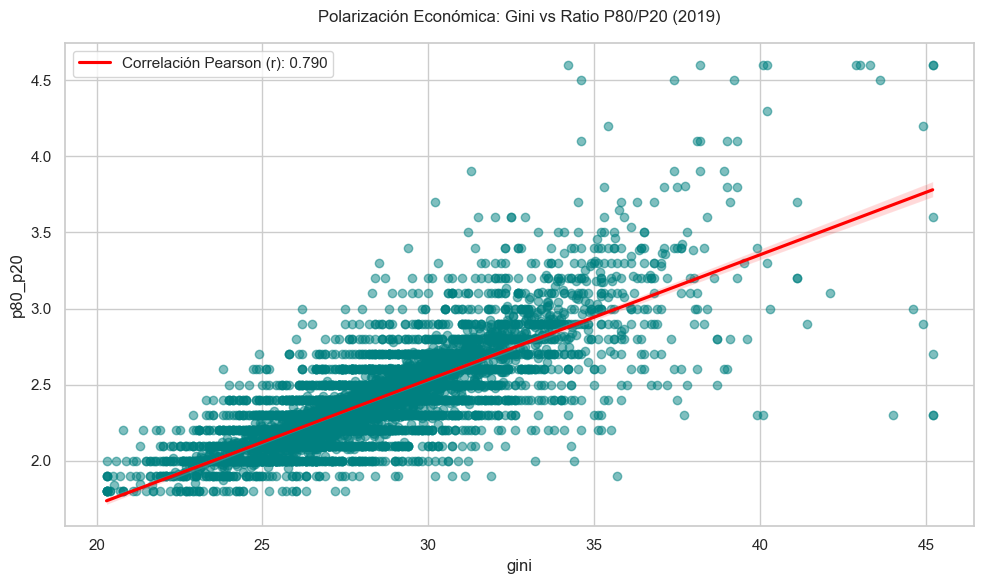

In [52]:
df_desigualdad_2019 = eda_gini_p80p20(df_gini_completo=df_2019_GINI_P80P20, anyo="2019")

Tras el procesamiento y visualización de los indicadores de renta relativos a 2019, se observa una radiografía de la desigualdad municipal que resulta determinante para entender el clima previo a los comicios. Para interpretar estos datos, es necesario precisar que el Índice de Gini es una medida de desigualdad que oscila entre 0 (igualdad total) y 100 (desigualdad máxima, donde una sola persona concentra toda la renta). En el contexto español, un Gini inferior a 25 se considera una cota de igualdad muy alta, el rango entre 28 y 32 representa el estándar medio nacional, y valores superiores a 35 o 40 indican una fractura social severa. Complementariamente, el Ratio P80/P20 cuantifica la polarización de los extremos, indicando cuántas veces superan los ingresos del 20% más rico de la población a los del 20% más pobre.

El análisis de distribución mediante el histograma confirma que la mayoría de los municipios españoles presentan una morfología de campana con una fuerte concentración en el intervalo de 26 a 31 puntos de Gini, lo que define la normalidad estadística de la desigualdad moderada en el país. Sin embargo, los resultados arrojan una sombra estadística significativa: 1.693 municipios (el 20,8% del total nacional) no presentan datos de renta. Este vacío no es aleatorio, sino que coincide con municipios de pequeño tamaño —la "España vaciada"— protegidos por el secreto estadístico del INE para preservar la privacidad en entornos de baja población. Esta ausencia de datos en el bloque de renta refuerza la tesis del desequilibrio territorial analizado en capítulos anteriores, donde la falta de visibilidad económica suele correlacionar con una marginalidad política que el sistema electoral intenta compensar.

En la gráfica se observa la relación entre ambas métricas, se ha obtenido un coeficiente de correlación de Pearson de $r = 0,790$. Este valor indica una correlación positiva fuerte, confirmando que la desigualdad en España se manifiesta de forma predominante como una polarización de los extremos. Matemáticamente, este resultado valida que en los municipios donde el Índice de Gini se eleva, la brecha social se ensancha de forma drástica y predecible: el enriquecimiento del bloque superior de renta ocurre de forma simultánea al estancamiento del bloque inferior. En localidades donde el Gini supera los 40 puntos, esta "fractura" social genera un entorno económico que suele traducirse en un ratio $P80/P20$ elevado (llegando a 4,6x en casos como Villarluengo).

Desde la perspectiva de este TFM, esta consistencia estadística ($r = 0,790$) sugiere que será importante observar si los los municipios situados en la parte alta de esta correlación, tienen comportamientos de voto dispares aquellos que ocupan la parte baja de la gráfica.ç

## distrivución de fuente de ingresos


==================== INICIANDO ANÁLISIS DE FUENTES DE INGRESOS (2019) ====================

AUDITORÍA DE DATOS FALTANTES FUENTES INGRESOS (2019)


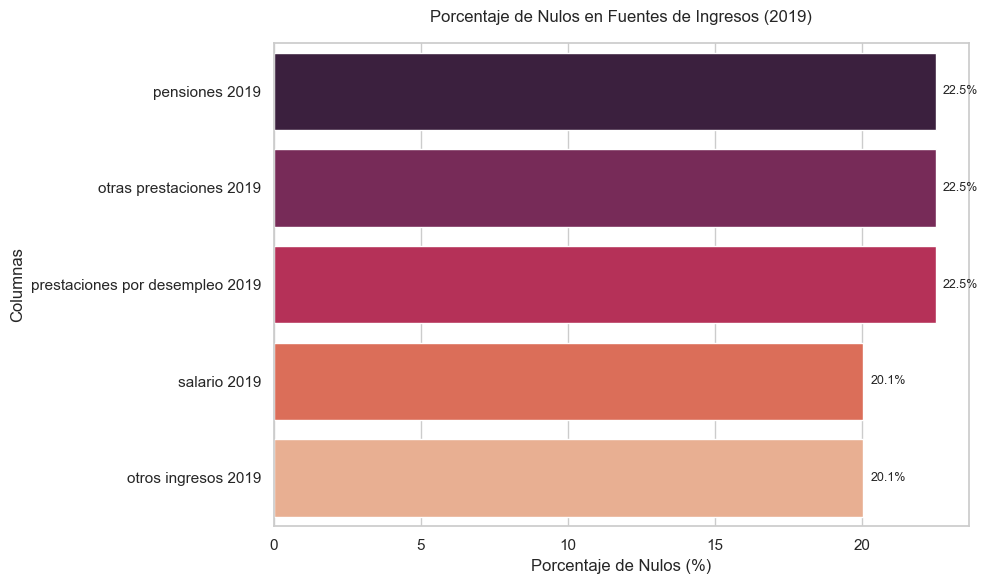

Nota: No se puede mostrar el perfil por tamaño de municipio para Fuentes Ingresos porque la columna no existe en los datos proporcionados.

IMPACTO POR PROVINCIA Fuentes Ingresos (2019)
Top 10 provincias con más nulos Fuentes Ingresos:
 - Navarra             :  211 municipios (13.0%)
 - Guadalajara         :  182 municipios (11.2%)
 - Burgos              :  171 municipios (10.5%)
 - Soria               :  118 municipios (7.3%)
 - Ávila               :  100 municipios (6.2%)
 - Teruel              :   96 municipios (5.9%)
 - Zaragoza            :   88 municipios (5.4%)
 - Salamanca           :   87 municipios (5.4%)
 - Segovia             :   79 municipios (4.9%)
 - Cuenca              :   78 municipios (4.8%)

RESUMEN NACIONAL: Peso Medio de las Fuentes de Ingresos (2019)
 - salario             : 52.6%
 - pensiones           : 26.9%
 - otros_ingresos      : 13.5%
 - otras_prestaciones  : 4.7%
 - desempleo           : 2.6%


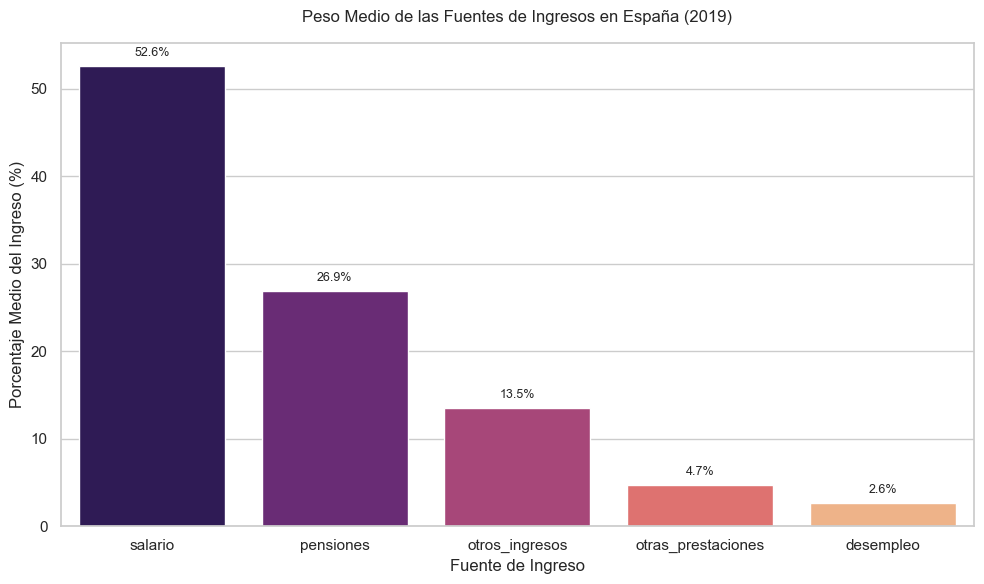

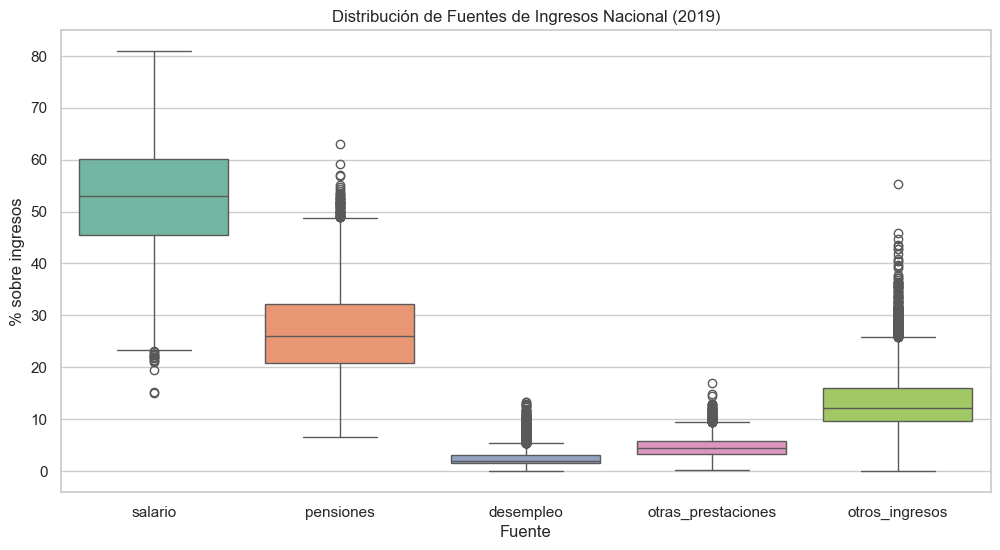


ANÁLISIS ESTRUCTURAL: Fuentes de Ingresos por Tamaño de Municipio (2019)


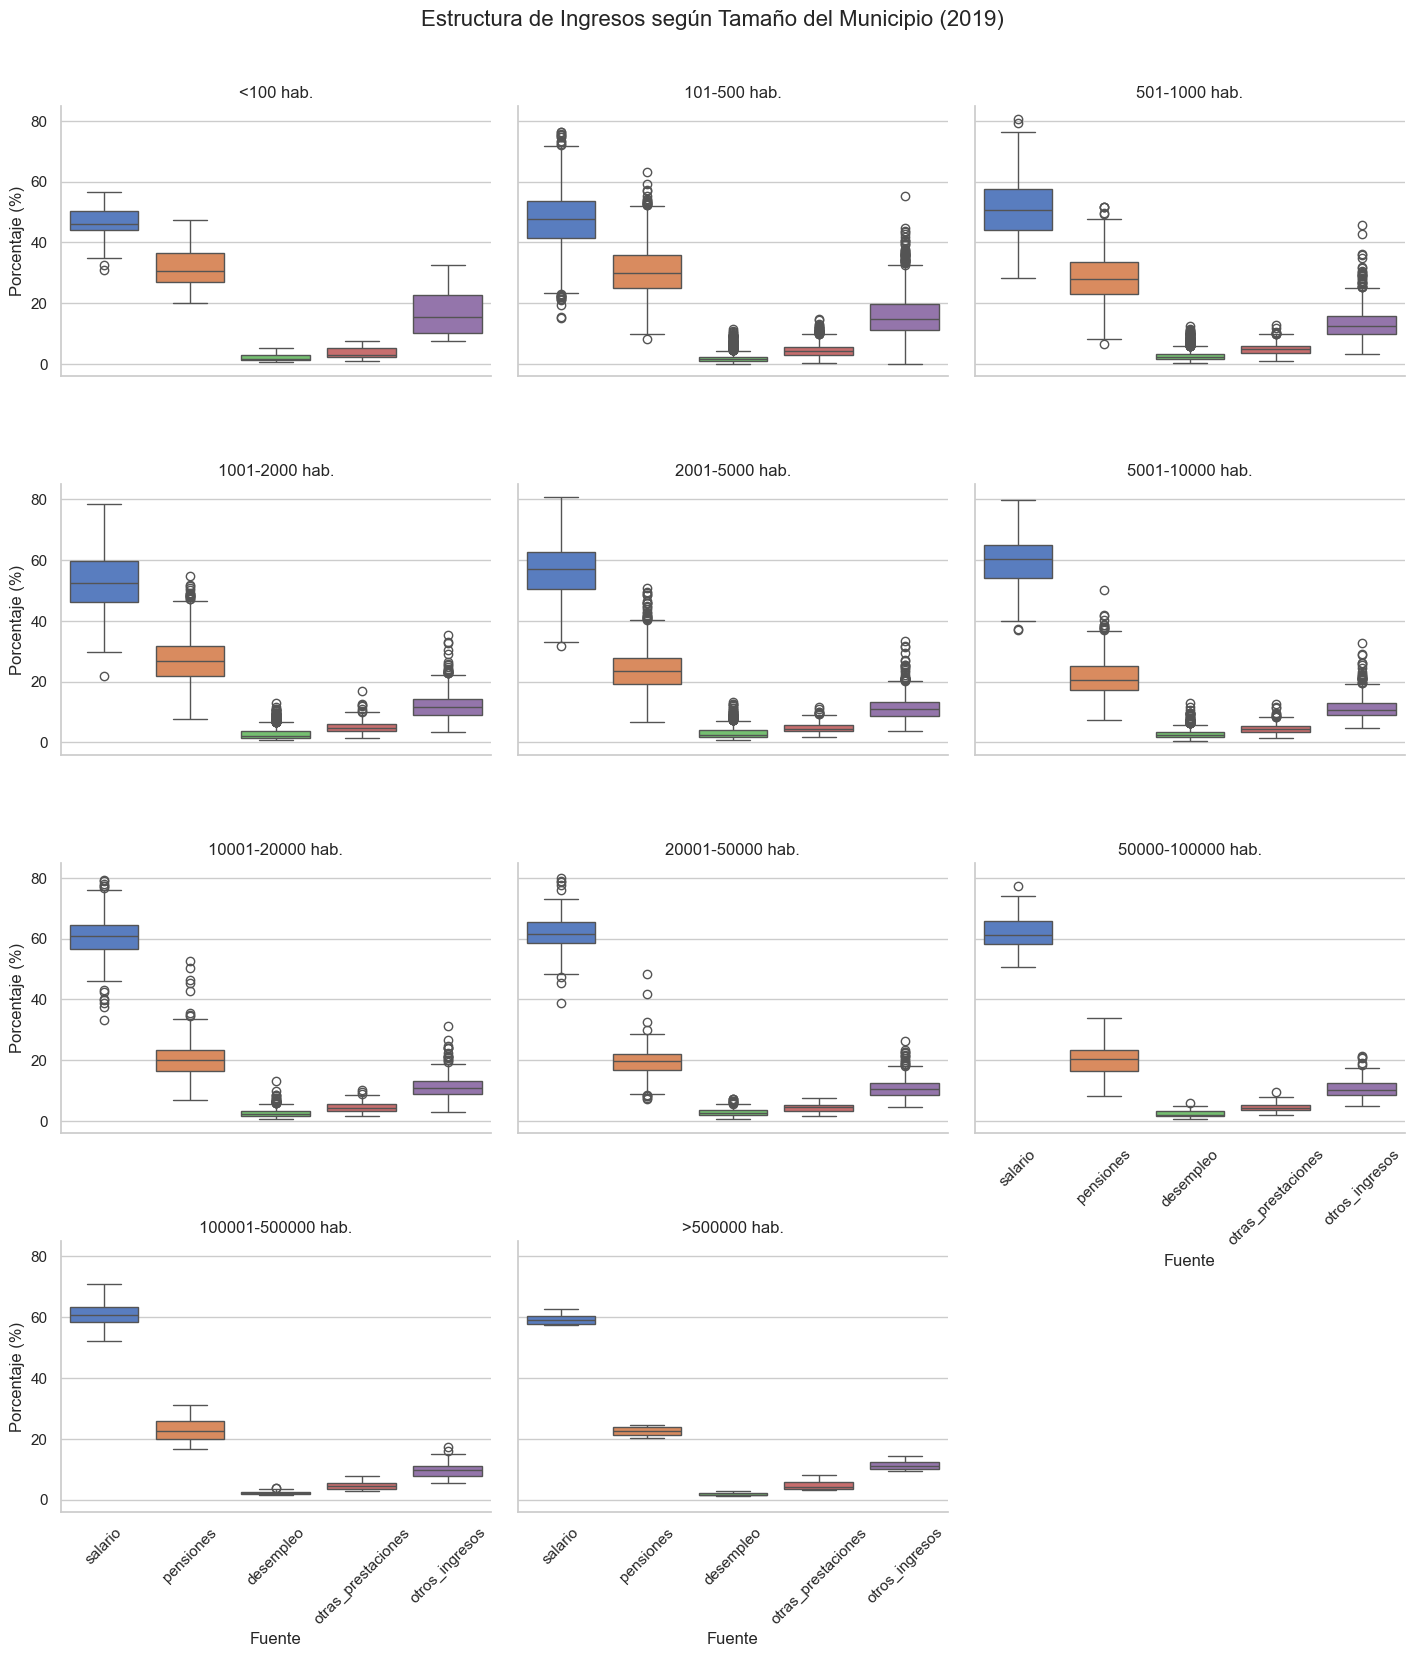

In [53]:
df_fuentes_2019 = eda_fuente_ingresos(df_2019_fuente_ingresos, df_2019_poblacion_csv, anyo="2019")

La distribución del Porcentaje Medio de Ingresos actúa como un indicador del promedio nacional y revela una jerarquía clara: España es, eminentemente, una economía basada en el trabajo. Los salarios constituyen el 52,6% de los ingresos medios, seguidos por las pensiones con un 26,9%. Otras fuentes, como las prestaciones por desempleo o las ayudas sociales, aparecen como componentes residuales que no alcanzan el 5% del peso total.
Sin embargo, el boxplot revela que esta uniformidad es solo aparente. Aunque la mediana del salario es mayoritaria, presenta una volatilidad intermunicipal extrema. Es especialmente significativo el comportamiento de las pensiones y otras rentas: a pesar de tener medianas bajas, el gráfico muestra una alta densidad de outliers en el decil superior. Esto confirma la existencia de municipios con naturalezas económicas opuestas; verdaderas "islas" demográficas donde la dependencia de la prestación pública o de las rentas patrimoniales anula la relevancia del mercado laboral privado.

Al analizar la estructura de ingresos por rango poblacional, se observa una tendencia clara: el crecimiento del municipio correlaciona con una estructura económica más predecible y centrada en el salario.
* Municipios de baja densidad (<100 a 1.000 hab.): Es donde reside la mayor volatilidad económica. La cuota salarial es sensiblemente inferior y la dependencia de las pensiones es mucho más elevada. En los núcleos de menos de 100 habitantes, la brecha entre salario y pensiones se estrecha críticamente, reflejando el envejecimiento demográfico de la "España vaciada".
* Áreas Metropolitanas (>100.000 a >500.000 hab.): El escenario se invierte. El salario se dispara por encima del 60% y la dispersión se reduce drásticamente. Son entornos de ingresos homogéneos, estrechamente vinculados a la actividad profesional y al sector servicios avanzado.

**Posibles Implicaciones para la Modelización Electoral**

Esta segmentación por tamaños sugiere dos frentes de batalla electoral muy distintos:
1.	El "Voto Senior" y la Seguridad Social: En municipios pequeños, donde las pensiones representan el eje vital (con medianas que rozan el 40%), el electorado muestra una sensibilidad extrema a los mensajes sobre la sostenibilidad del sistema público de previsión. La supervivencia económica depende directamente del Estado, lo que suele traducirse en un voto que prima la seguridad y la aversión al riesgo institucional.
2.	El "Voto Activo" Urbano: En las metrópolis, el motor es el salario. Este electorado es más receptivo a políticas de presión fiscal (IRPF), coste de la vida y dinamismo empresarial. En estas zonas, los programas centrados exclusivamente en las pensiones pueden percibirse como secundarios frente a la gestión de la economía productiva.
3.	Transversalidad de las Rentas de Capital: Resulta notable que la categoría de "otros ingresos" (rentas y capital) mantenga valores atípicos constantes independientemente del tamaño del municipio. Esto sugiere un perfil de votante con alto patrimonio distribuido de forma ubicua, cuya motivación de voto podría estar ligada a la fiscalidad patrimonial, con independencia de su entorno geográfico.
En conclusión, los datos sugieren que una estrategia electoral unidimensional ignora la realidad económica del territorio: los incentivos que movilizan a una urbe de 500.000 habitantes (salario) son diametralmente opuestos a los que rigen en un municipio de 500 residentes (pensiones).


## Indicadores de renta

Ahora probamos con los datos extraídos del INE, donde faltan los datos de Navarra, y posteriormente los compararemos con los resultados de dicha comunidad.


INICIANDO ANÁLISIS DE INDICADORES DE RENTA (2019)

AUDITORÍA DE DATOS FALTANTES INDICADORES RENTA (2019)
Total de municipios en el dataset: 8139
Municipios sin datos de renta: 1582 (19.4%)


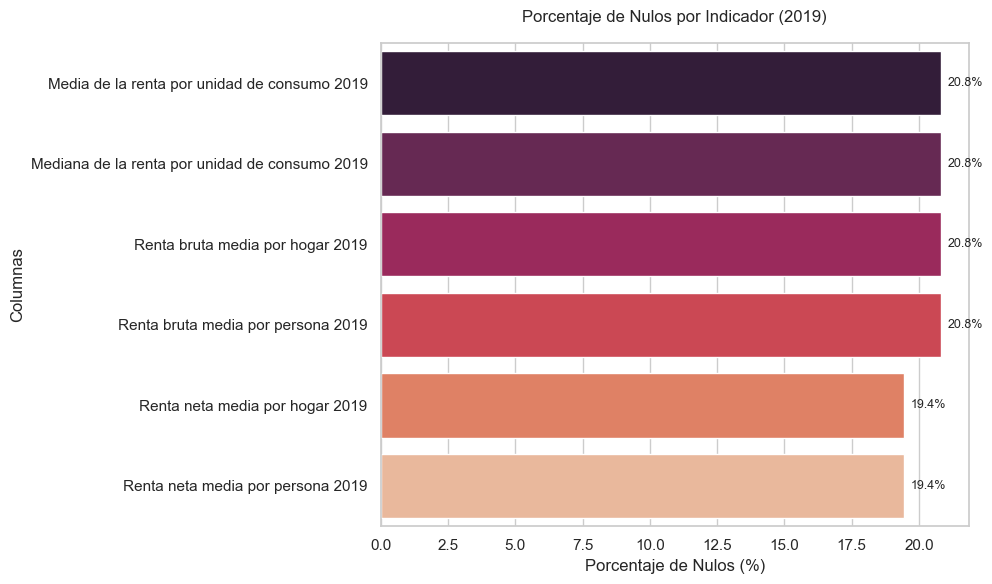

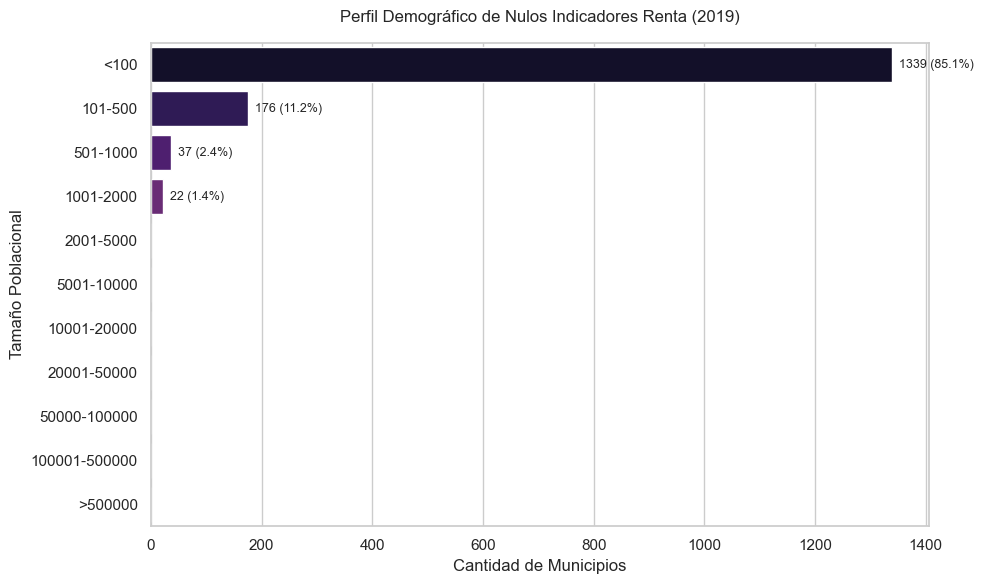


IMPACTO POR PROVINCIA Indicadores Renta (2019)
Top 10 provincias con más nulos Indicadores Renta:
 - Navarra             :  211 municipios (13.4%)
 - Guadalajara         :  182 municipios (11.6%)
 - Burgos              :  171 municipios (10.9%)
 - Soria               :  118 municipios (7.5%)
 - Ávila               :  100 municipios (6.4%)
 - Teruel              :   96 municipios (6.1%)
 - Zaragoza            :   88 municipios (5.6%)
 - Salamanca           :   87 municipios (5.5%)
 - Segovia             :   79 municipios (5.0%)
 - Cuenca              :   78 municipios (5.0%)


In [54]:
df_indicadores_renta_2019 = eda_indicadores_renta( df_renta_completo = df_2019_renta_disponible, df_pob = df_poblacion_superficie_2019, anyo = "2019")

El análisis de calidad revela que el 19,4% de los municipios (1.582 localidades) carece de datos de renta para el año 2019. Esta ausencia de información no responde a errores de registro, sino a la aplicación estricta del secreto estadístico por parte del INE, que busca proteger la privacidad de los ciudadanos en zonas donde la baja densidad de población permitiría identificar rentas individuales.

Demográficamente, este "apagón" informativo es absoluto en los estratos de municipios con menos de 1.000 habitantes, coincidiendo plenamente con el perfil de la España rural vaciada. Geográficamente, el impacto se concentra con especial dureza en Navarra (13,4% de los nulos), Guadalajara (11,6%) y Burgos (10,9%), seguidas por otras provincias con alta dispersión como Soria y Ávila.

Estos resultados demuestran que los indicadores de renta poseen un sesgo urbano intrínseco. Esto implica que, para casi el 20% del territorio nacional, precisamente el más envejecido, la renta no es un predictor electoral viable por falta de datos, lo que obliga a recurrir a variables alternativas para analizar su comportamiento en las urnas.


INICIANDO ANÁLISIS DE INDICADORES DE RENTA (2019)

AUDITORÍA DE DATOS FALTANTES INDICADORES RENTA (2019)
Total de municipios en el dataset: 8139
Municipios sin datos de renta: 1371 (16.8%)


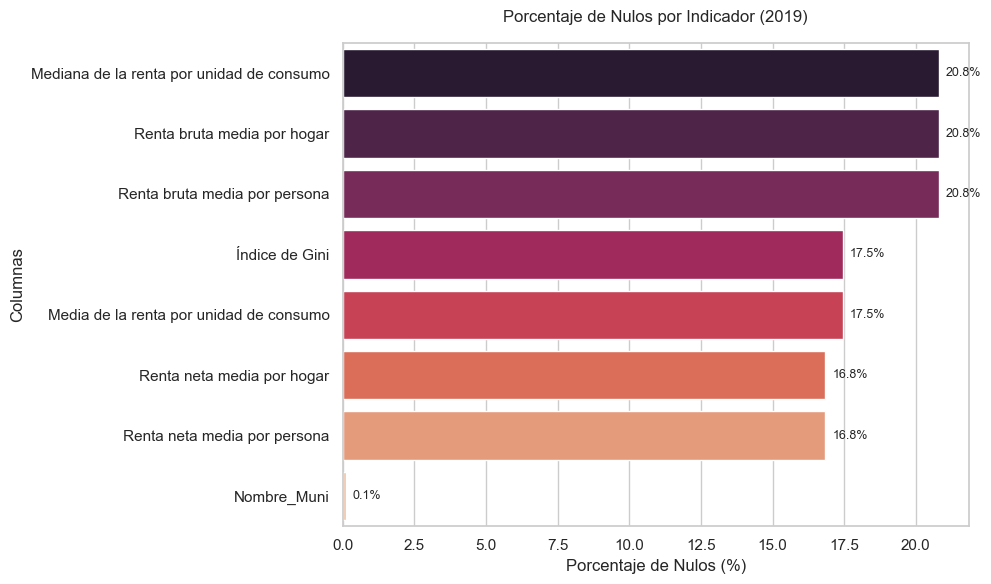

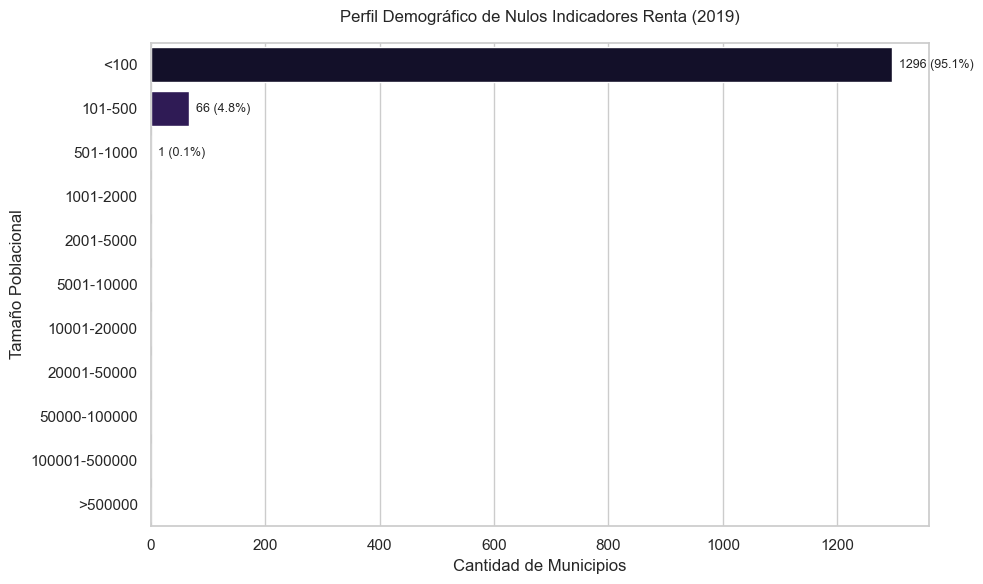


IMPACTO POR PROVINCIA Indicadores Renta (2019)
Top 10 provincias con más nulos Indicadores Renta:
 - Guadalajara         :  182 municipios (13.4%)
 - Burgos              :  171 municipios (12.5%)
 - Soria               :  118 municipios (8.7%)
 - Ávila               :  100 municipios (7.3%)
 - Teruel              :   96 municipios (7.0%)
 - Zaragoza            :   88 municipios (6.5%)
 - Salamanca           :   87 municipios (6.4%)
 - Segovia             :   79 municipios (5.8%)
 - Cuenca              :   78 municipios (5.7%)
 - Palencia            :   76 municipios (5.6%)


In [55]:
df_indicadores_renta_2019 = eda_indicadores_renta( df_renta_completo = df_renta_completa.reset_index(), df_pob = df_poblacion_superficie_2019, anyo = "2019")

Podemos observar que, al añadir los datos de Navarra, el porcentaje de valores nulos disminuye un 3%. Además, estos se concentran prácticamente en dos franjas, a diferencia de las cuatro que encontrábamos sin los datos navarros. Si bien es cierto que no son exactamente dos (ya que existe un municipio de entre 501 y 1000 habitantes sin información), procederemos a identificar de qué municipio se trata.

In [56]:
col_renta = [c for c in df_indicadores_renta_2019.columns if 'Renta neta media por persona' in c][0]
codigos_nulos = df_indicadores_renta_2019[df_indicadores_renta_2019[col_renta].isna()]['Cod_Muni']

df_pob_temp = df_poblacion_superficie_2019.copy()
df_pob_map_id = 'id_municipio' if 'id_municipio' in df_pob_temp.columns else df_pob_temp.columns[0]
df_pob_temp[df_pob_map_id] = df_pob_temp[df_pob_map_id].astype(str).str.zfill(5)

nulos_rango = pd.merge(
    df_pob_temp,
    df_indicadores_renta_2019[df_indicadores_renta_2019['Cod_Muni'].isin(codigos_nulos)],
    left_on=df_pob_map_id,
    right_on='Cod_Muni'
)

filtro_final = nulos_rango[(nulos_rango['poblacion_total'] > 500) & (nulos_rango['poblacion_total'] <= 1000)]
print(f"\nMUNICIPIOS DE 501-1000 HABITANTES SIN DATOS DE RENTA ({len(filtro_final)} casos):")
cols_mostrar = ['Nombre_Muni', 'poblacion_total']
print(filtro_final[cols_mostrar].sort_values('poblacion_total', ascending=False))


MUNICIPIOS DE 501-1000 HABITANTES SIN DATOS DE RENTA (1 casos):
     Nombre_Muni  poblacion_total
8  Arraia-Maeztu              726


Vemos que el municipio sin datos de la categoría de 501-1000 habitantes pertenece a la provincia de Álava, en el País Vasco.


GENERANDO VISUALIZACIONES DE DISTRIBUCIÓN PARA 2019


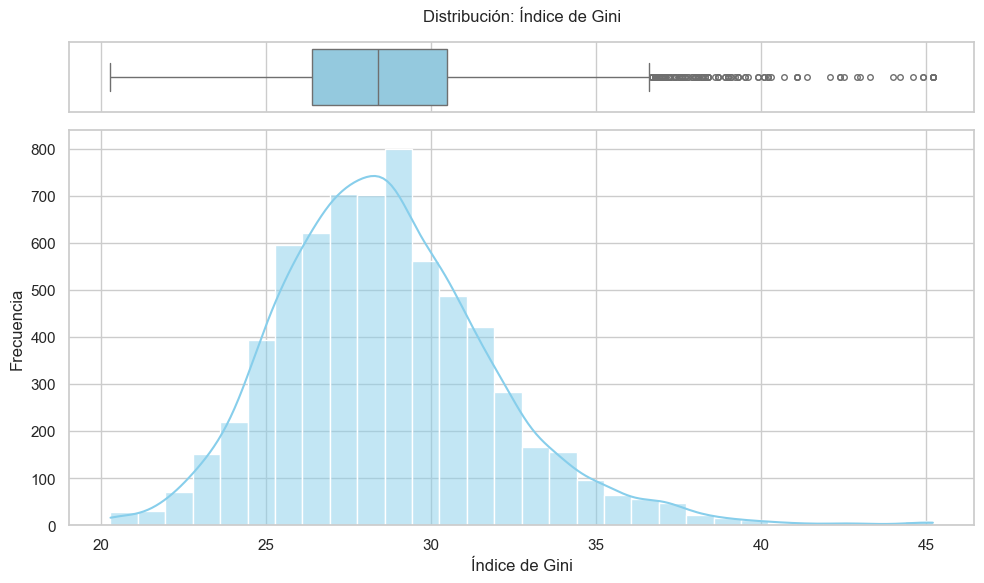

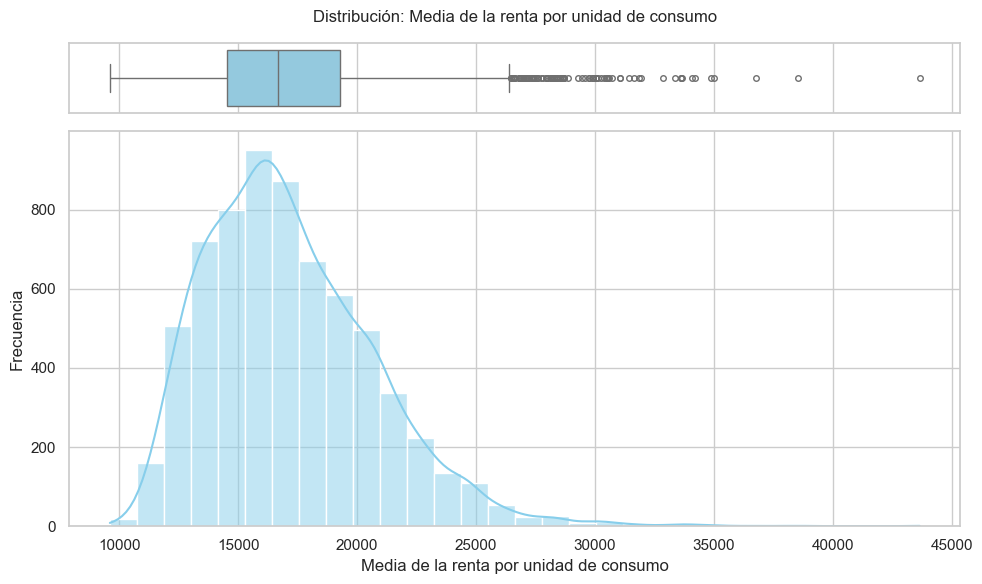

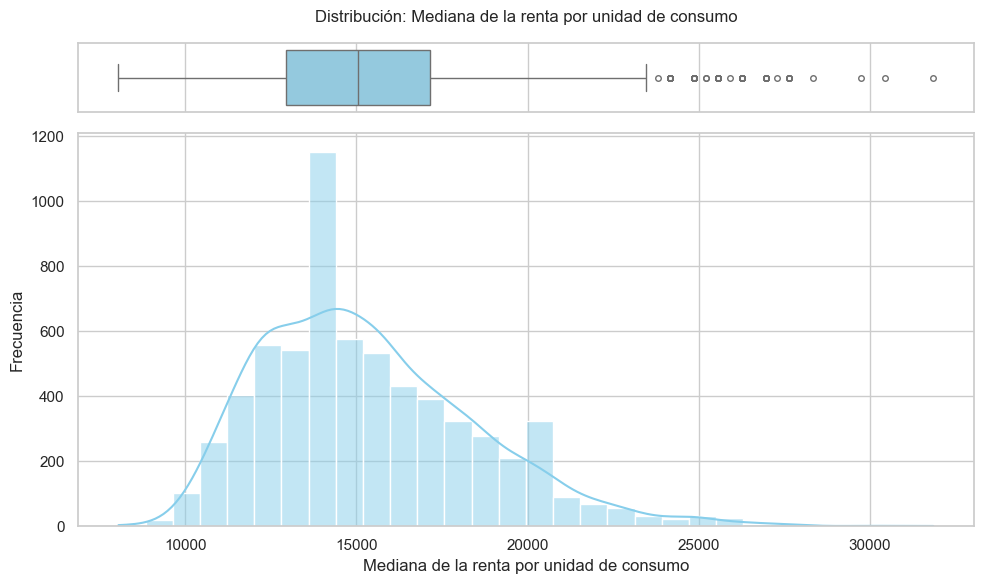

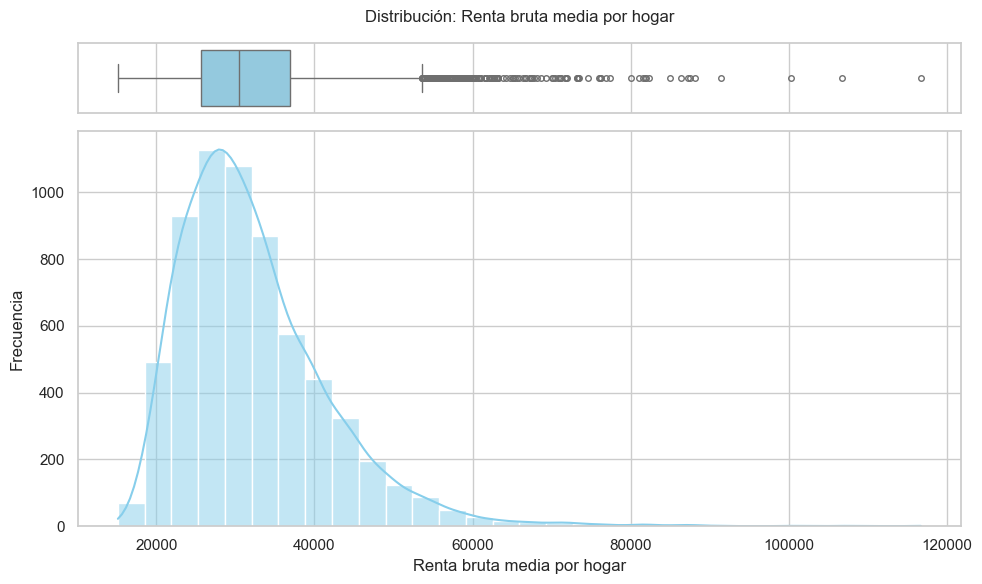

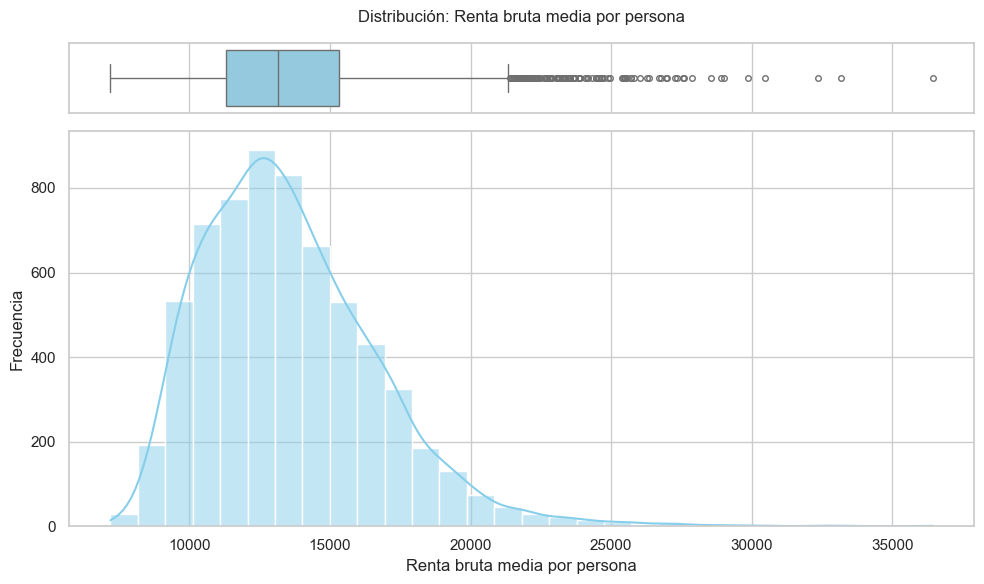

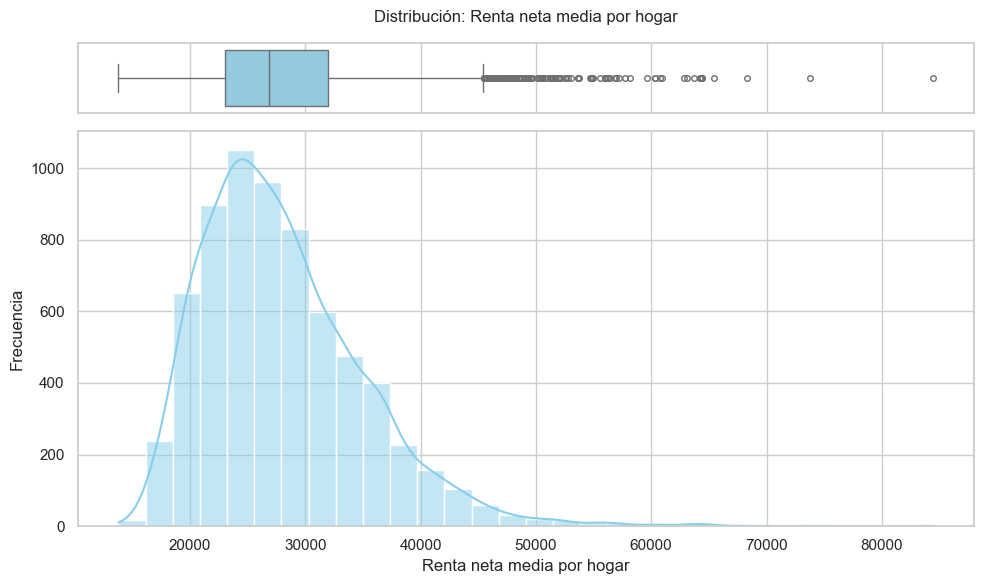

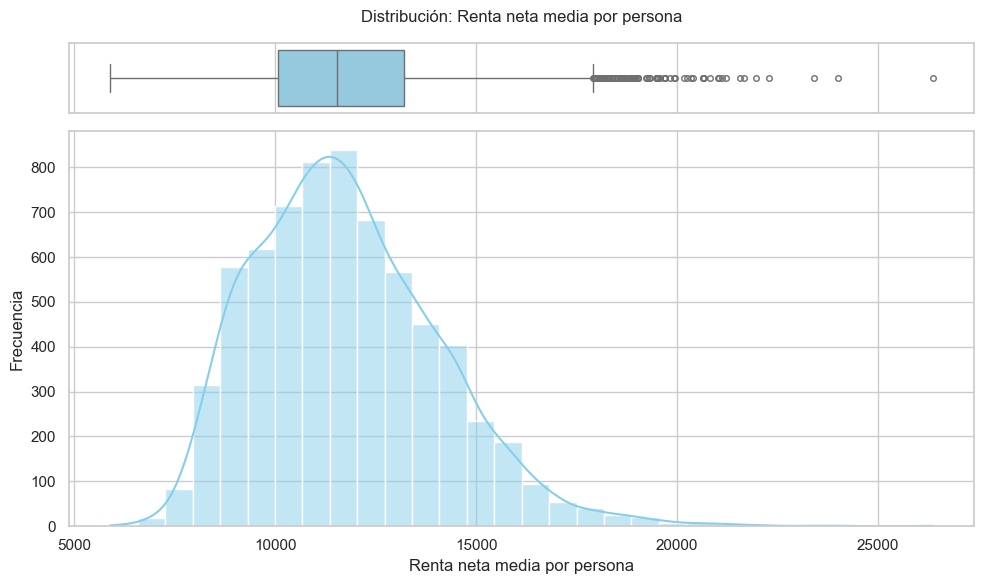

In [57]:
visualizar_histogramas_renta(df_indicadores_renta_2019, anyo="2019")

El análisis de la morfología de la renta en España revela una desigualdad estructural caracterizada por un marcado sesgo positivo. La distribución muestra una "larga cola" hacia la derecha, donde una minoría concentra ingresos excepcionalmente altos que distorsionan el promedio aritmético. Este fenómeno provoca que el ciudadano típico —representado por la moda— perciba ingresos significativamente inferiores a la media nacional, la cual se ve inflada por valores atípicos que llegan a cuadruplicar la mediana. Esta segregación geográfica de la riqueza sugiere la existencia de municipios que operan bajo una lógica económica totalmente aislada del comportamiento general del país.

Al comparar la renta bruta frente a la neta, se evidencia el impacto del sistema redistributivo. La transición hacia valores netos produce un desplazamiento de la curva hacia la izquierda y una compresión de la varianza, reduciendo la dispersión de los ingresos más altos. Mientras que la renta bruta por hogar se sitúa cerca de los 30.000€, la distribución neta se estrecha en torno a los 25.000€, acortando la distancia entre ellos. No obstante, el uso de la Unidad de Consumo (con un pico en los 16.000€) resulta ser la métrica más fiel para corregir las economías de escala de los hogares, mostrando una mayor homogeneidad en los niveles de vida reales en gran parte del territorio.

## Fase 2: Análisis del Target (Votos y Abstención)
Aquí es donde entiendes la "respuesta" que el modelo debe aprender.

2.1. Participación y Abstención
Acción: * %_Abstención = (Abstenciones / Censo_Electoral) * 100.
Análisis: * Busca si hay patrones geográficos. ¿Se vota menos en los municipios más pobres? ¿O en los más rurales?
* Identifica municipios con abstención extrema (>40%).

2.2. Concentración y Bloques
Acción: Agrupa los votos por Bloques Ideológicos (usando tu fichero de ideología).

* Bloque_Izquierda: PSOE + Sumar/Podemos + Regionalistas Izquierda.
* Bloque_Derecha: PP + VOX + Regionalistas Derecha.

Análisis:
* Dominancia: ¿En cuántos municipios el bloque de derecha supera el 60%? ¿Y el de izquierda?
* Fragmentación: ¿Cuántos partidos sacan más de un 5% en el mismo municipio? Esto te dirá dónde es más difícil predecir el escaño.

2.3. El fenómeno Regionalista
Acción: Analiza el peso de los partidos regionales que has sumado a los estatales.
* Análisis: ¿Hay provincias donde la suma de partidos regionales cambia el ganador del bloque? (Muy común en Cataluña o País Vasco).

Iniciando EDA de Resultados Electorales (2019)
RESUMEN ESTADÍSTICO NACIONAL DE CANDIDATURAS
Total de candidaturas analizadas: 90

No hay partidos con 0 votos en el recuento.

TOP 5 - CANDIDATURAS MÁS VOTADAS:
 - psoe                      |  5,332,684 votos |  22.32%
 - pp                        |  4,892,909 votos |  20.47%
 - vox                       |  3,640,377 votos |  15.23%
 - cs                        |  1,637,341 votos |   6.85%
 - podemos-iu                |  1,231,449 votos |   5.15%

TOP 5 - CANDIDATURAS MENOS VOTADAS (con al menos 1 voto):
 - udt                       |         26 votos |  0.00011%
 - c_21                      |         64 votos |  0.00027%
 - los_verdes                |         99 votos |  0.00041%
 - izar                      |        112 votos |  0.00047%
 - dpl                       |        210 votos |  0.00088%


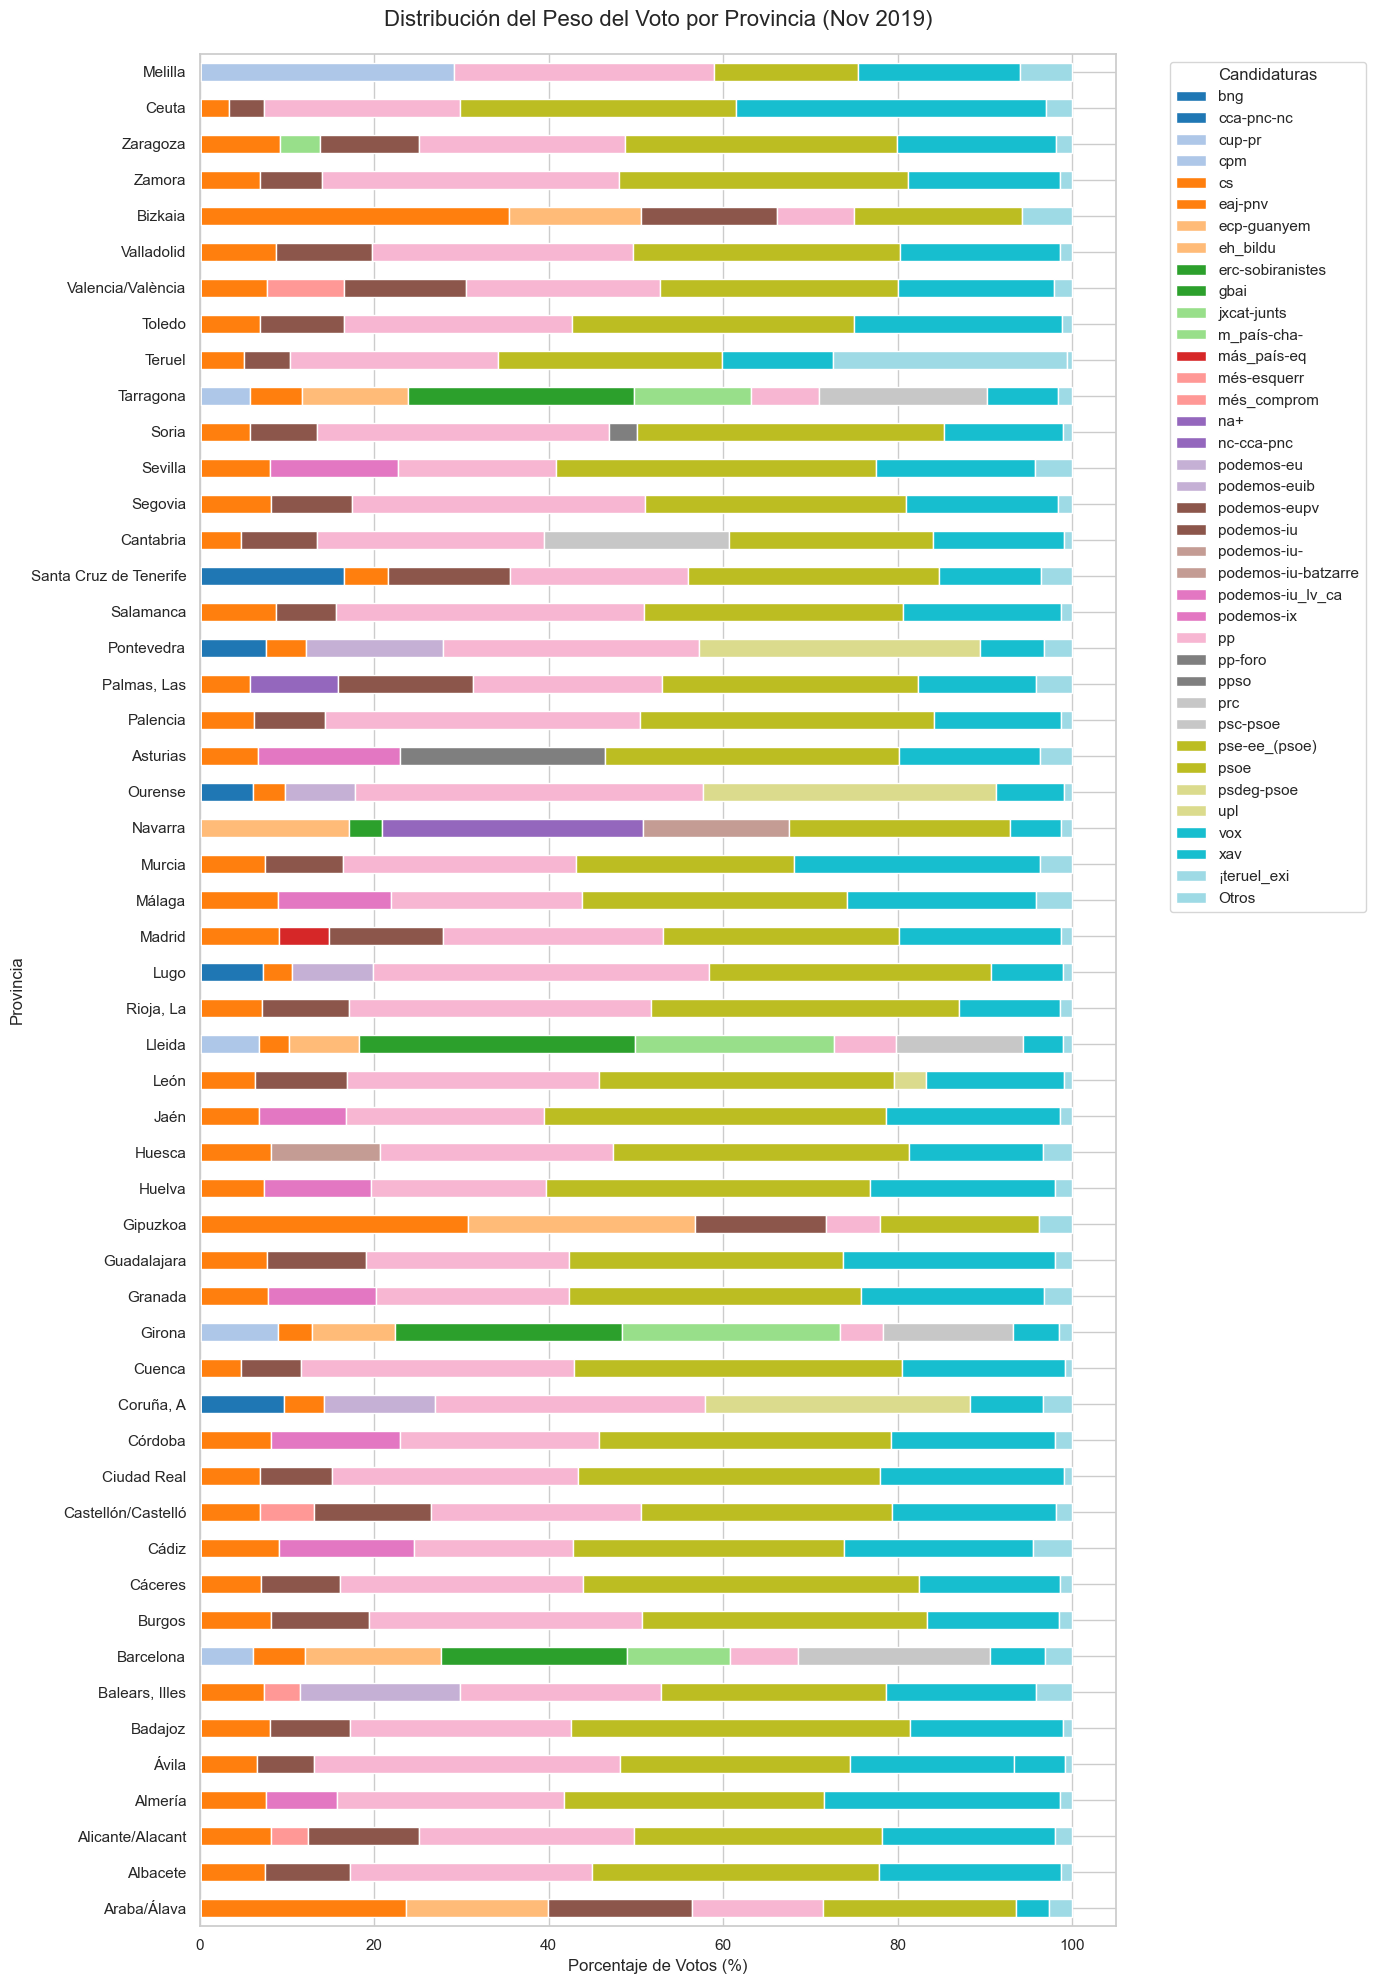


--- Generando Gráficos Individuales por Provincia ---


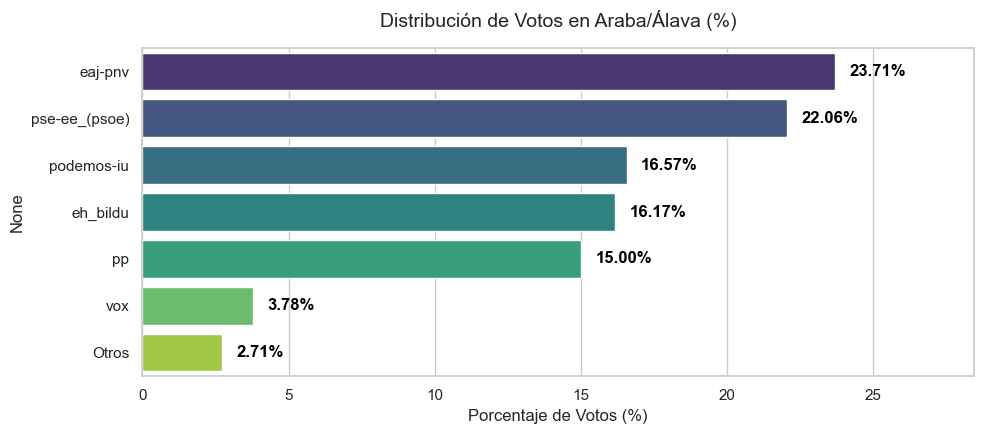

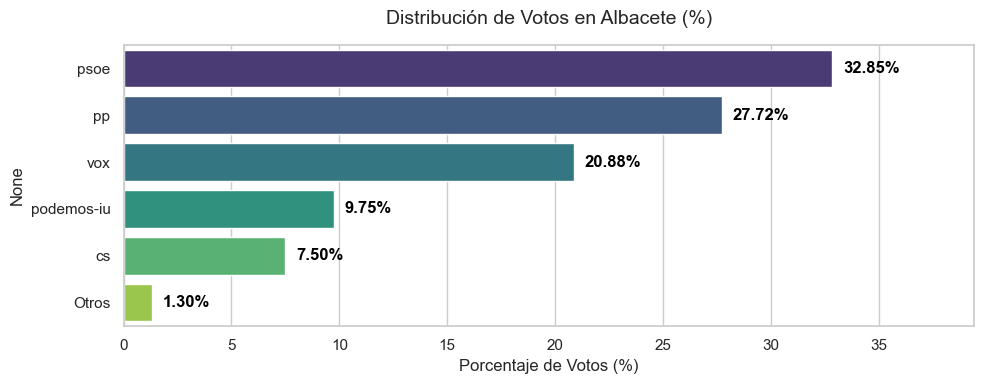

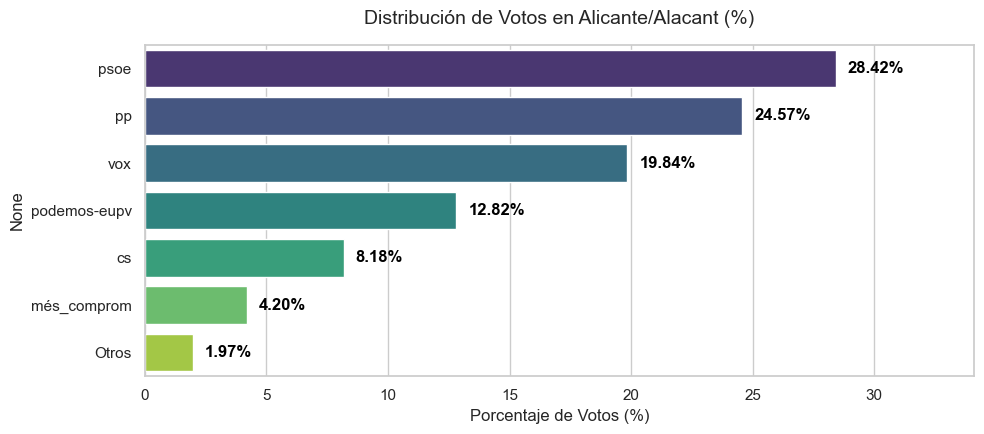

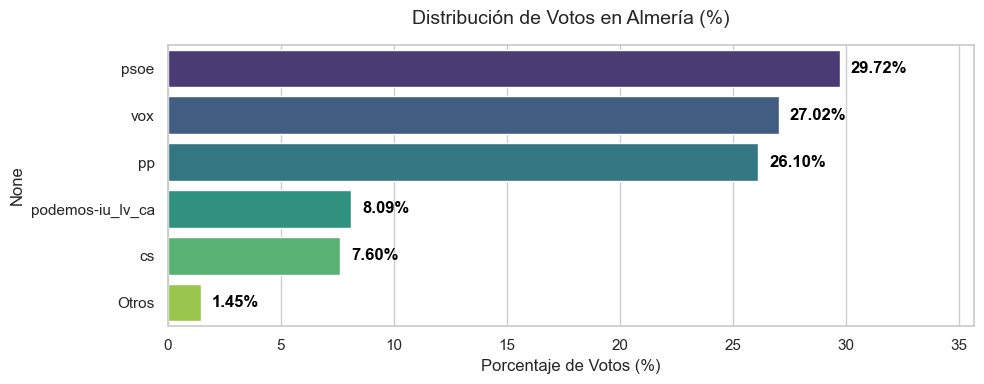

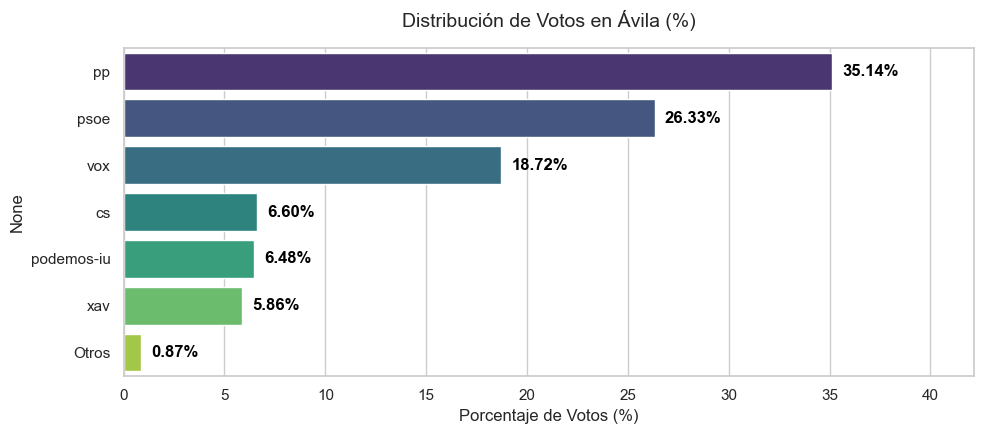

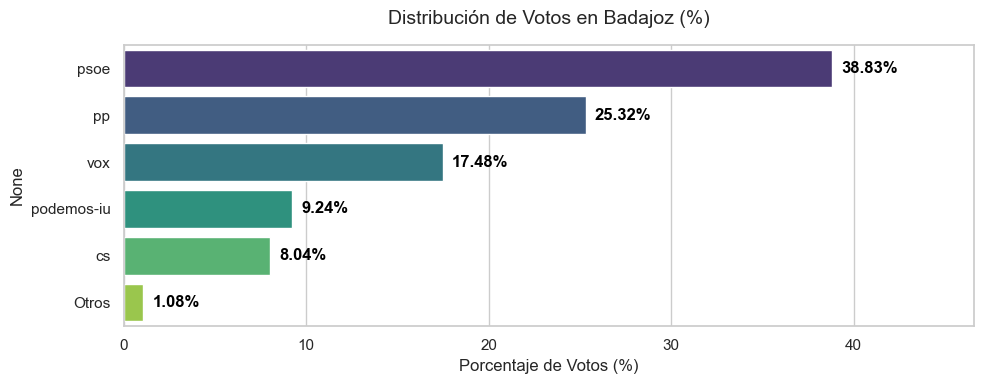

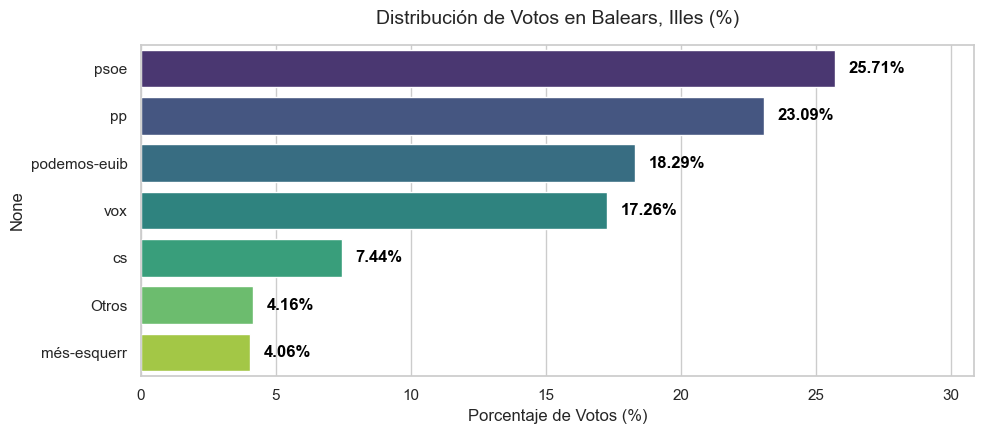

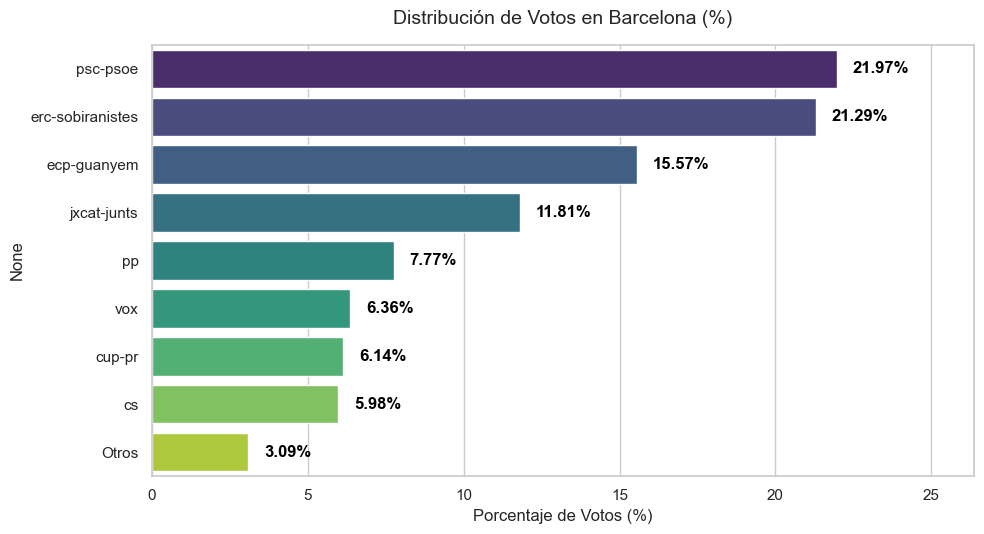

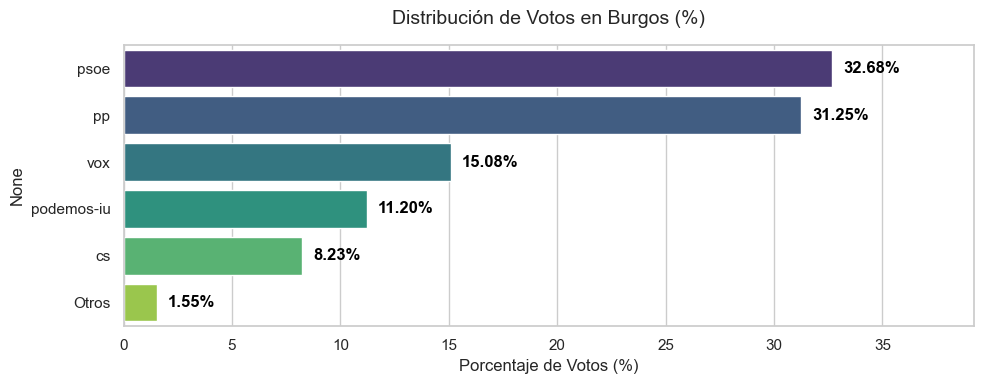

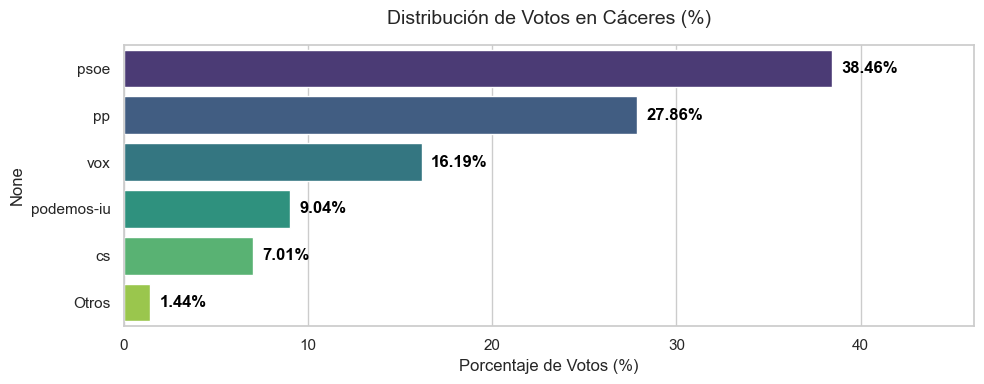

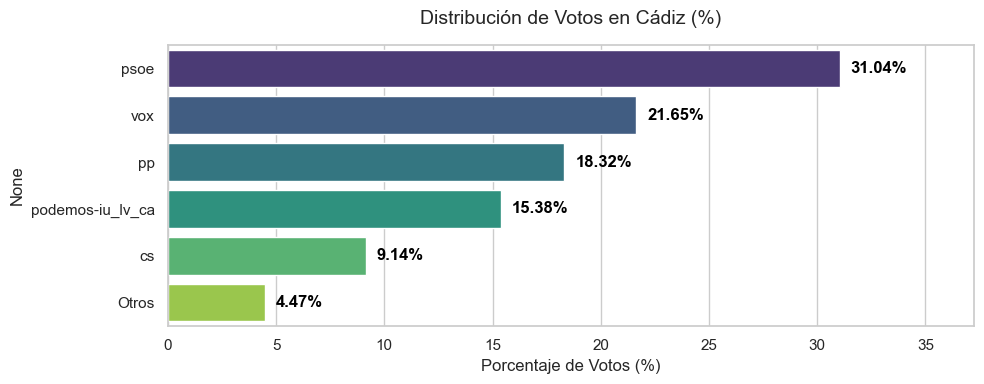

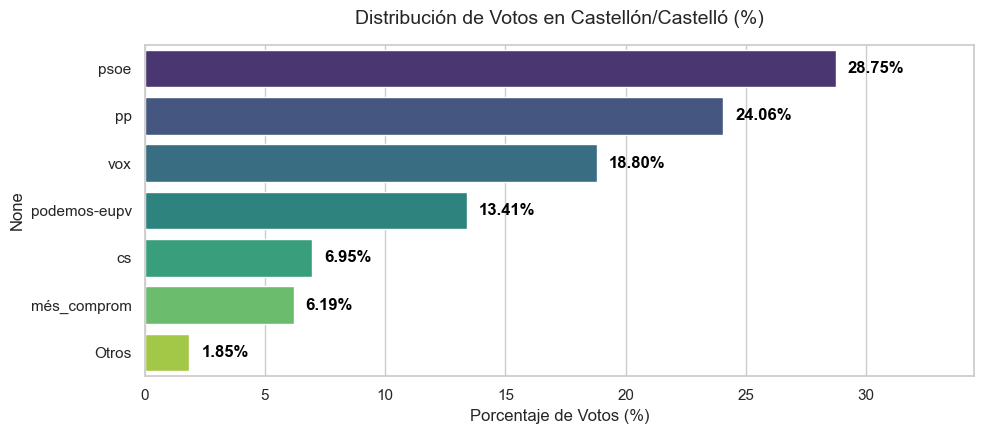

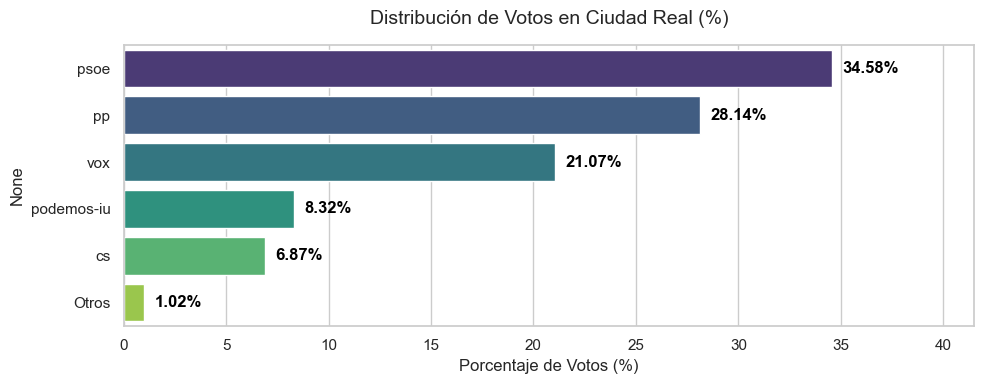

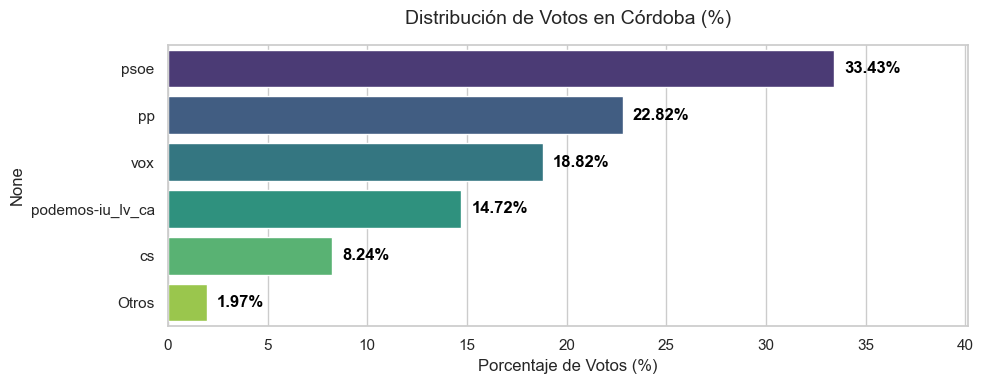

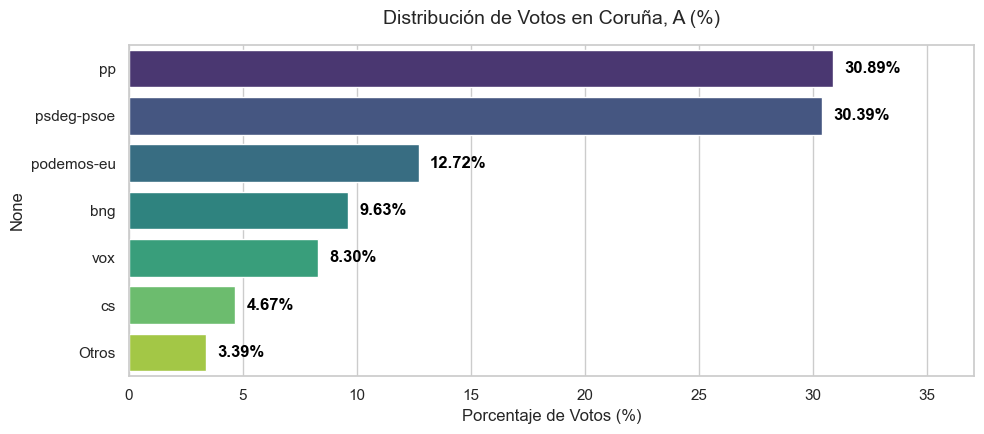

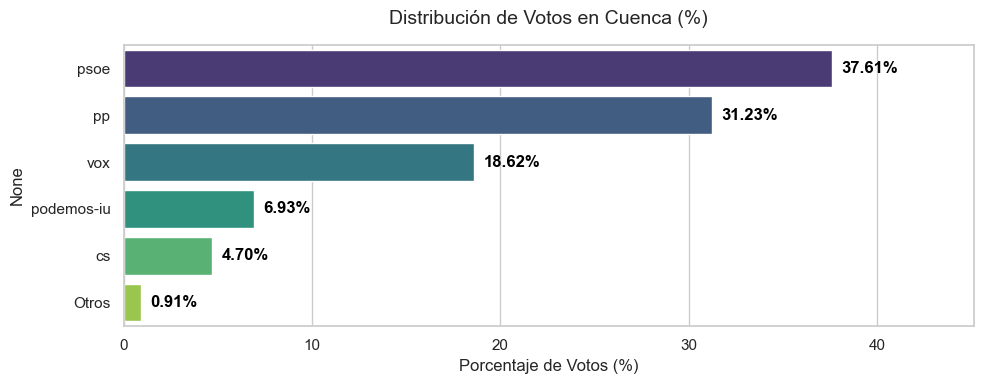

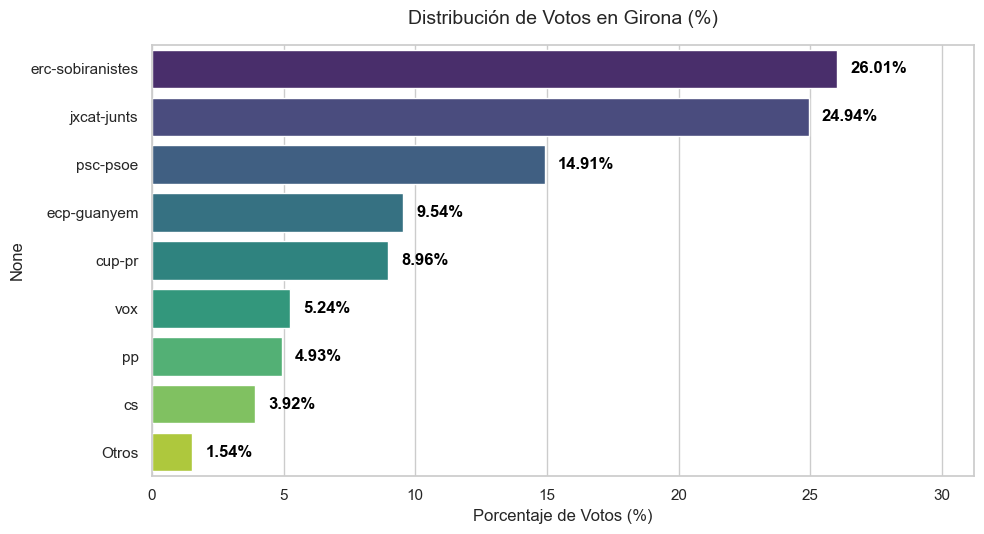

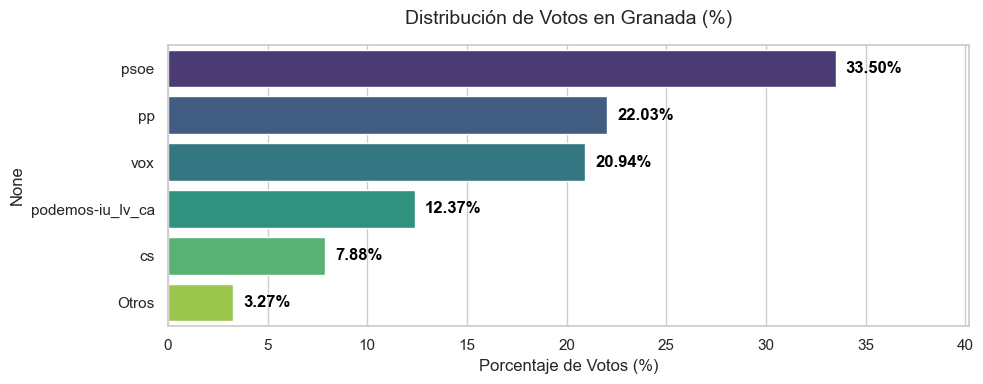

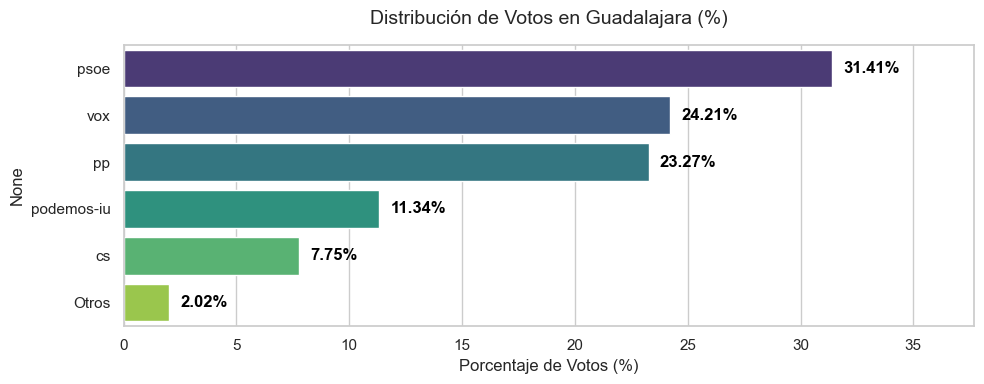

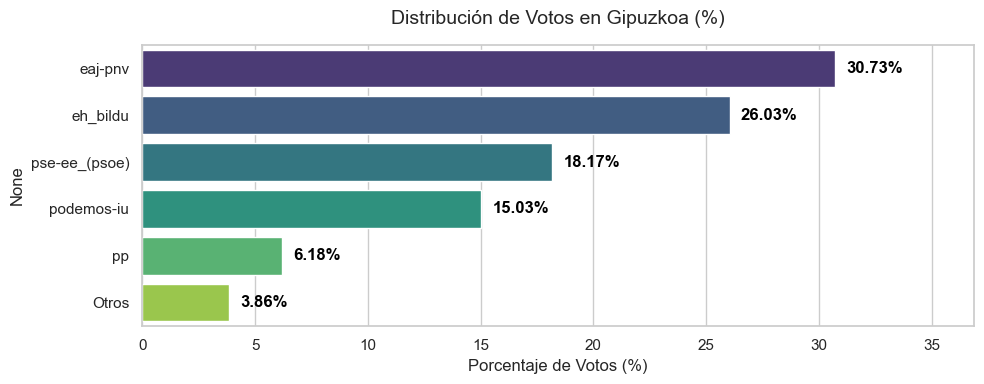

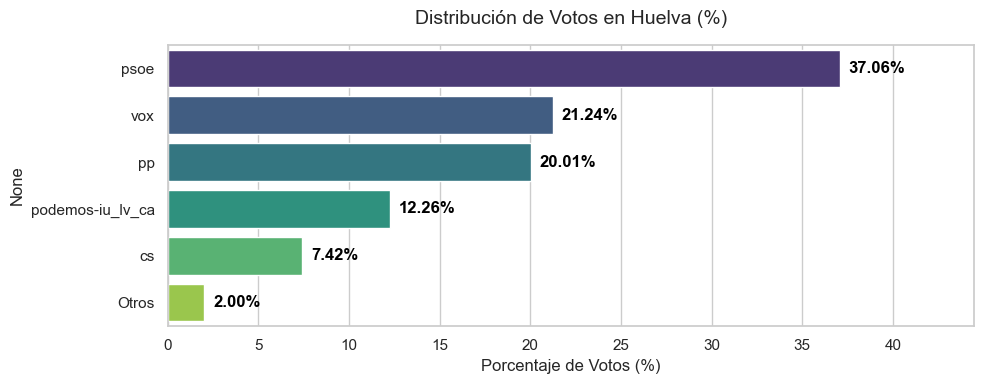

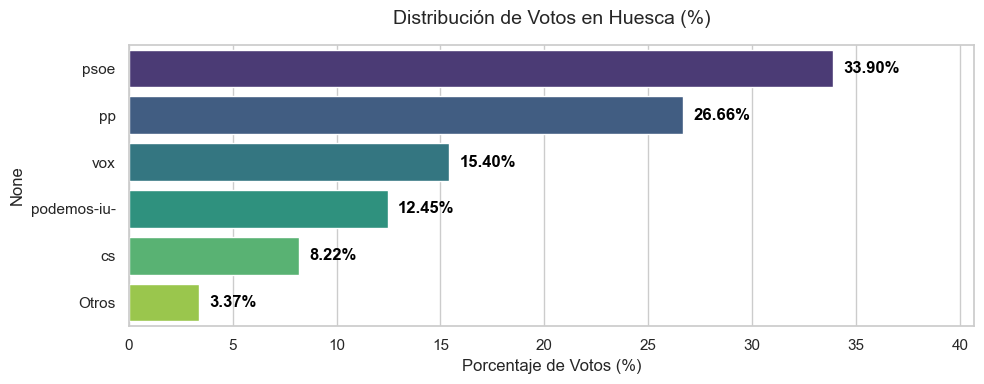

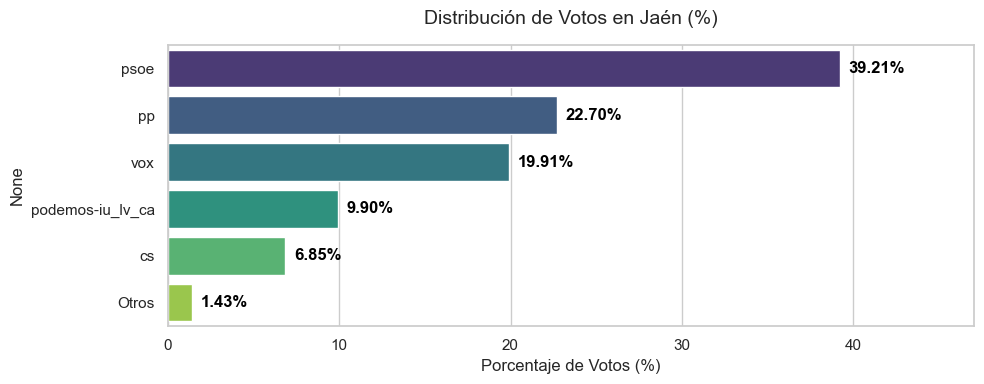

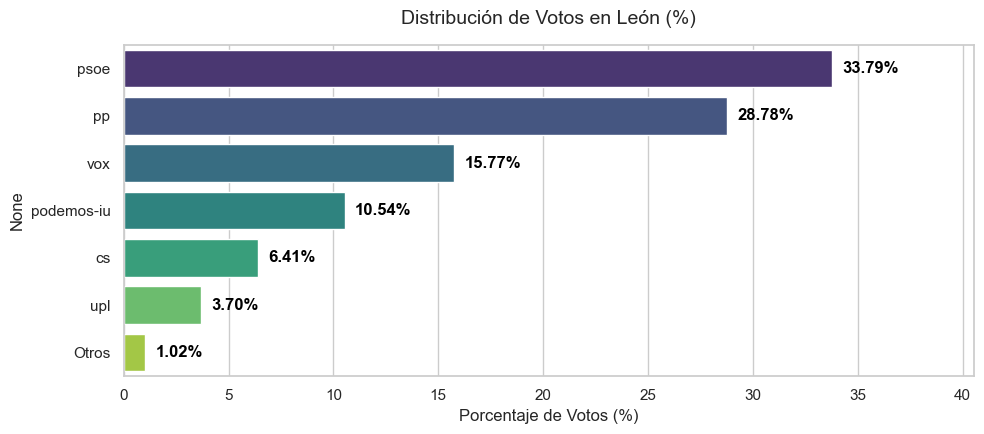

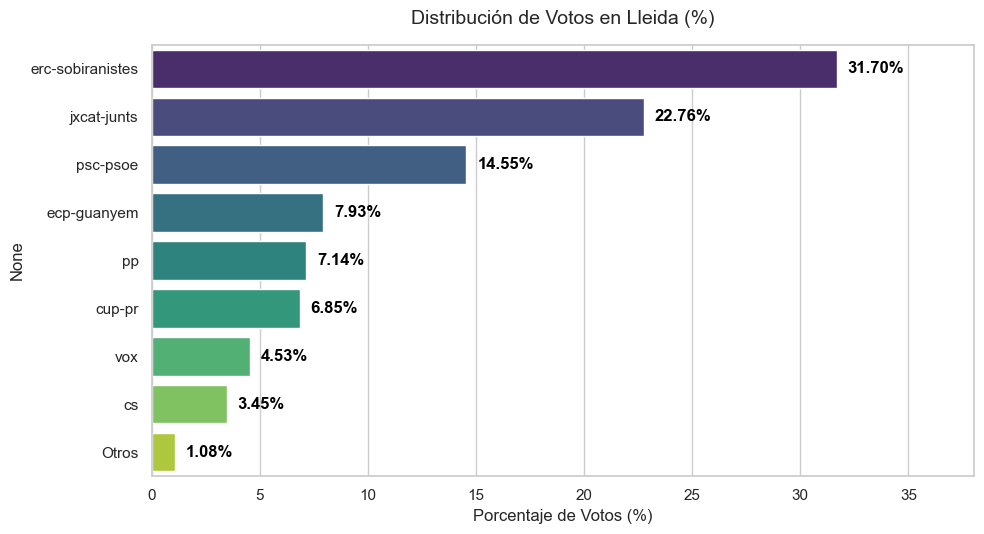

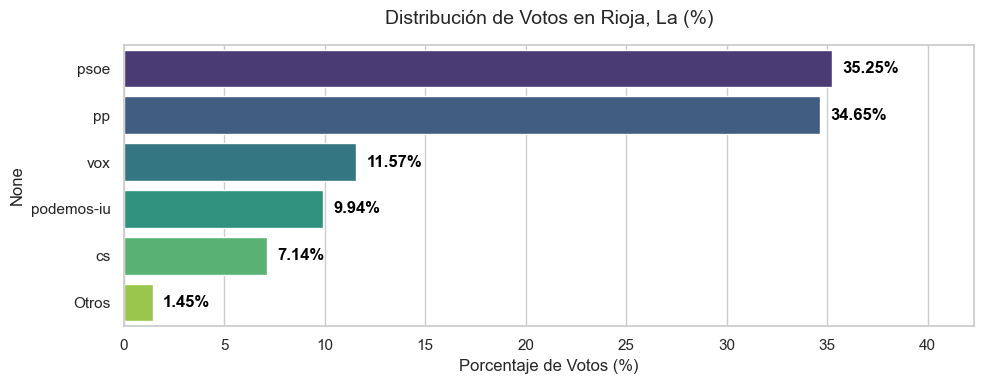

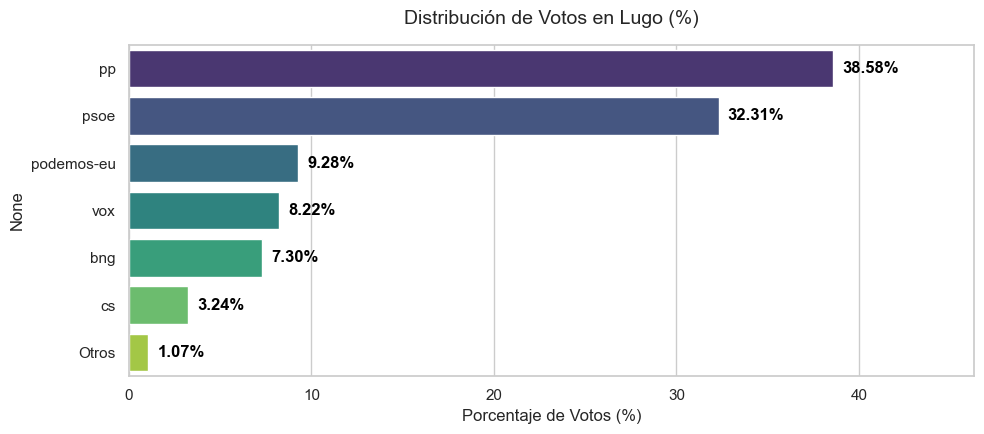

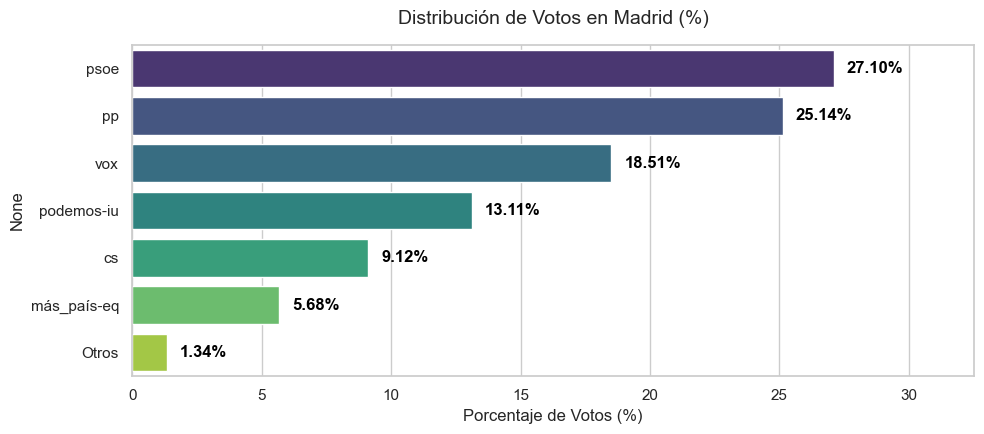

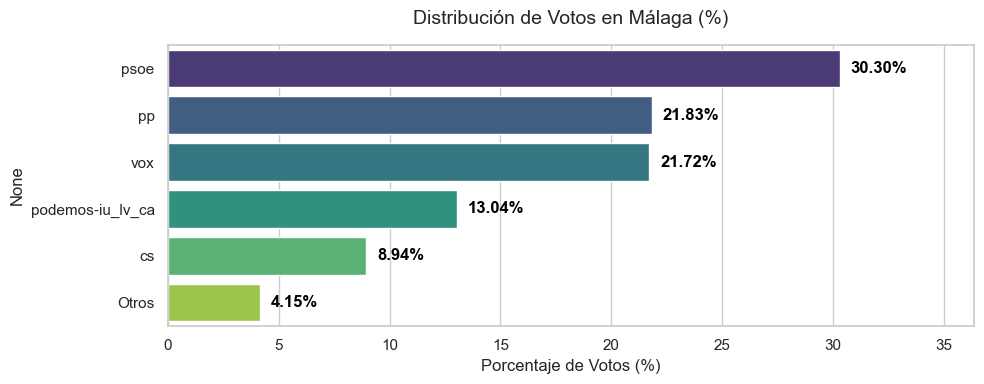

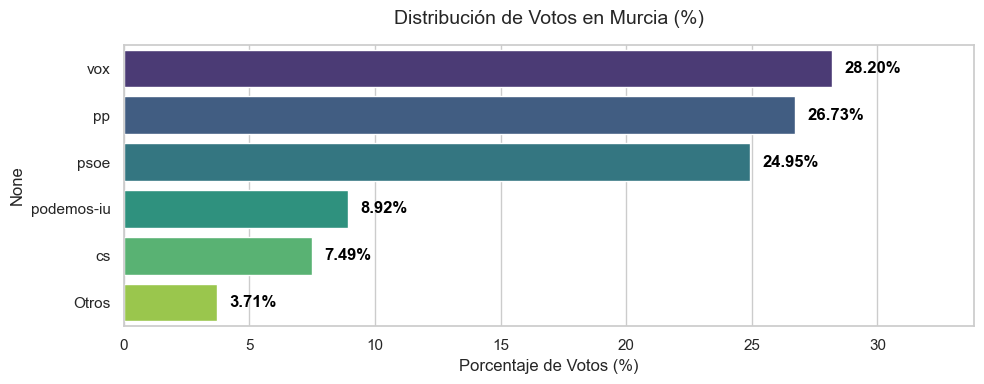

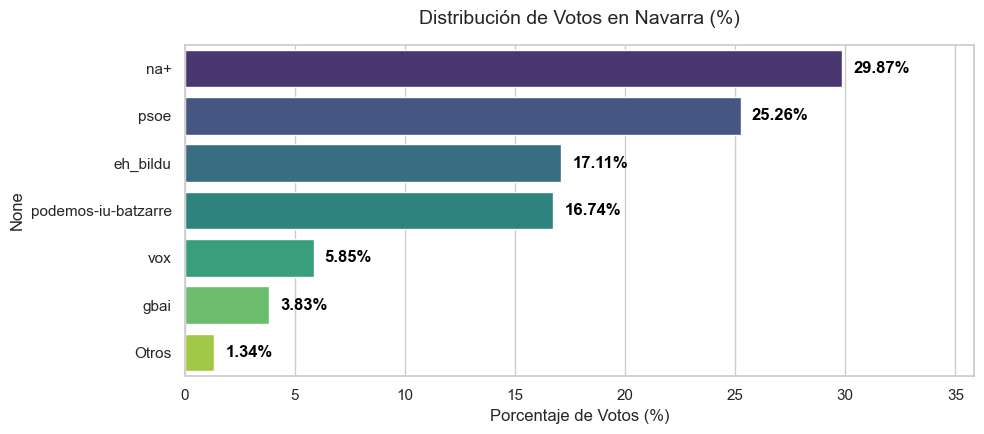

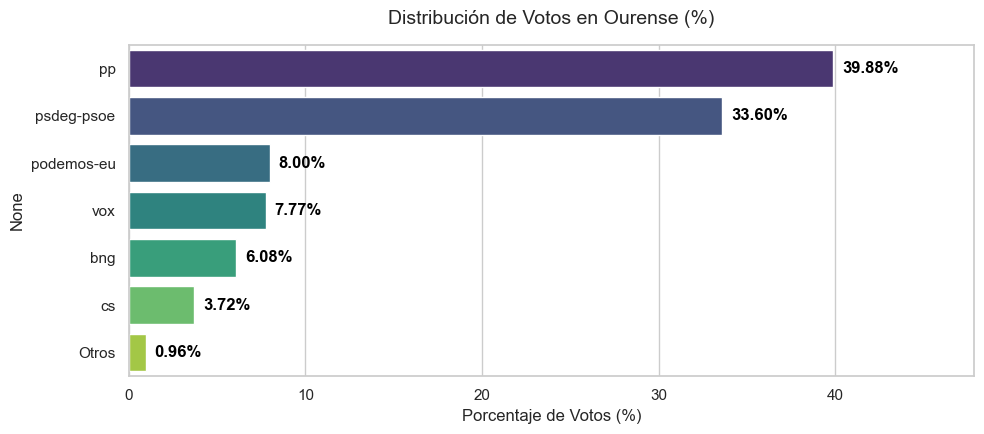

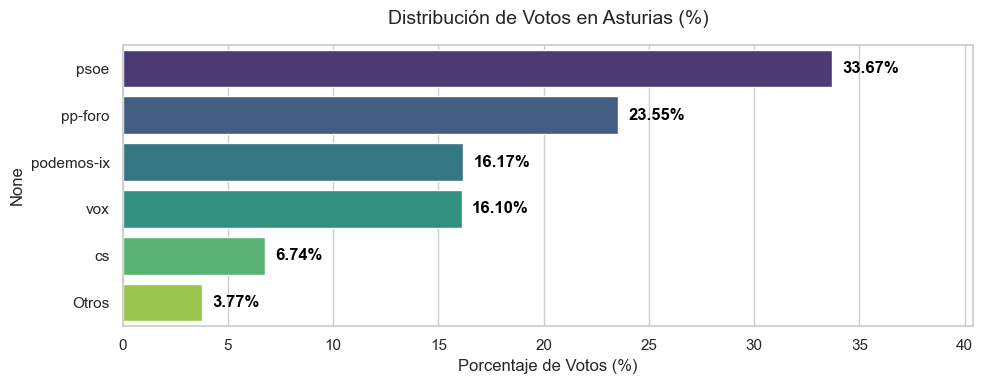

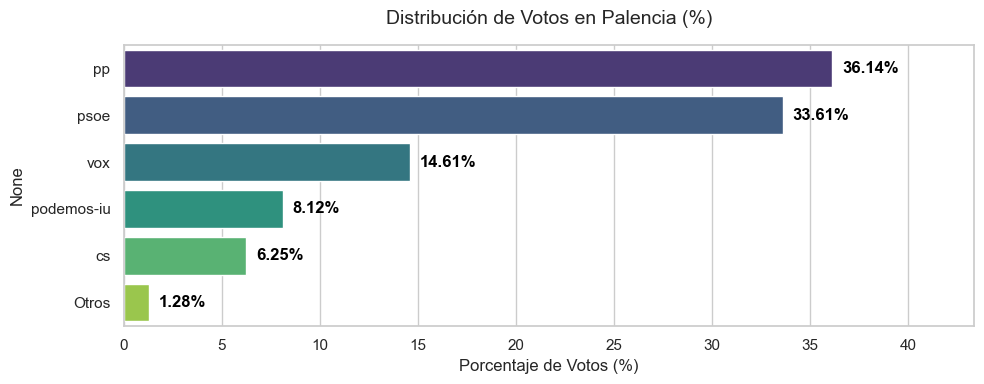

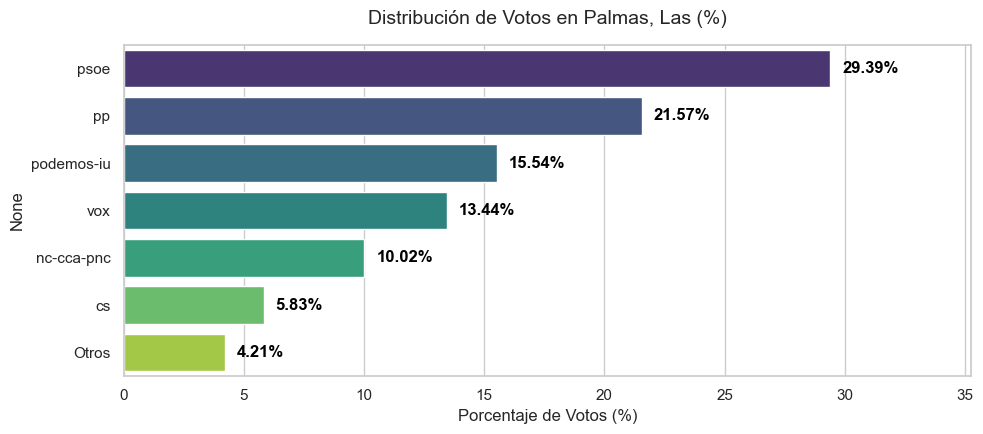

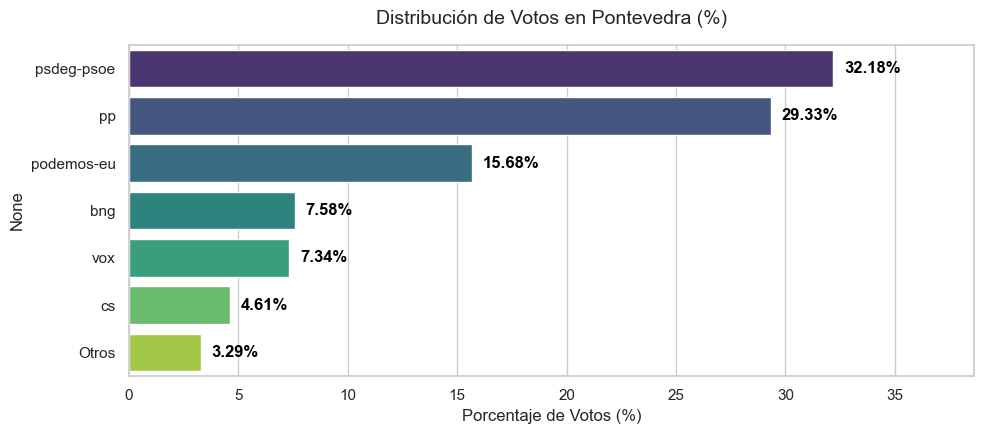

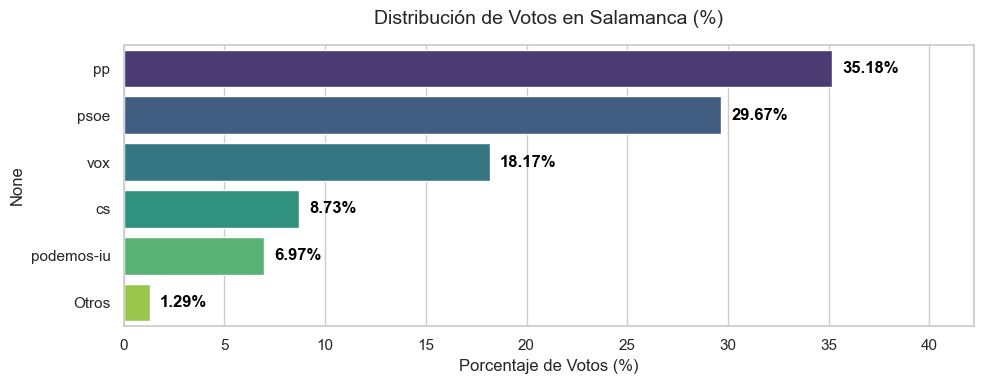

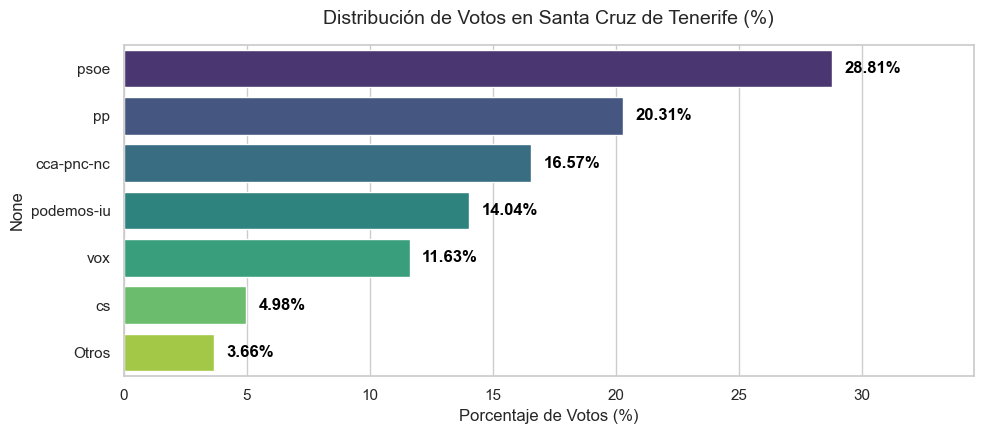

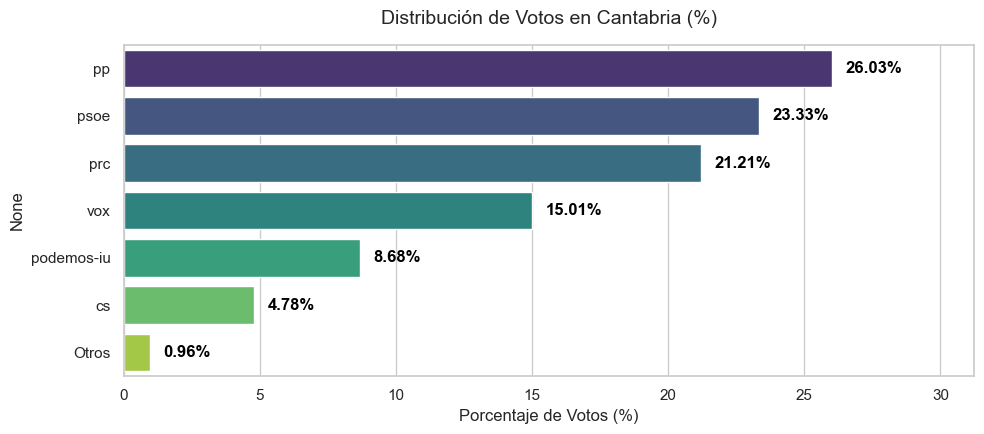

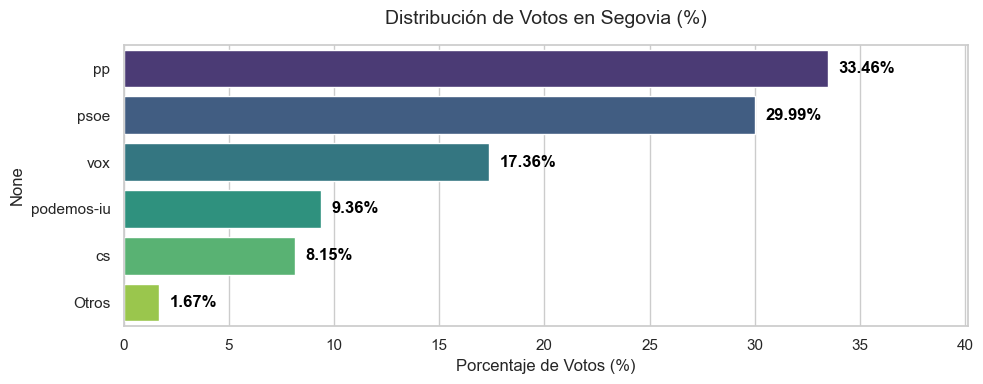

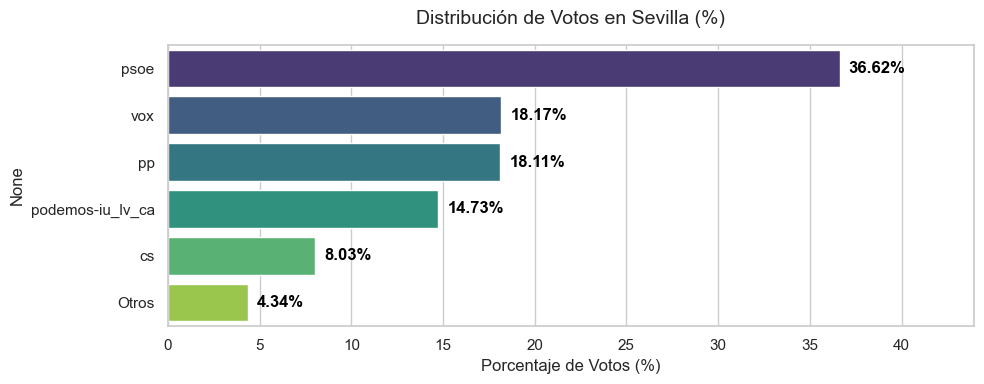

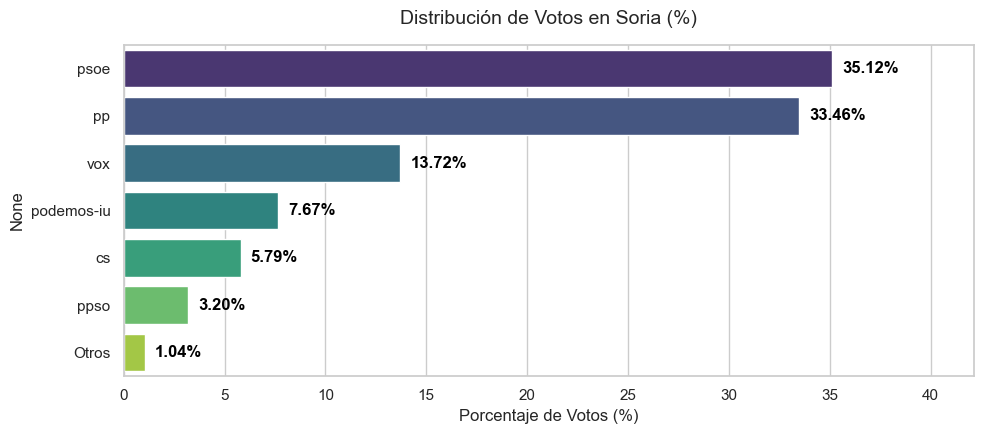

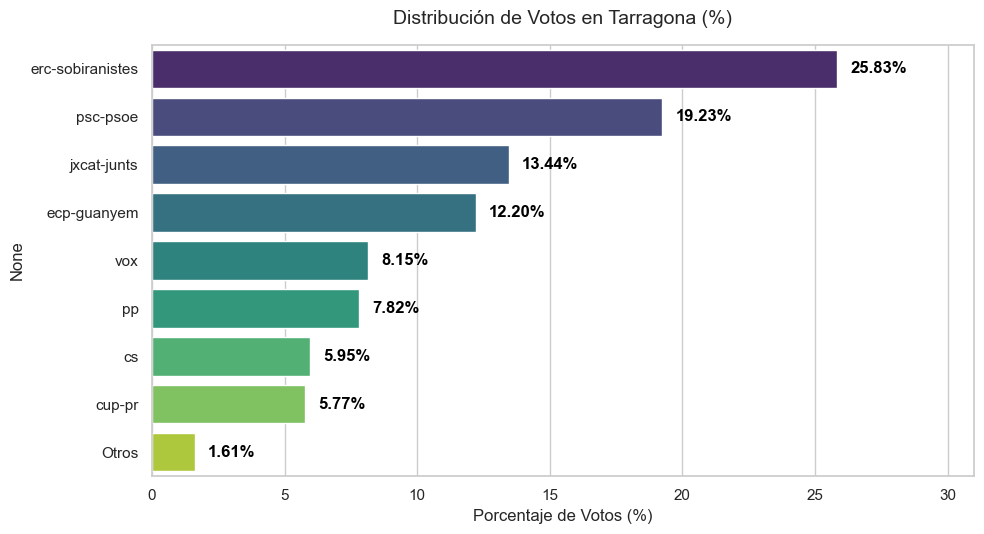

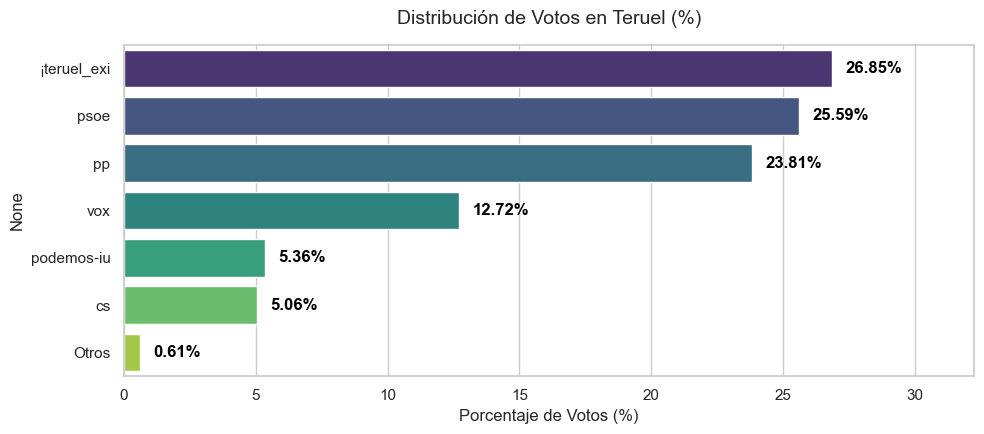

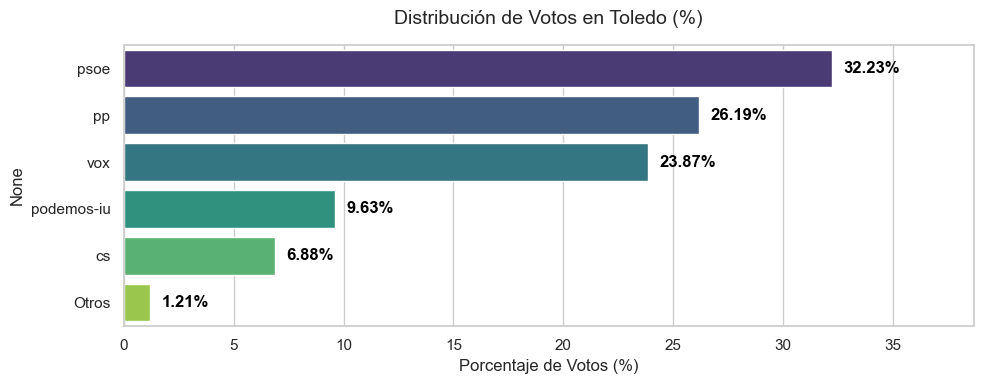

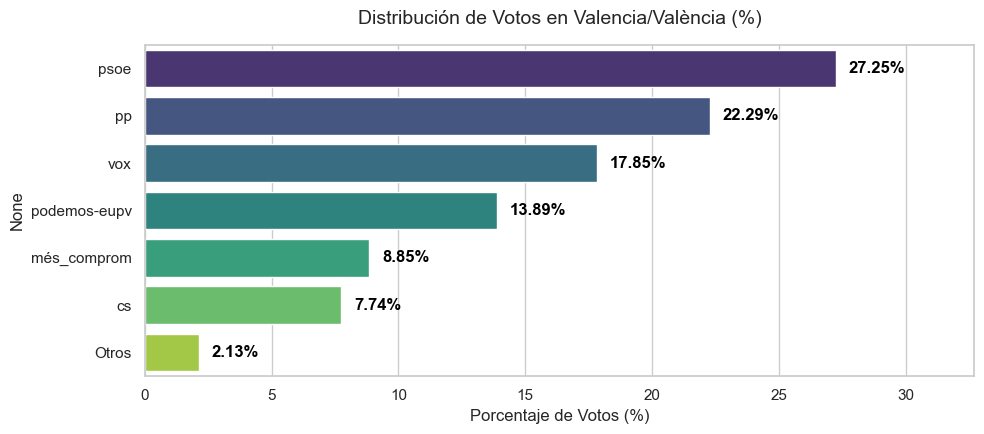

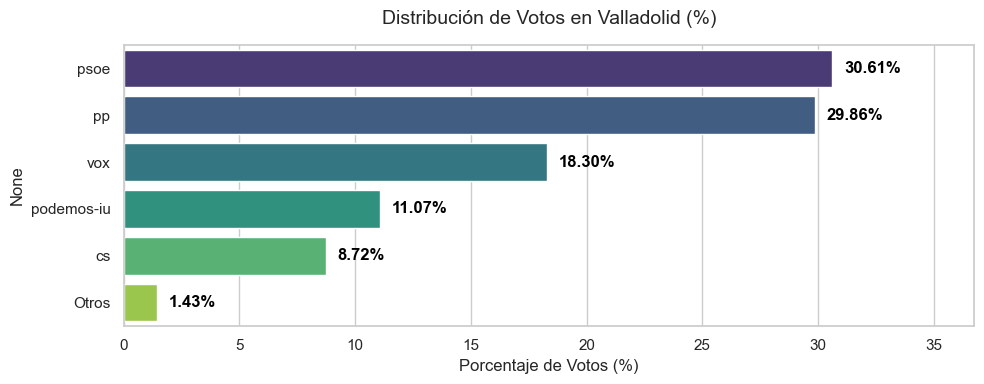

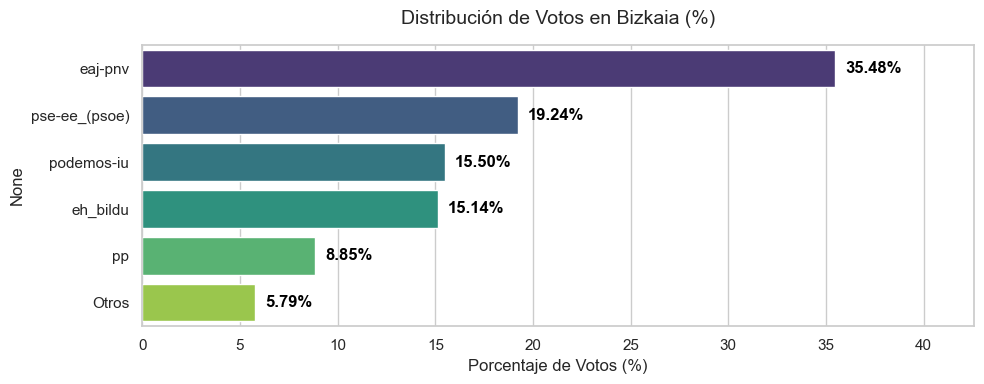

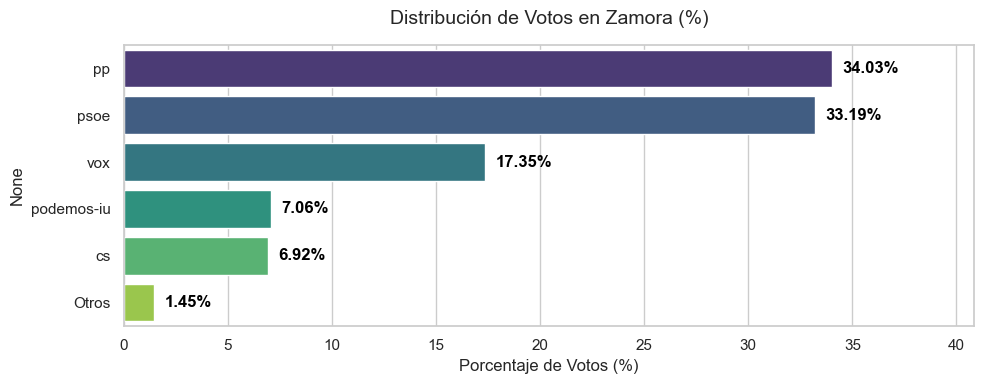

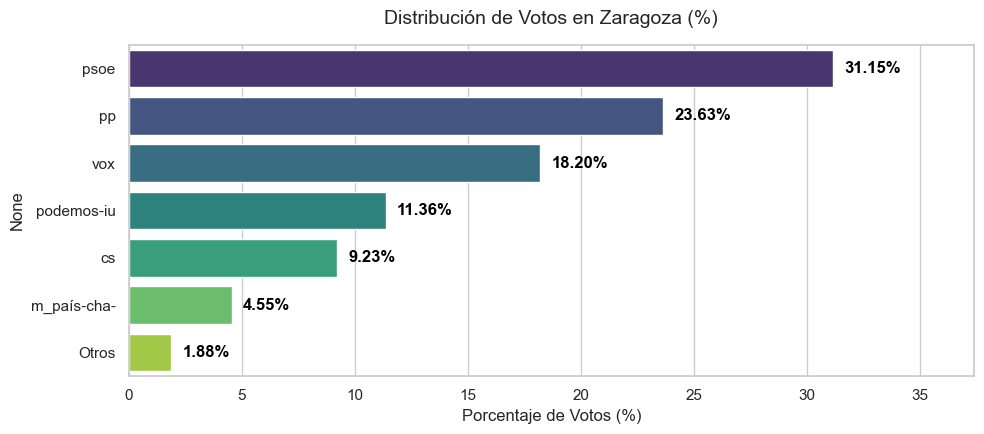

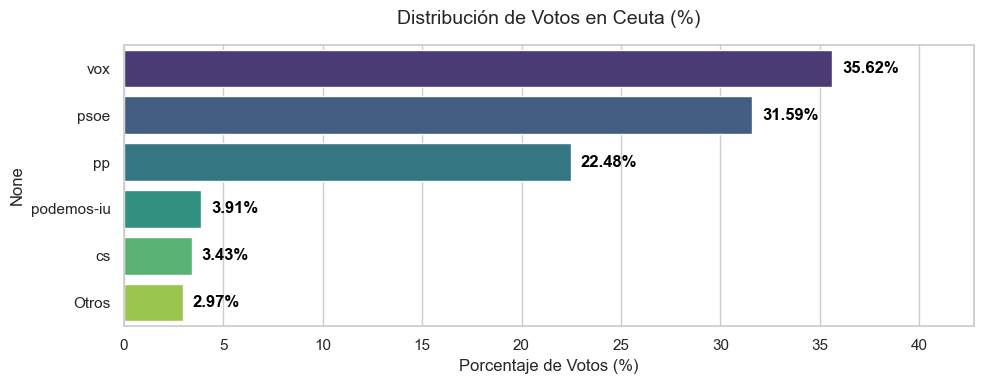

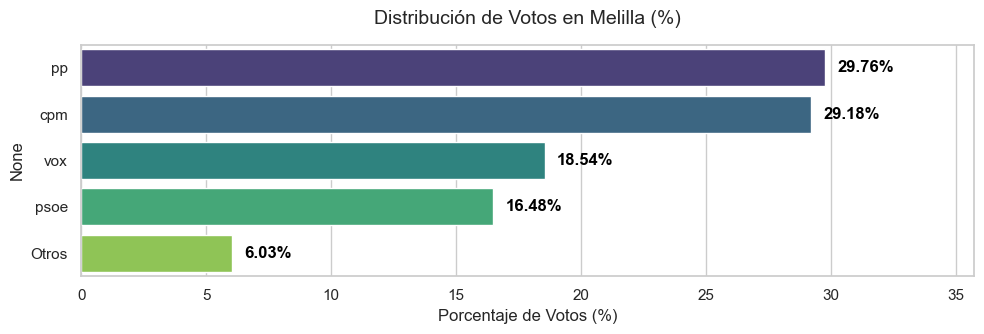

In [58]:
df_votos_provincial = eda_votos_granularidad_total(df_2019_Votos_Granularidad_Total_2019)

Iniciando EDA de Resultados Electorales (2019)
RESUMEN ESTADÍSTICO NACIONAL DE CANDIDATURAS
Total de candidaturas analizadas: 62

No hay partidos con 0 votos en el recuento.

TOP 5 - CANDIDATURAS MÁS VOTADAS:
 - psoe                      |  6,754,330 votos |  28.26%
 - pp                        |  5,022,200 votos |  21.02%
 - vox                       |  3,640,441 votos |  15.23%
 - podemos-iu                |  2,364,537 votos |   9.89%
 - cs                        |  1,637,341 votos |   6.85%

TOP 5 - CANDIDATURAS MENOS VOTADAS (con al menos 1 voto):
 - udt                       |         26 votos |  0.00011%
 - izar                      |        112 votos |  0.00047%
 - dpl                       |        210 votos |  0.00088%
 - risa                      |        229 votos |  0.00096%
 - centrados                 |        233 votos |  0.00098%


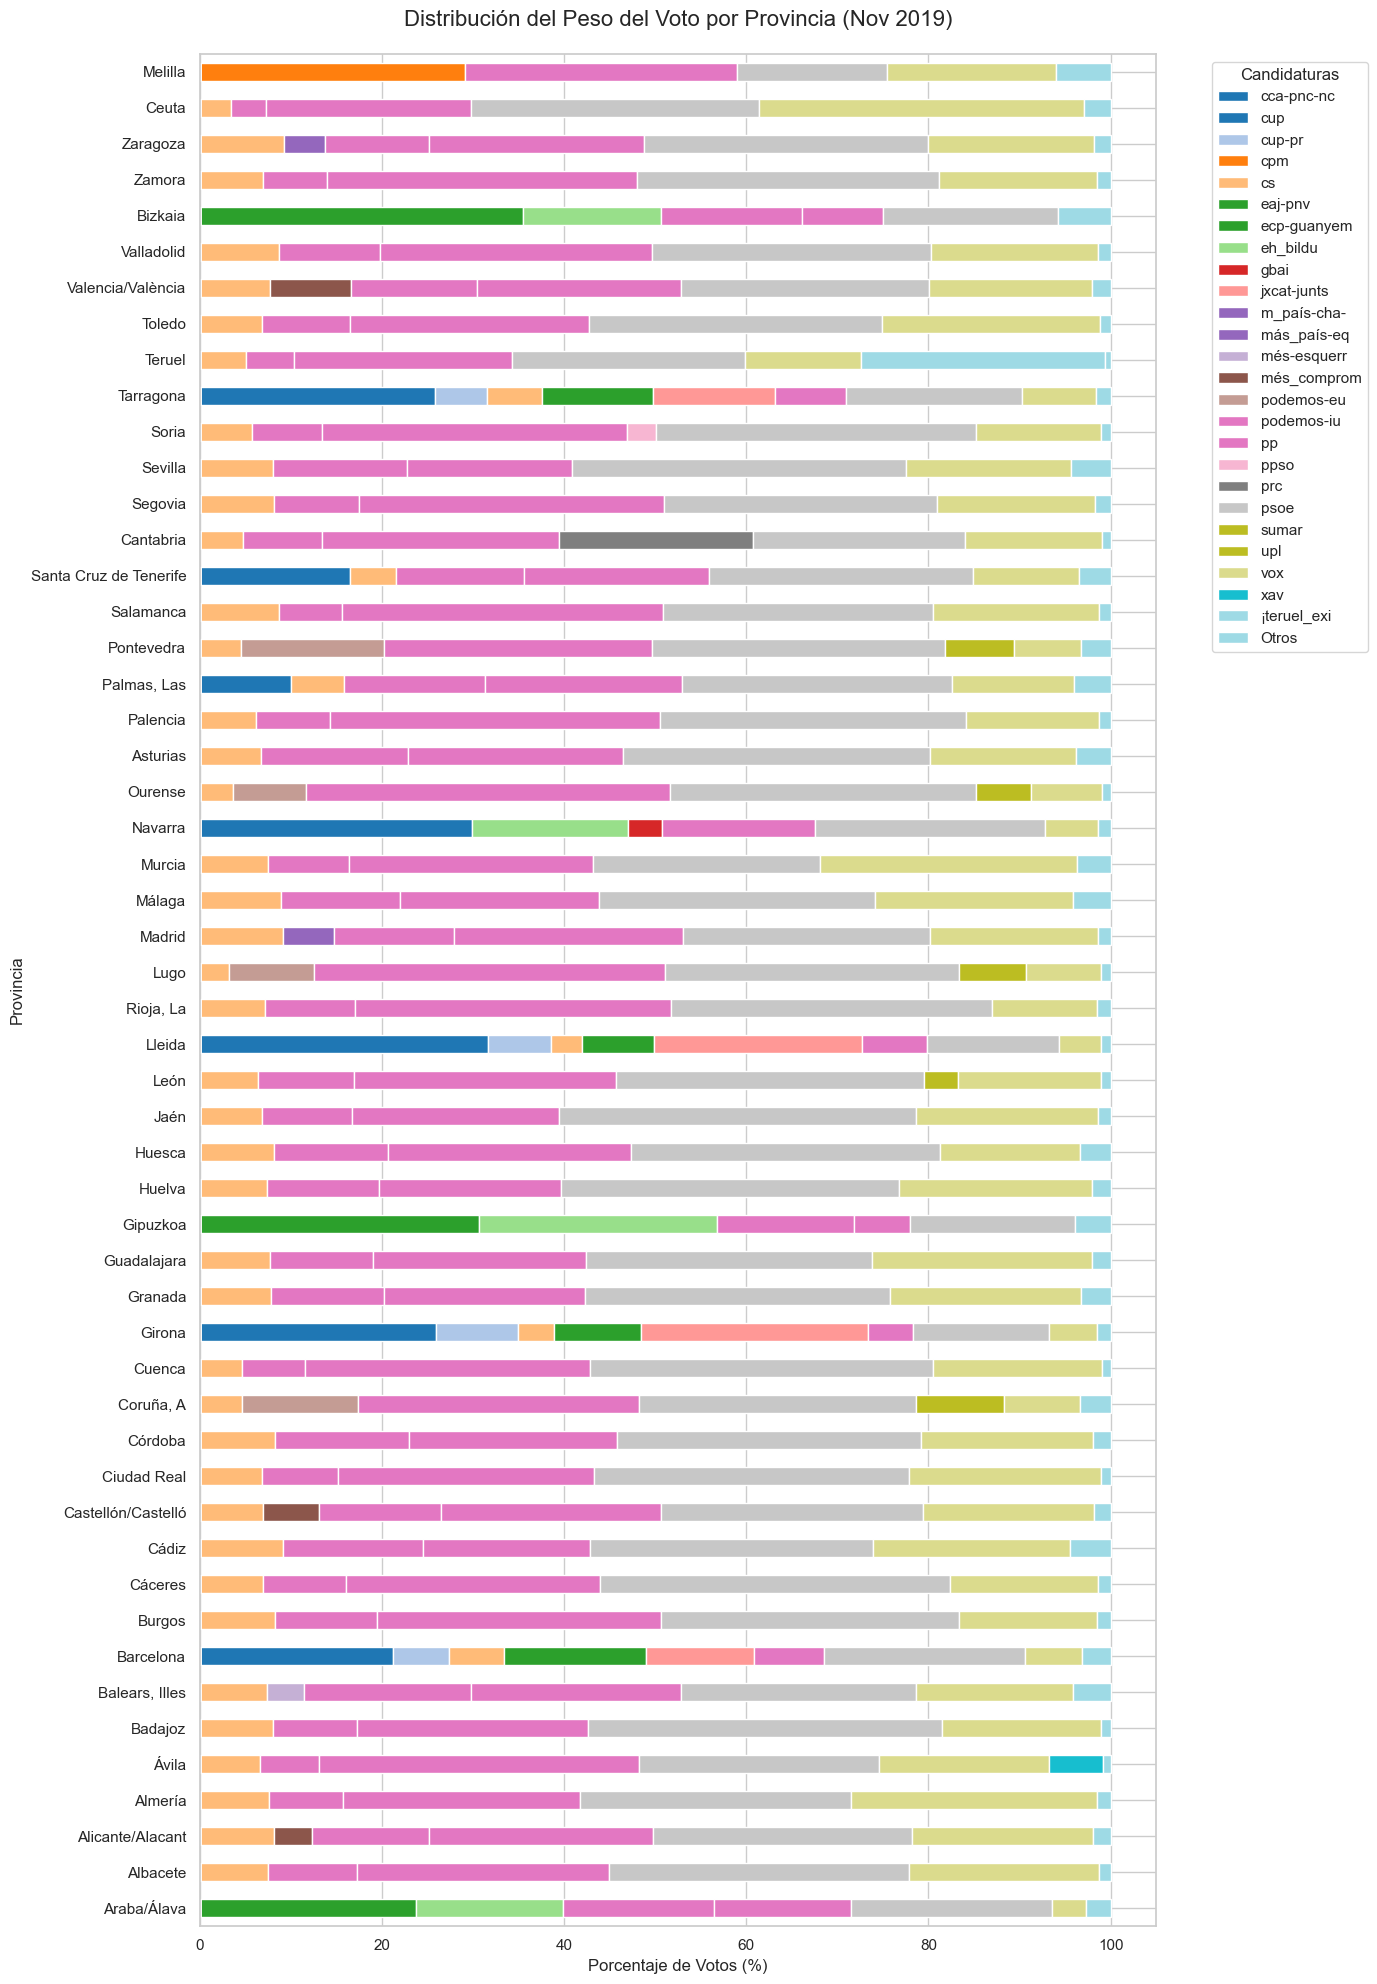


--- Generando Gráficos Individuales por Provincia ---


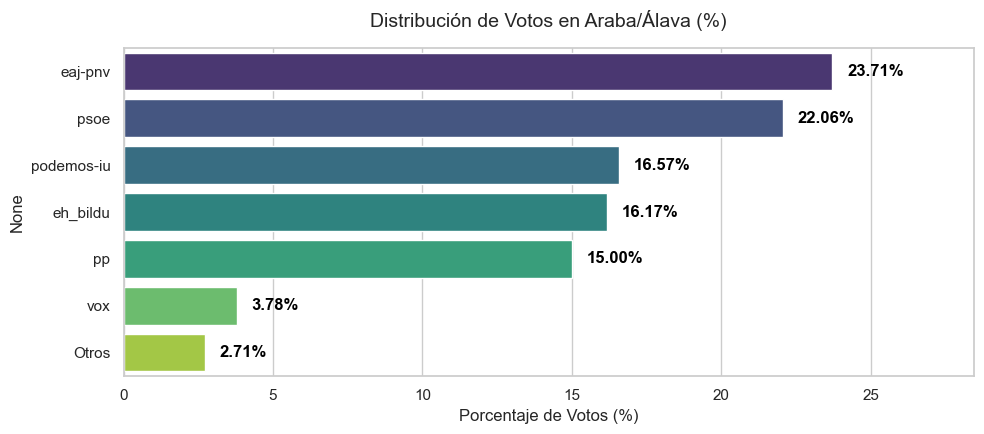

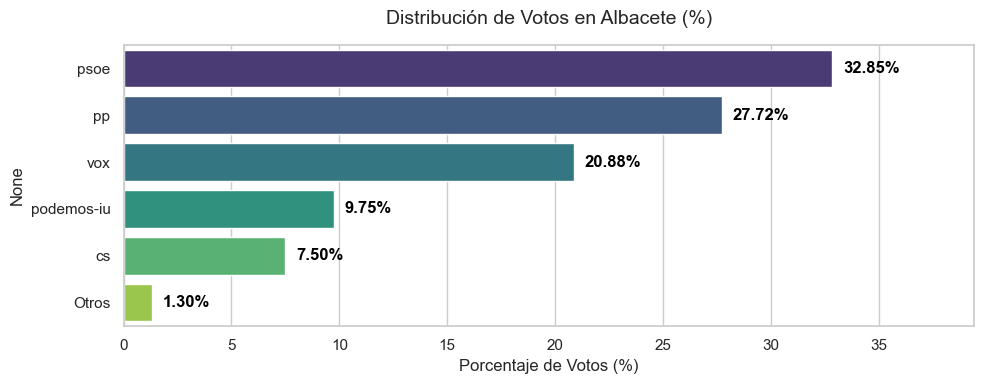

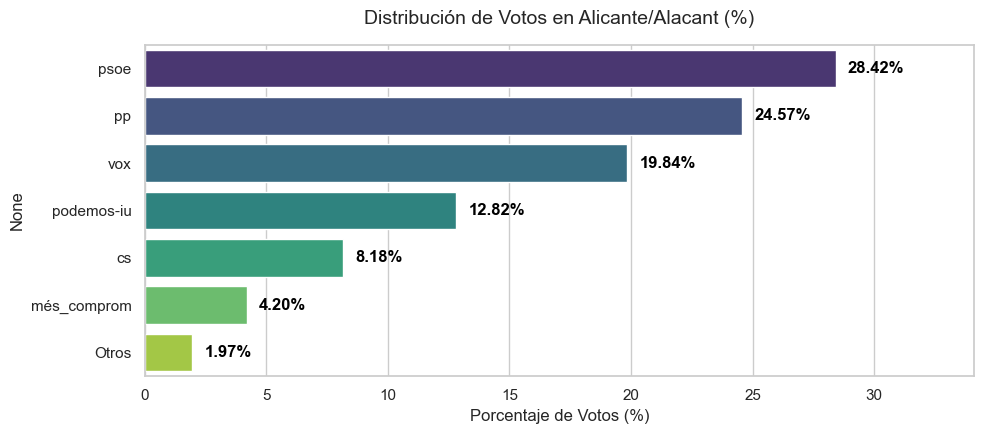

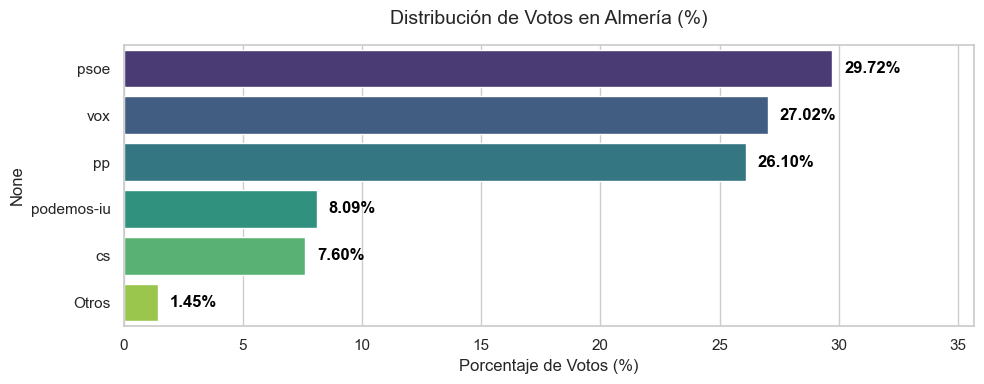

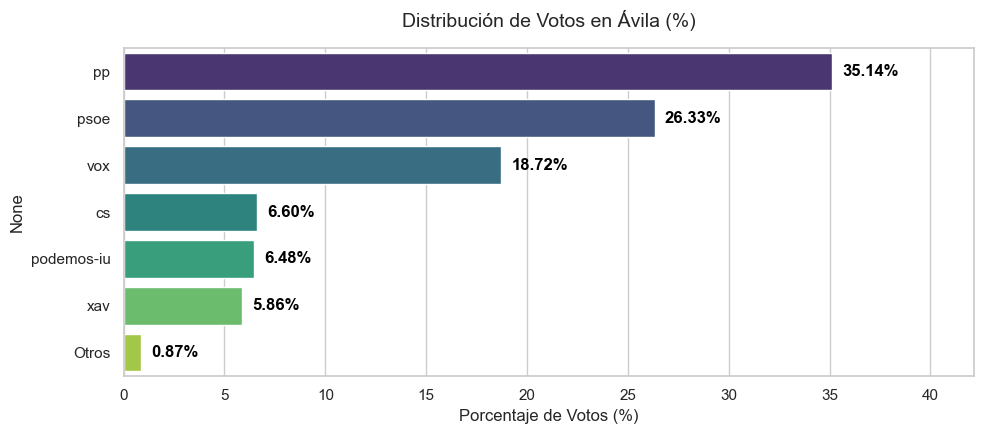

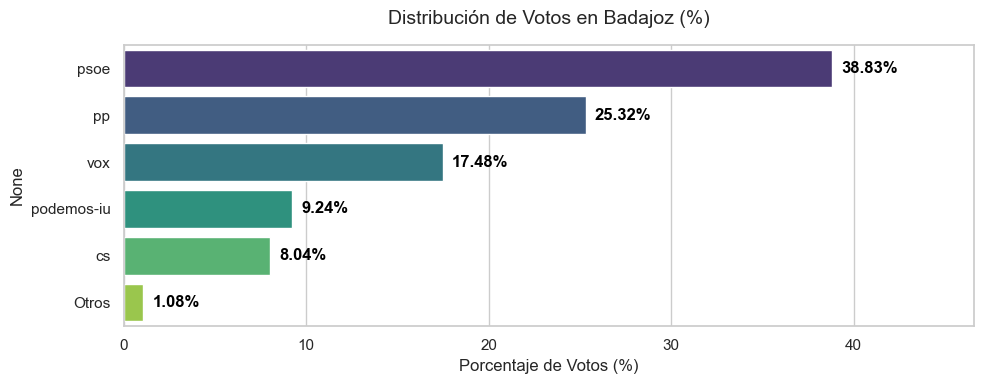

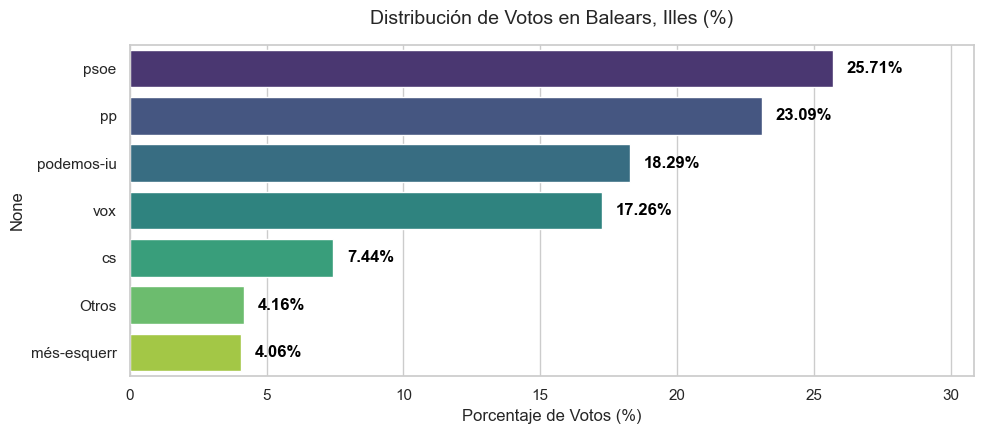

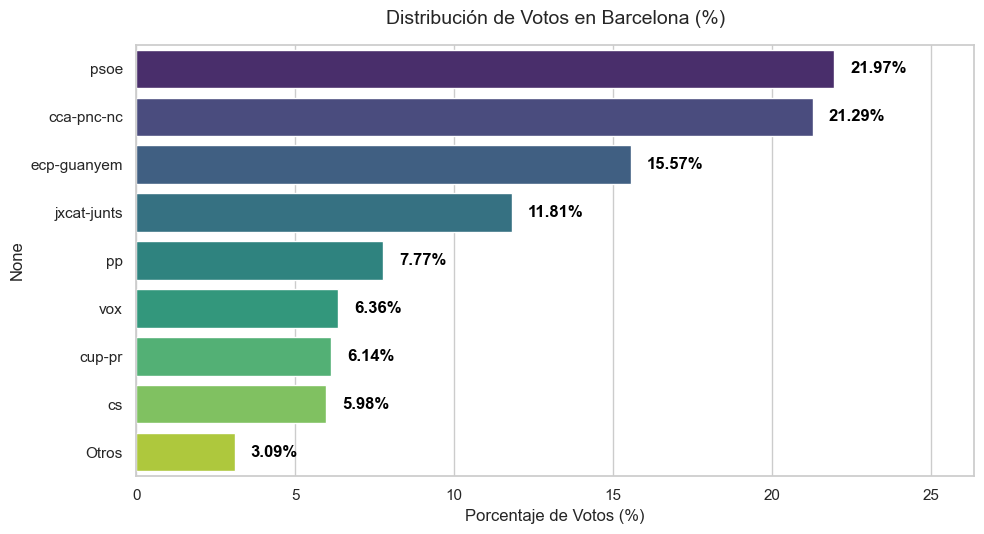

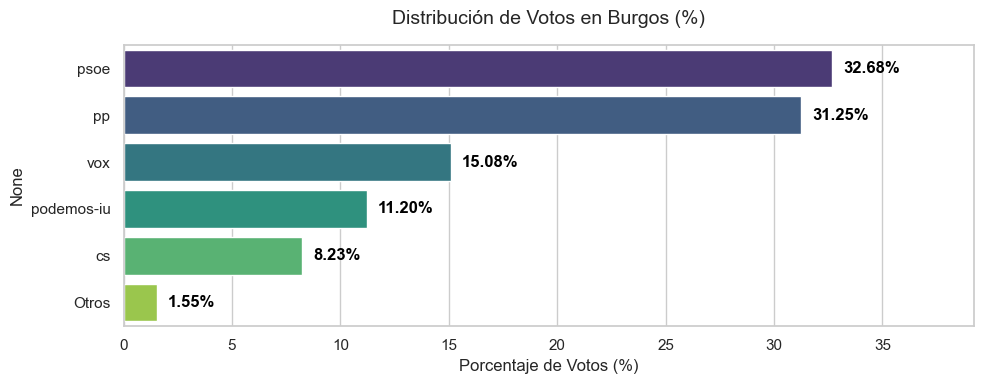

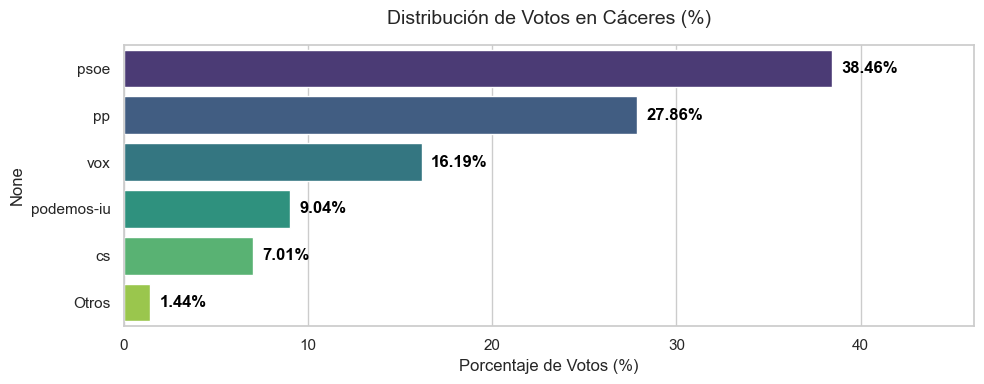

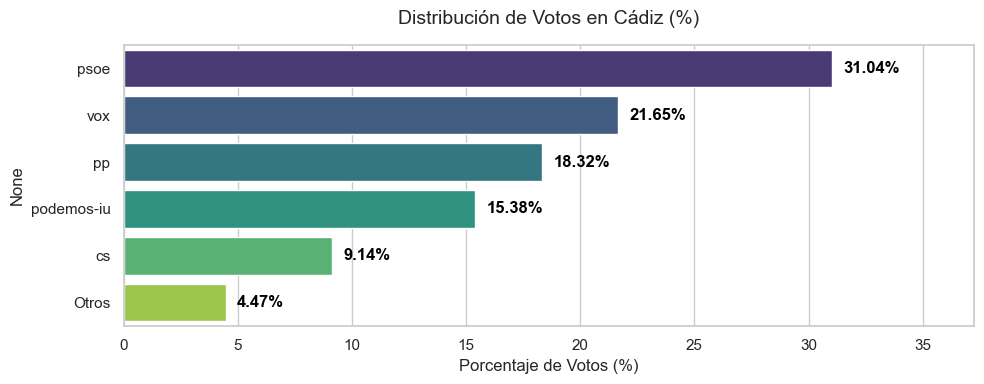

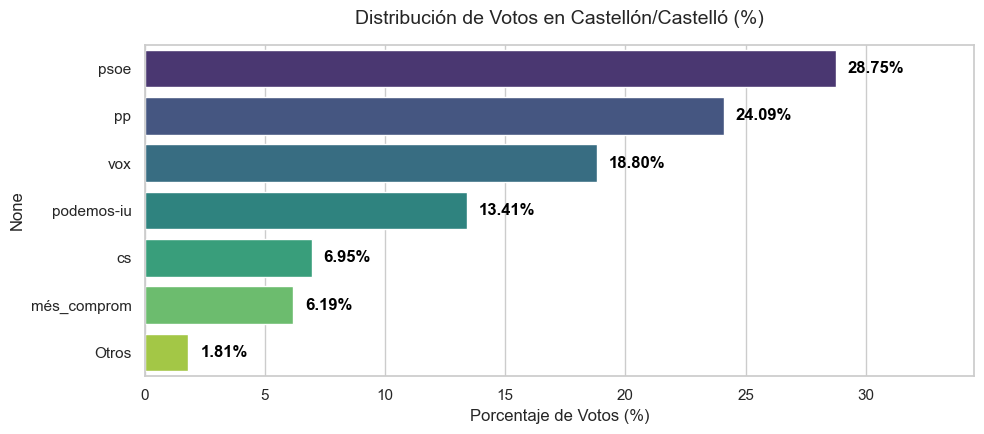

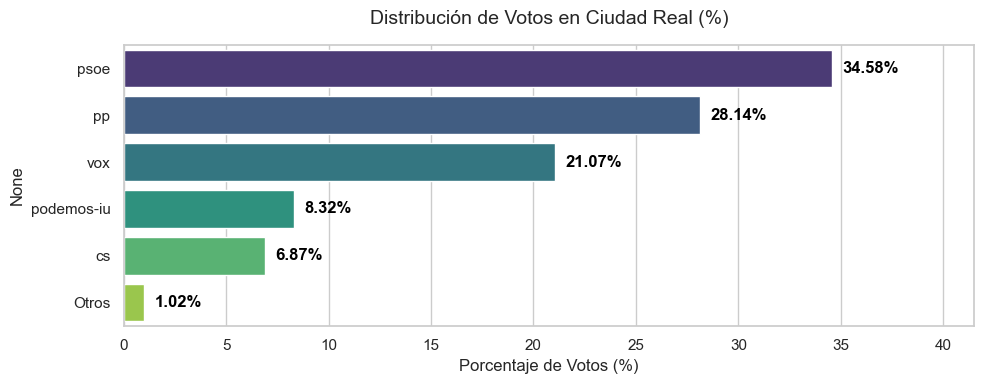

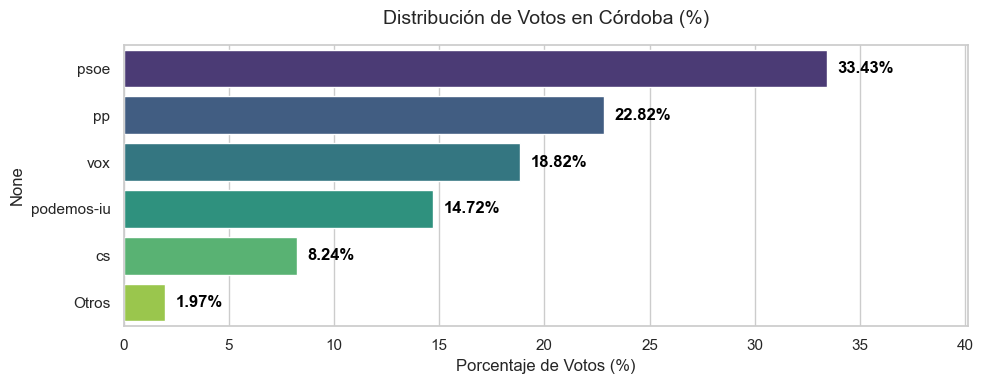

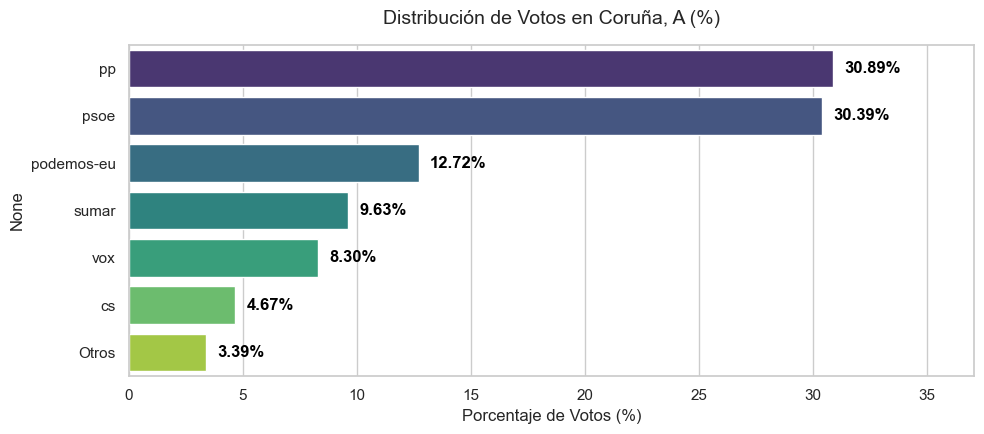

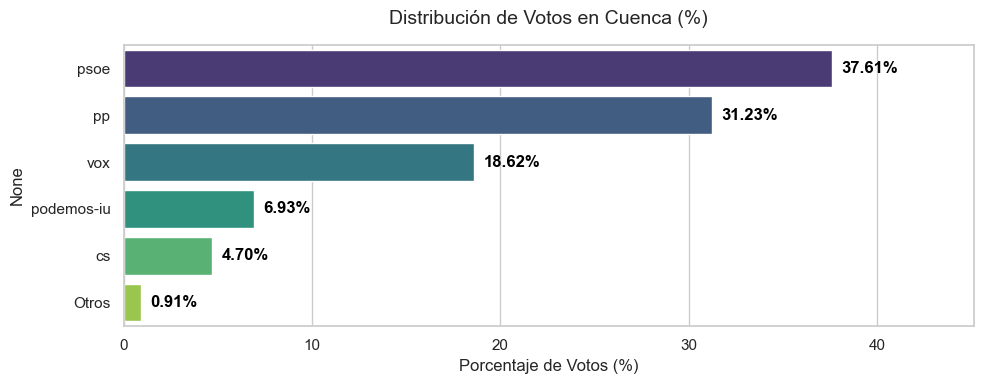

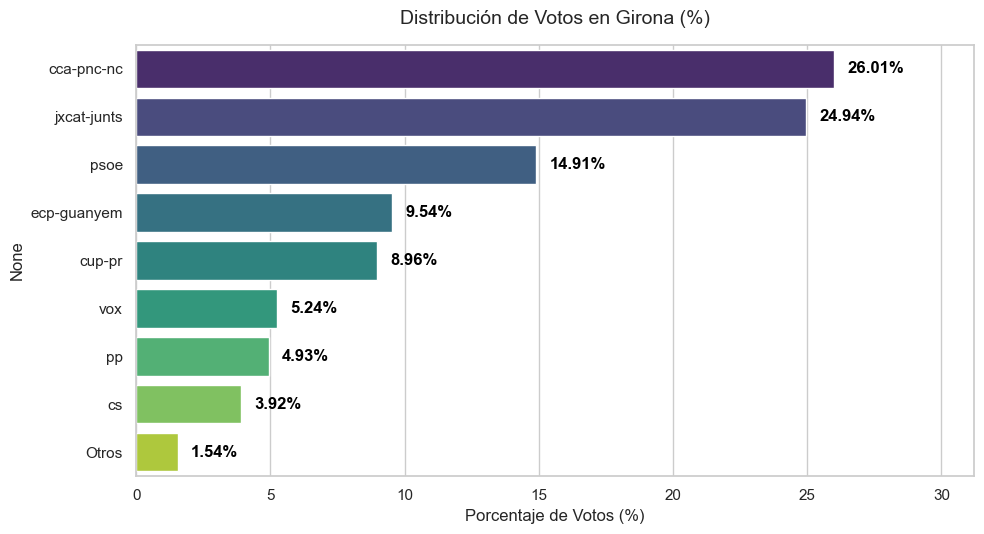

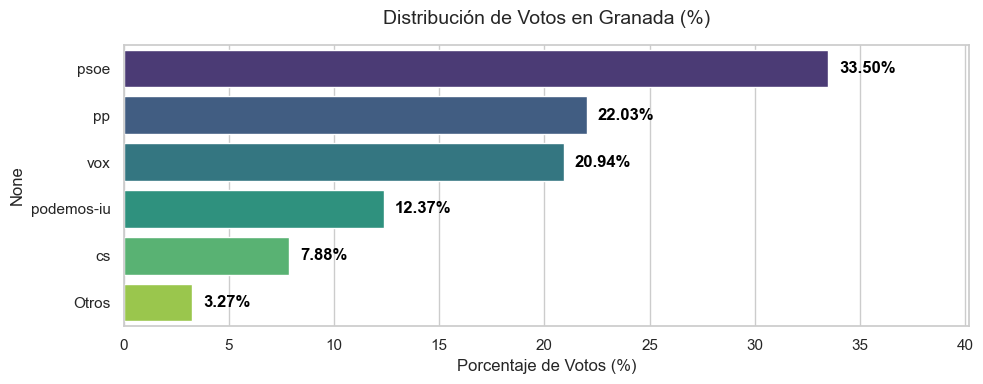

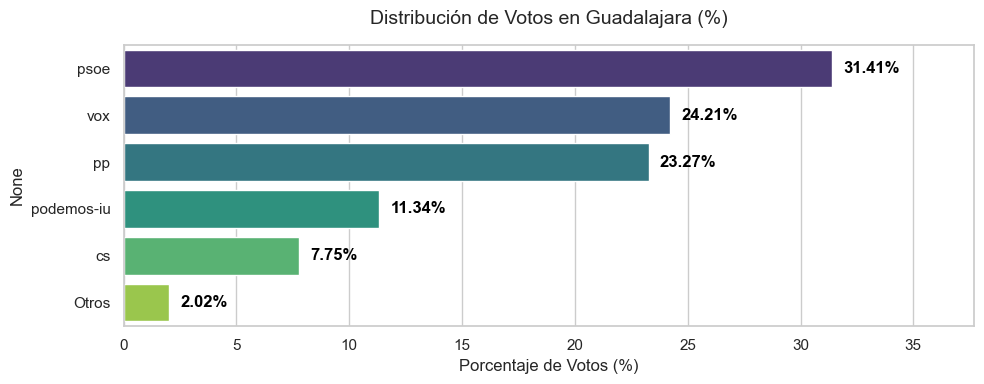

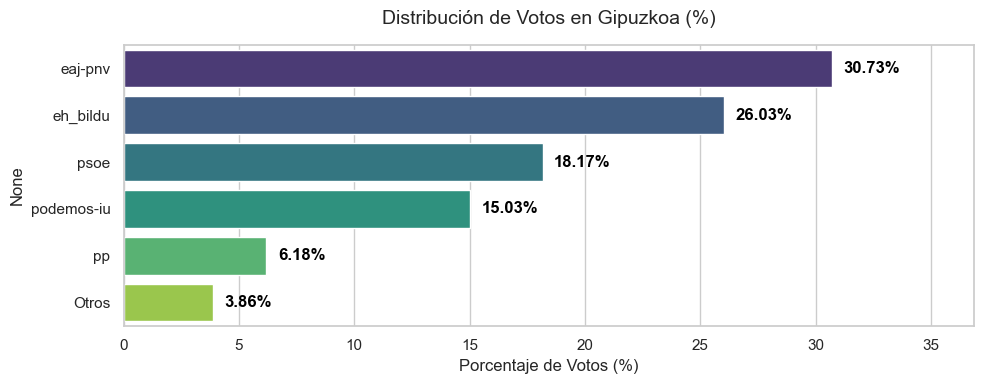

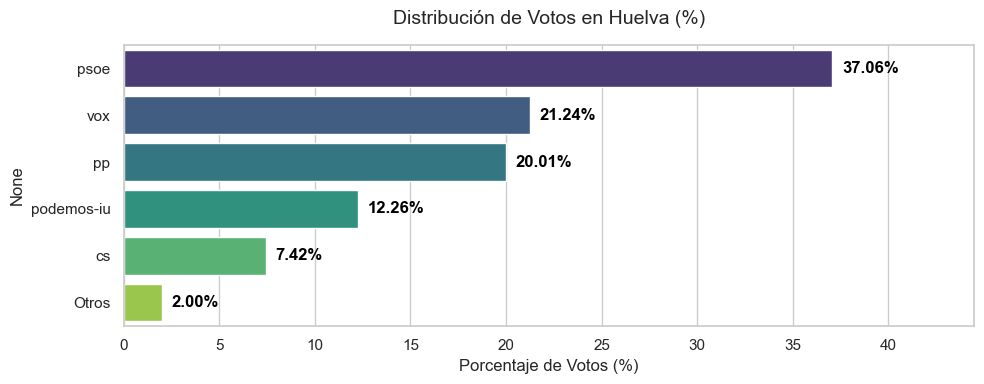

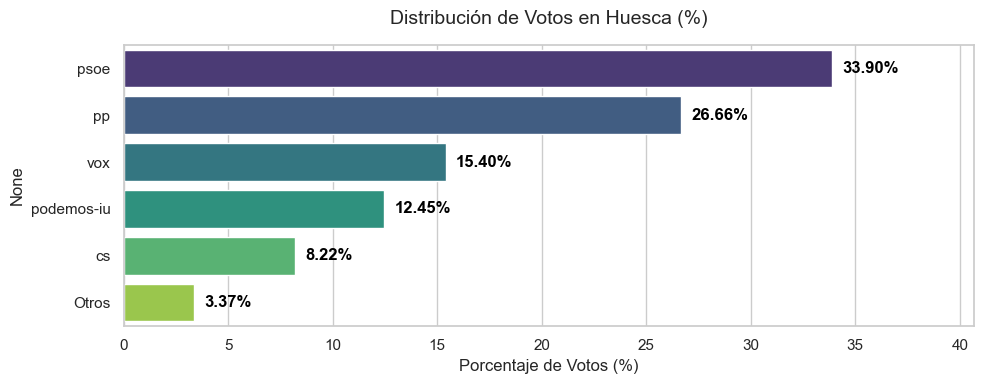

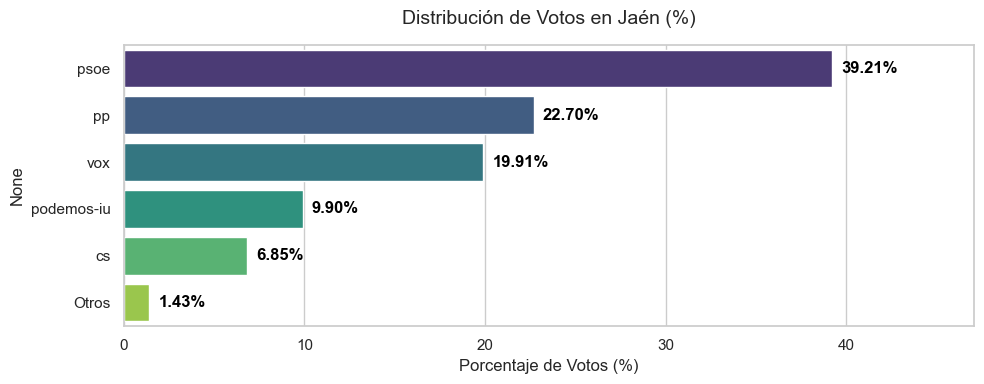

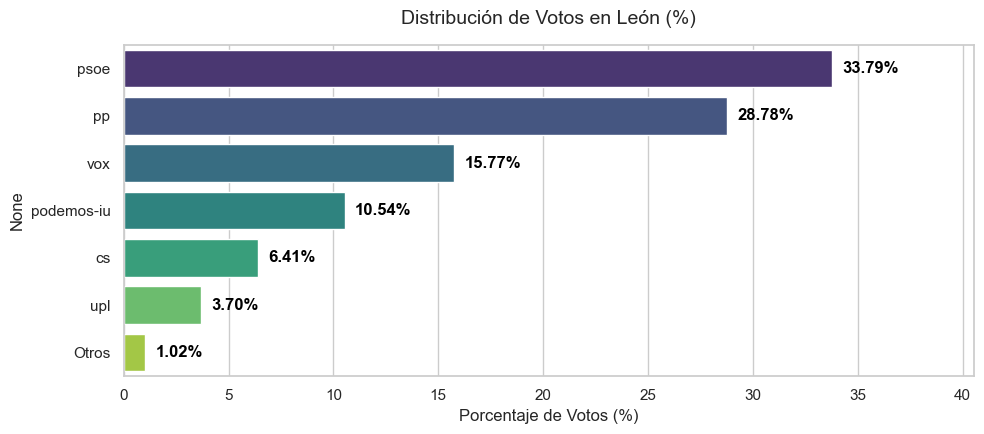

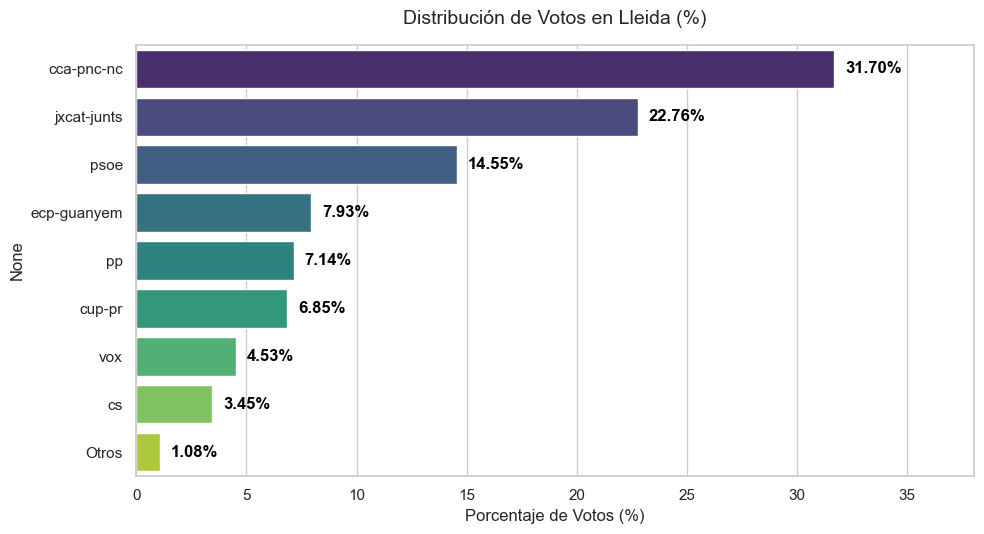

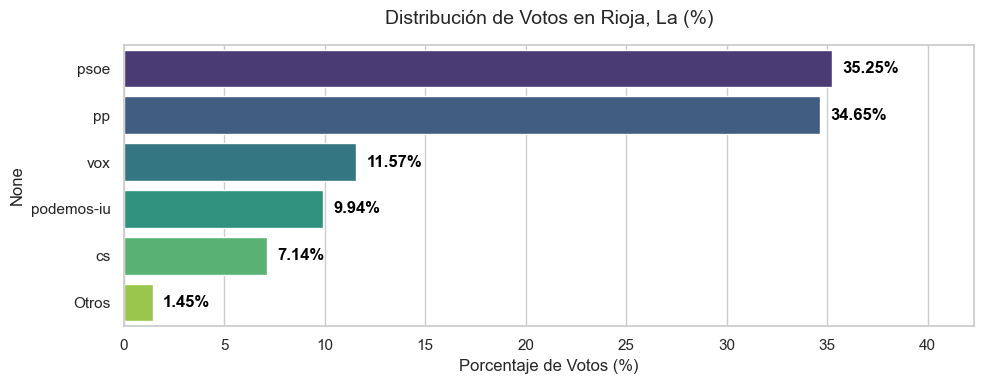

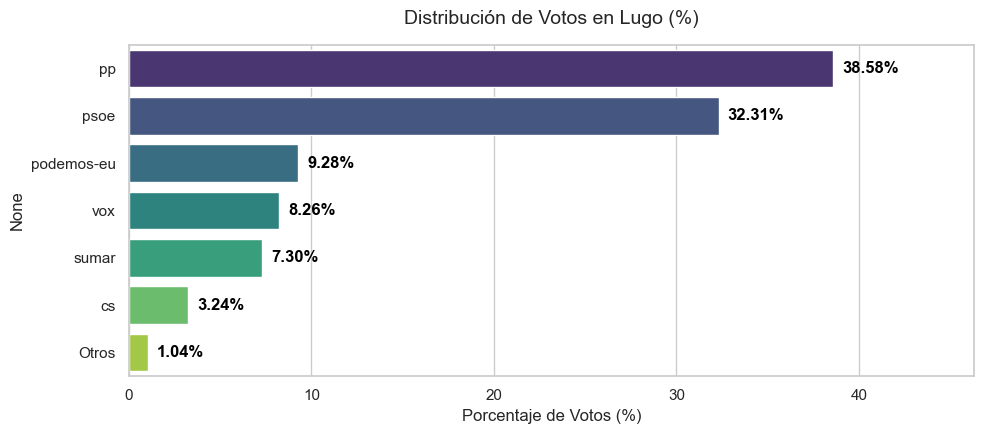

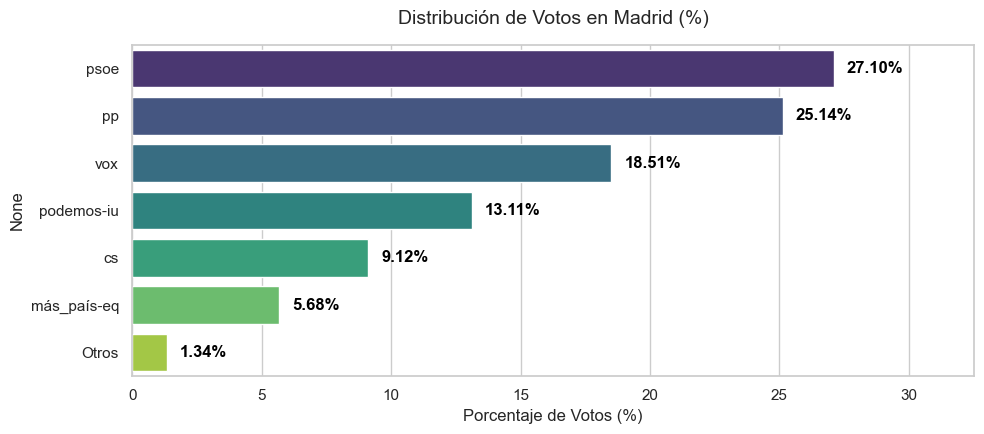

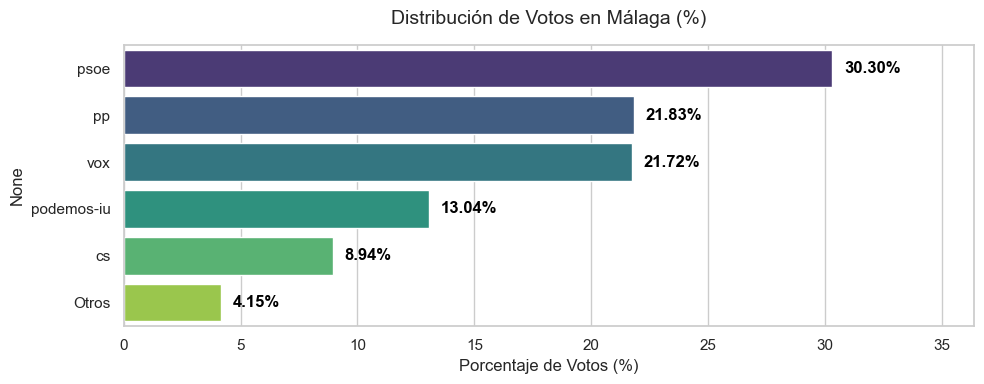

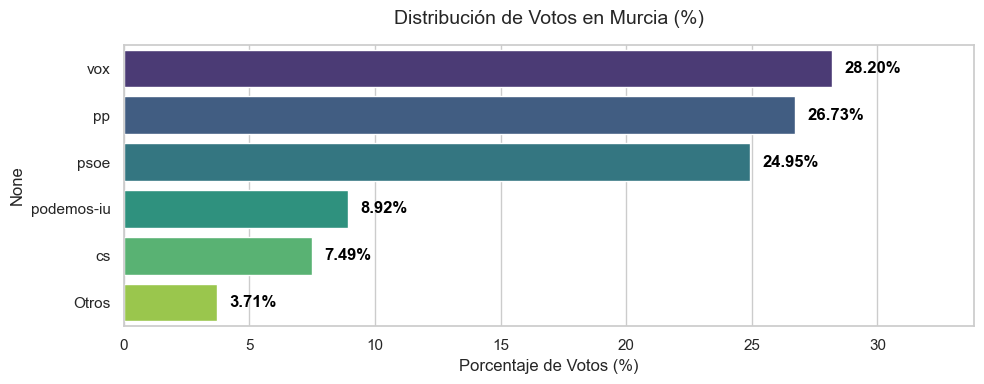

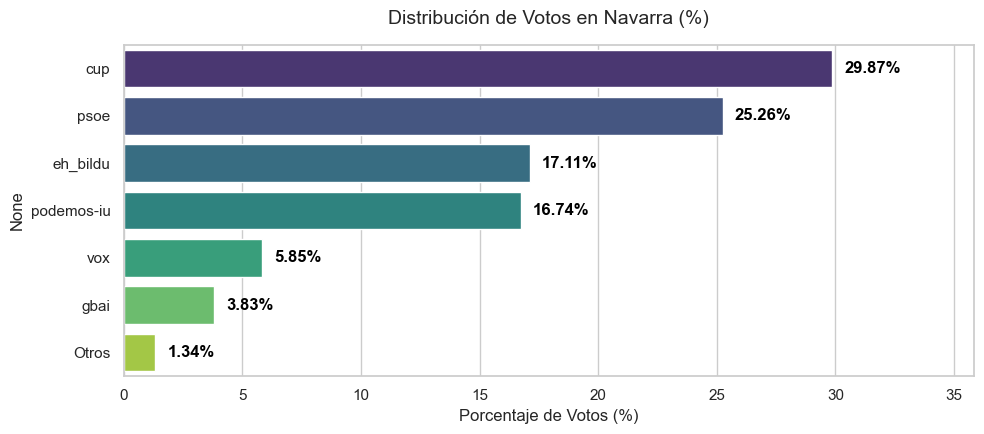

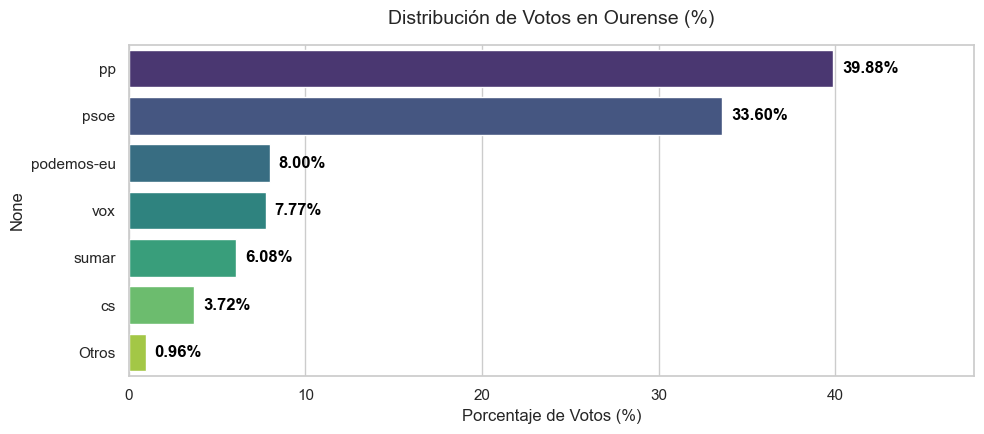

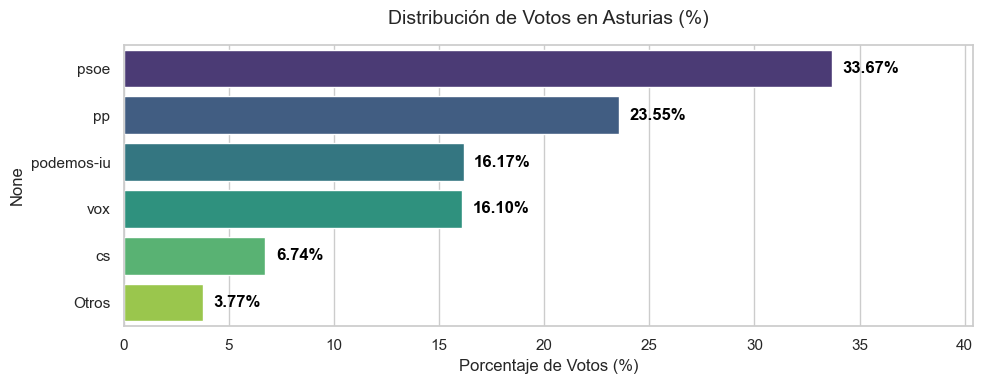

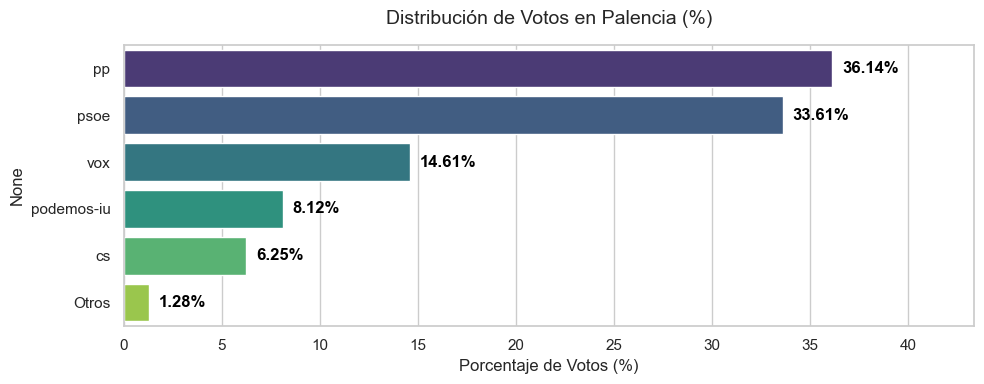

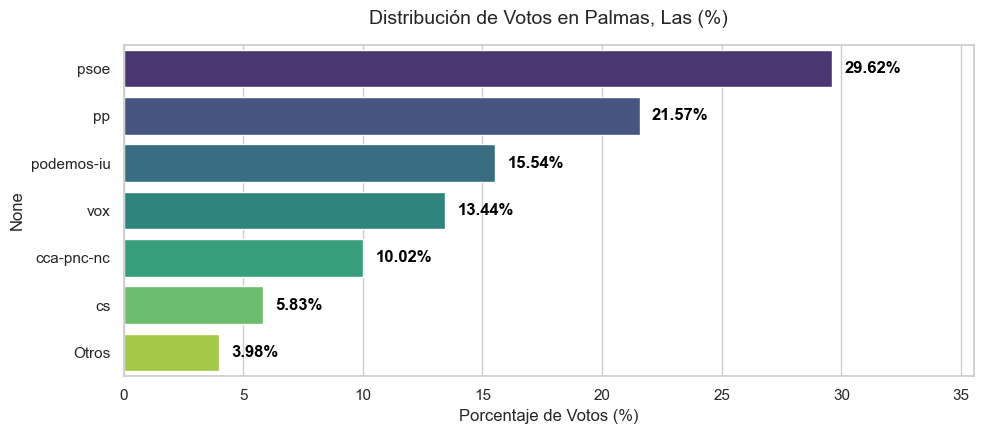

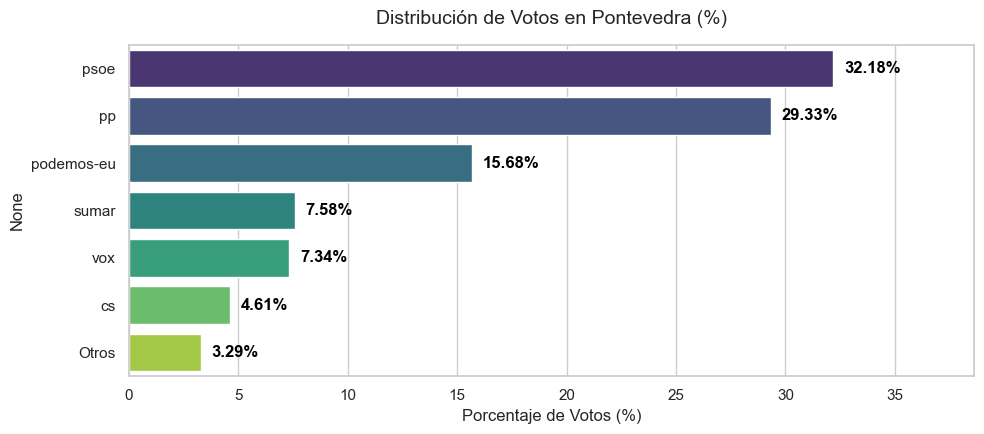

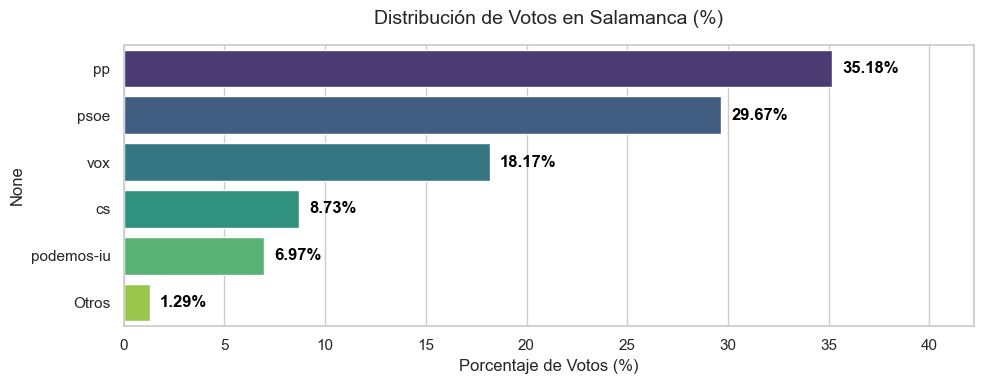

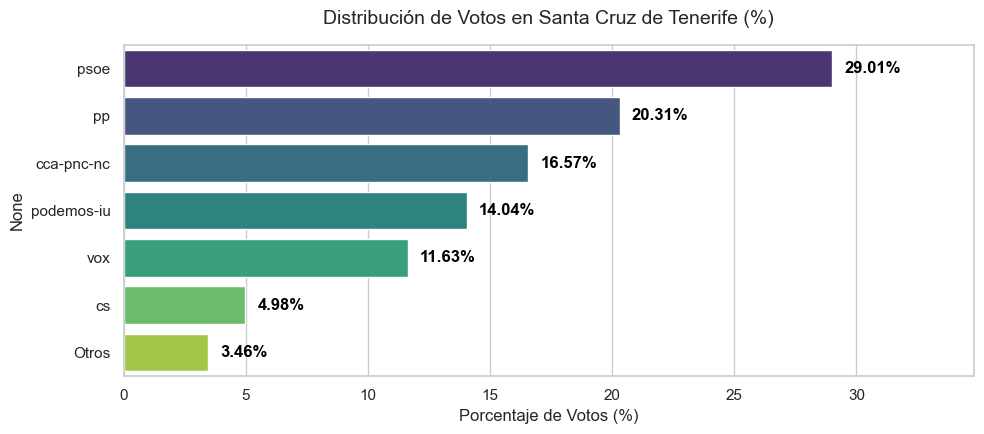

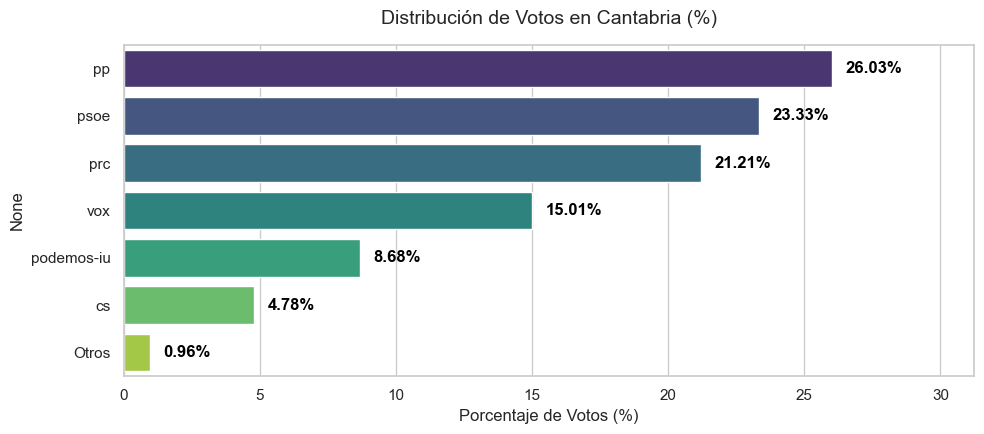

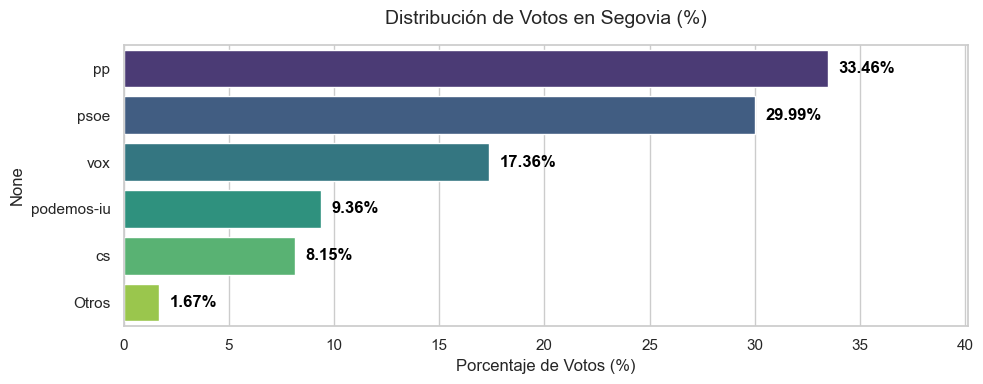

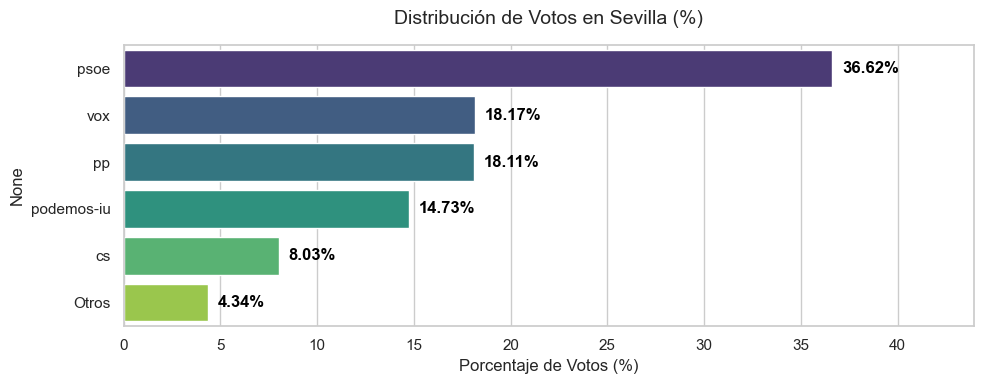

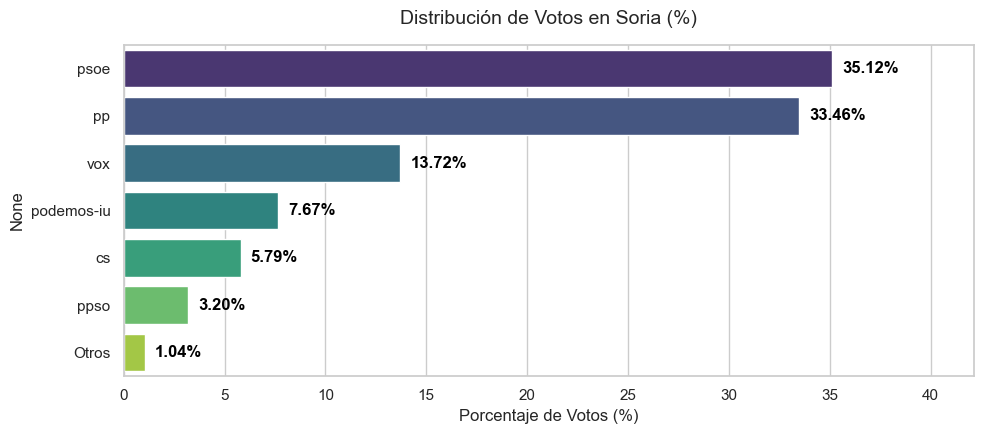

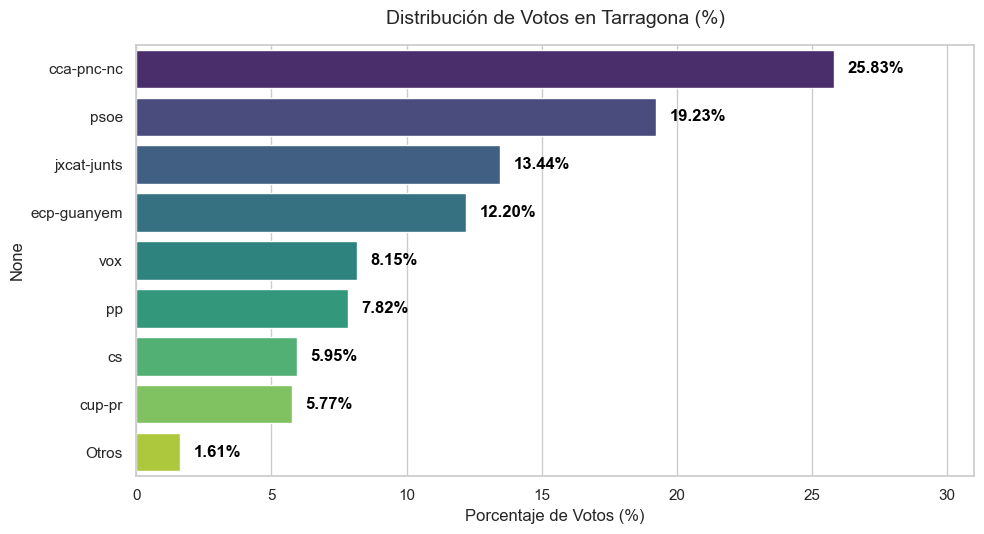

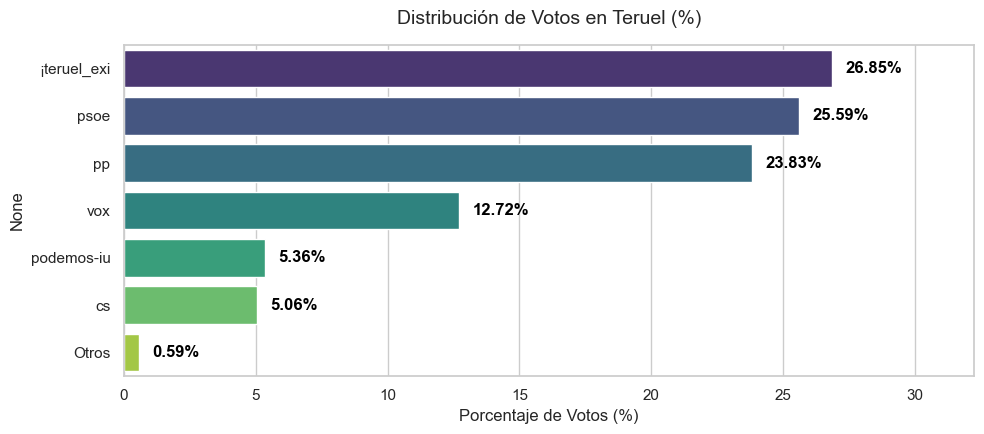

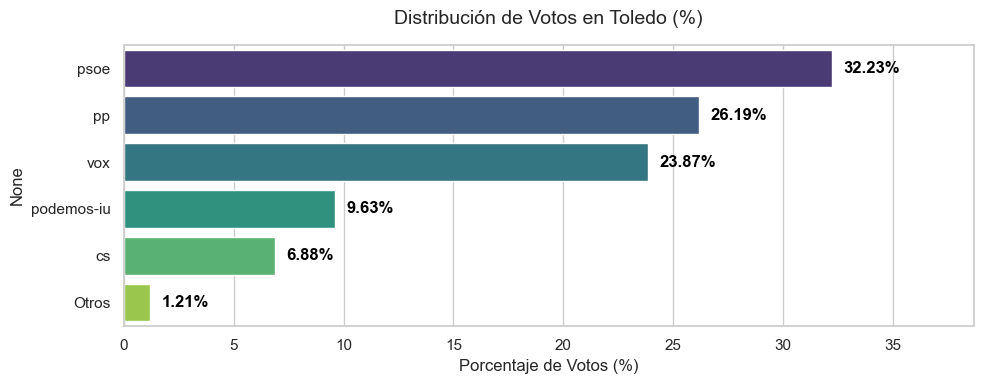

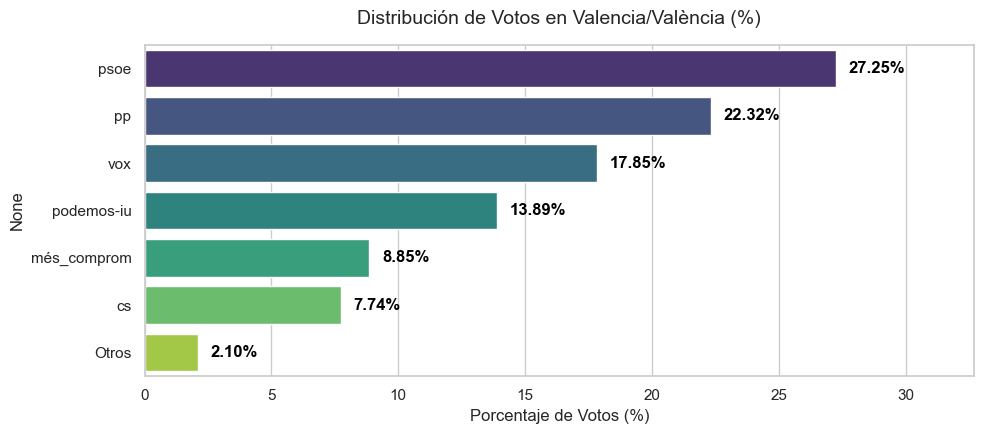

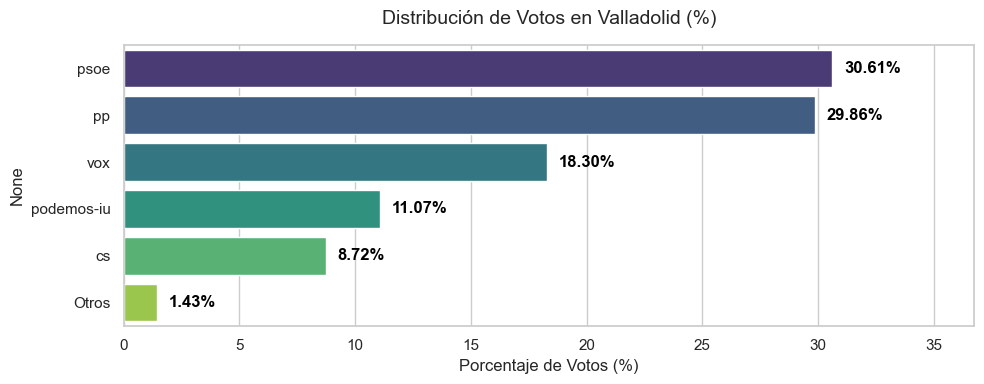

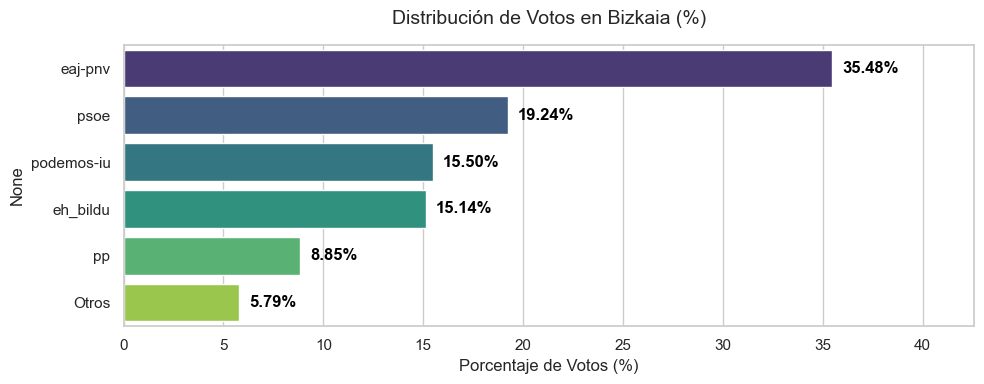

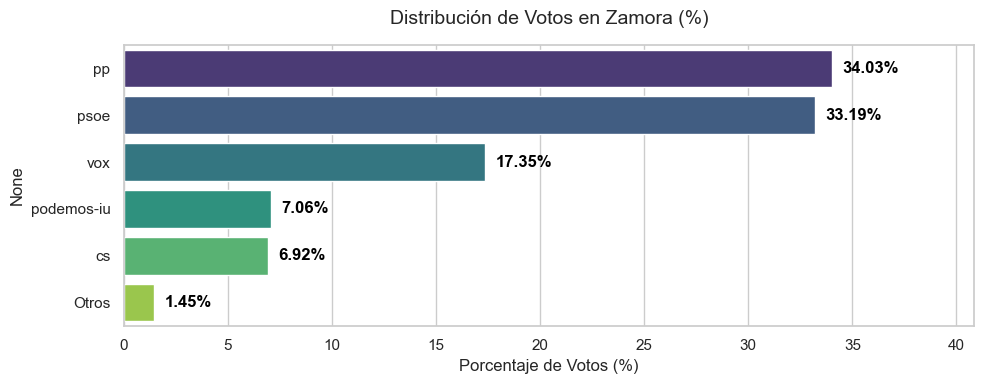

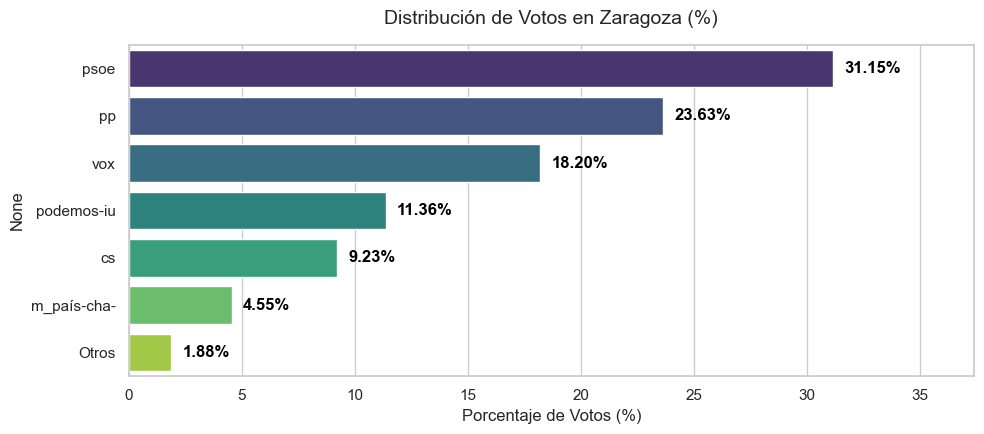

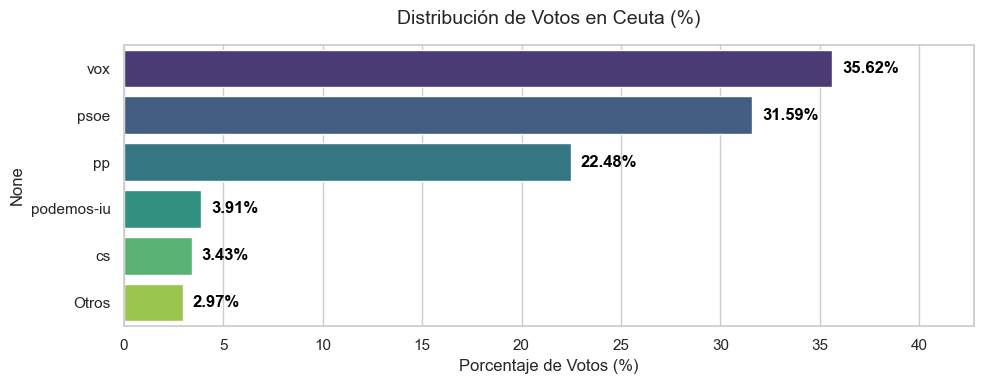

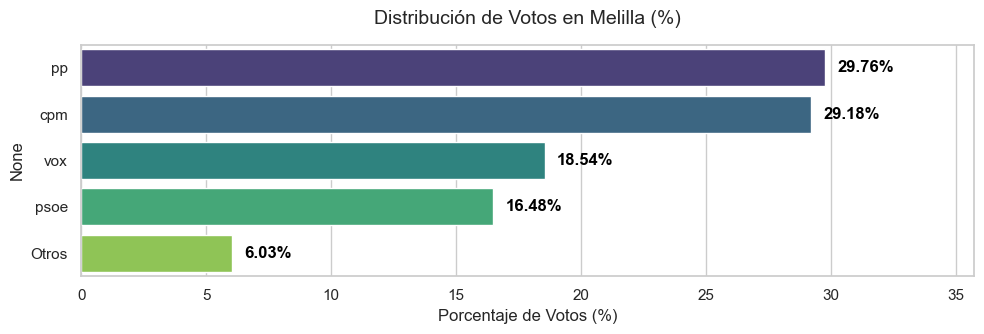

In [59]:
df_votos_provincial = eda_votos_granularidad_total(df_2019_Votos_Agrupados_Padres_2019) 

# tengo que sacar conclusiones DE ARRIBA 

In [60]:
analizar_umbral_votos_nacional(df_2019_Votos_Agrupados_Padres_2019)

ANÁLISIS DE RELEVANCIA PROVINCIAL (Umbral: 3.0%)
Provincia 01:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 02:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 03:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 04:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 05:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 06:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 07:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 08:  8 partidos superan umbral | 54 no lo alcanzan.
Provincia 09:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 10:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 11:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 12:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 13:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 14:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 15:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 16:  5 part

### 2.2. Estructura de slots de partido (target ML)

Partiendo del análisis anterior (25 candidaturas superan el umbral del 3% provincial), definimos los **slots de partido** que serán los targets del modelo de ML. 
La decisión sigue slots estables para estatales (resolviendo la consistencia 2019→2023 cuando Podemos se convierte en Sumar) más columna individual para cada regionalista con escaño propio (necesario para aplicar D'Hondt correctamente).

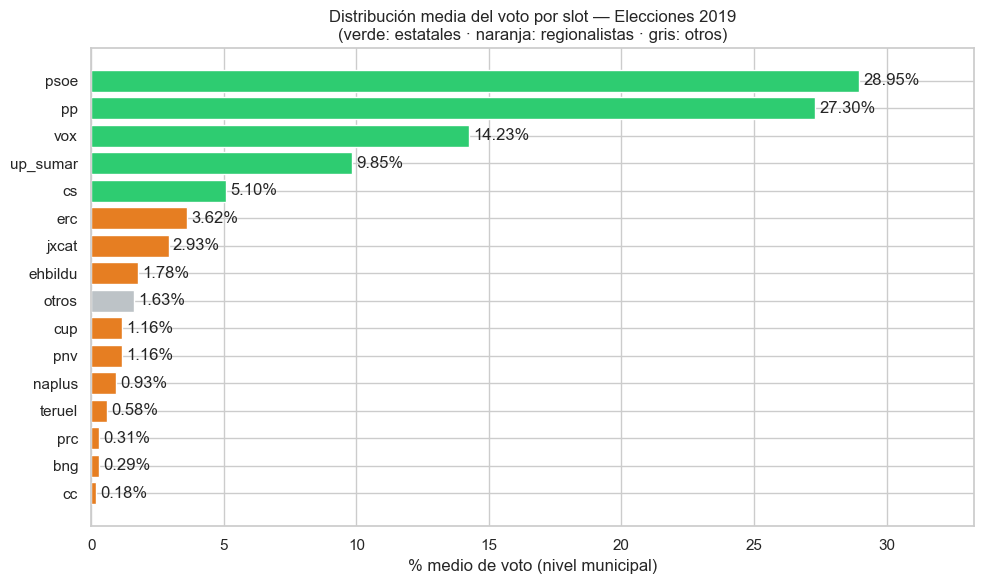

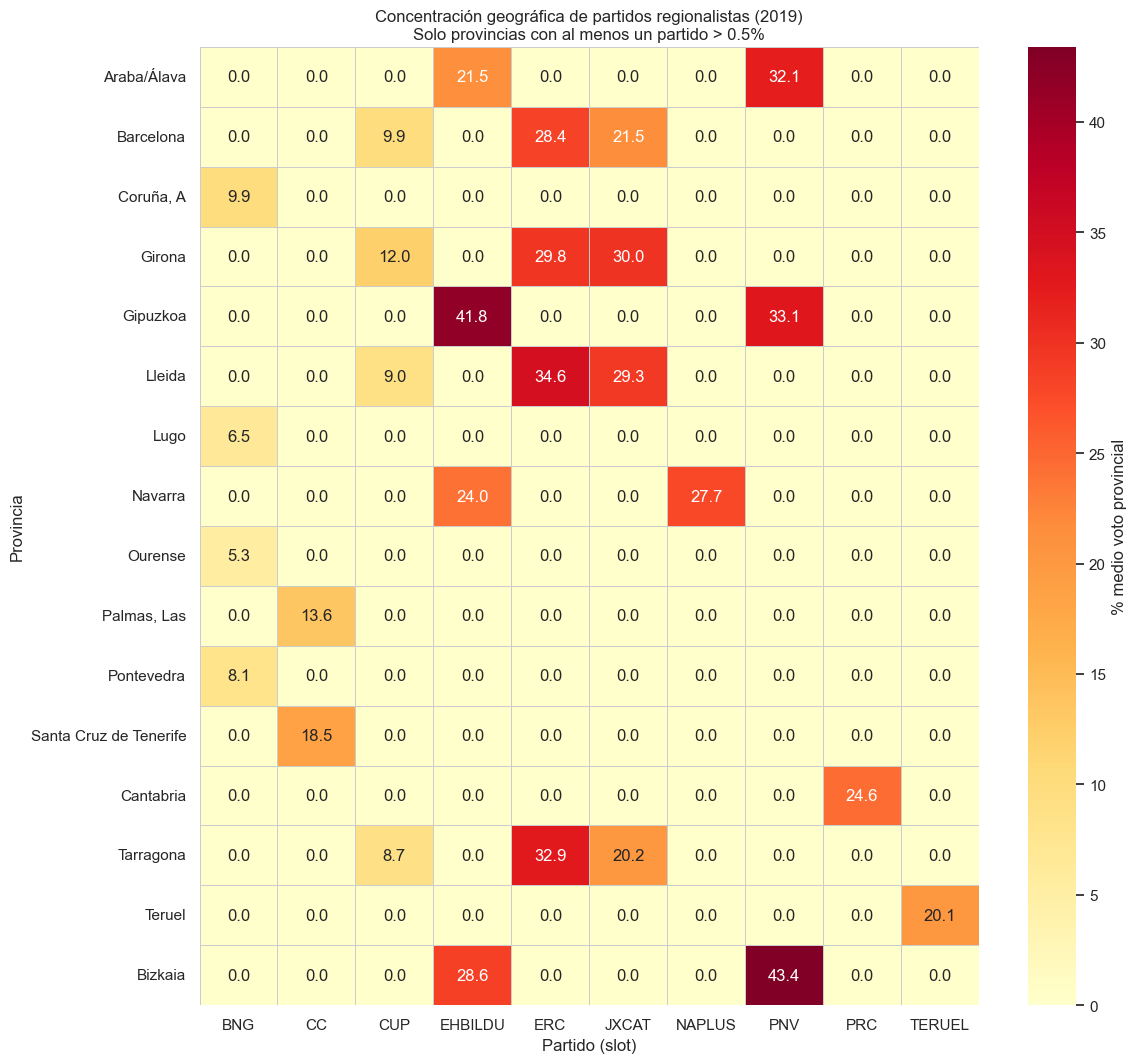

RESUMEN DE COBERTURA DE SLOTS — 2019
Slot                  Media      Max   Municipios>0
psoe                 28.95%   82.35%        8,083
pp                   27.30%  100.00%        7,790
vox                  14.23%   66.67%        7,874
up_sumar              9.85%   71.93%        7,745
cs                    5.10%   46.46%        7,339
erc                   3.62%   60.87%          947
jxcat                 2.93%   65.43%          947
ehbildu               1.78%   97.33%          519
otros                 1.63%   45.45%        6,416
cup                   1.16%   36.76%          942
pnv                   1.16%   63.39%          251
naplus                0.93%   81.82%          271
teruel                0.58%   60.00%          231
prc                   0.31%   43.51%          102
bng                   0.29%   31.57%          313
cc                    0.18%   38.85%           88

pct_otros cubre el 1.63% del voto de media.
Municipios con pct_otros > 5%: 455 de 8131


In [61]:
eda_slots_pct_votos(df_2019_votos_pct, anyo="2019")

Podemos ver que, de las 62 candidaturas principales, es decir, aquellas que agrupan varias a nivel nacional o son unicas, solo 25 obtienen más del 3% de los votos en las provincias donde se presentan. Esto permite que su candidatura no sea descartada por el umbral marcado por la ley y tras agruparlos en slots que nos permitiran aplicar el modelo a diferentes años.

Tras analizar los datos por separado, utilizamos la función unificar_datos_eda("año"). Esta permite generar un archivo CSV y un DataFrame con información general, lo que facilitará el cruce de variables con los datasets de votos. De este modo, podremos analizar cómo ciertos factores influyen en los resultados, realizar correlaciones y completar las etapas finales del EDA.

In [62]:
#df_2019_datos_unificados = unificar_datos_eda(2019)

In [63]:
df_2019_datos_unificados.isna().sum()

municipio                        0
nombre                           0
provincia                        0
superficie                       0
latitud                          0
longitud                         0
altitud                          0
rango tamaño población           0
poblacion                        0
poblacion hombres                0
poblacion mujeres                0
densidad poblacional             0
indice gini                   1413
P80P20                        1685
Renta media hogar             1363
renta media unidad consumo    1413
renta media persona           1363
salarios                      1624
pensiones                     1824
otros ingresos                1624
otras prestaciones            1824
desempleo                     1824
edad media                    7981
votos totales                    0
votos blancos                    0
participacion                    0
pct_psoe                         0
pct_pp                           0
pct_vox             

Ahora que tenemos el fichero unificado podemos mirar dos puntos claves de las votaciones, por lo tanto miraremos el porcentaje de participación general y según el rango de territorio.


--- Análisis de Participación y Votos en Blanco (2019) ---


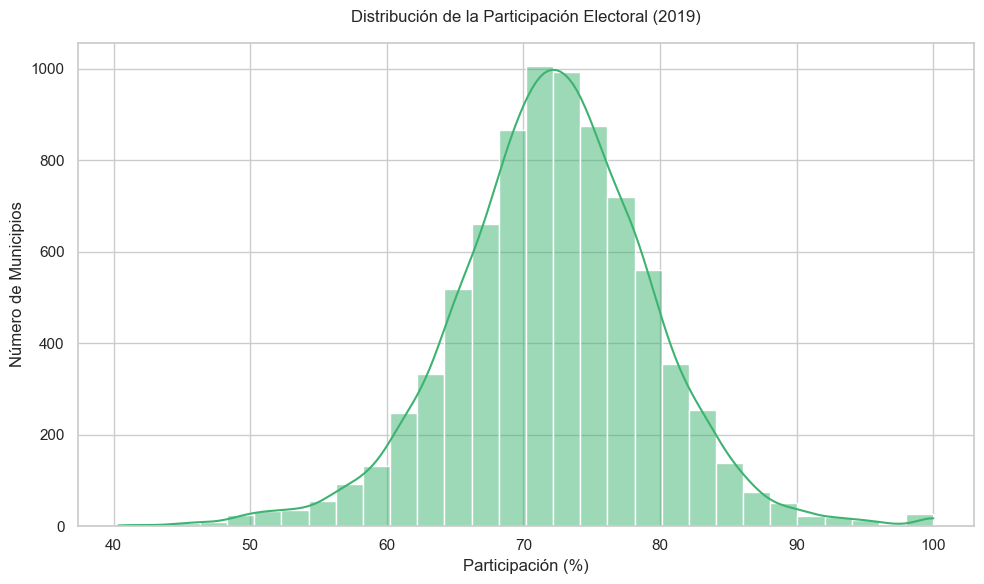

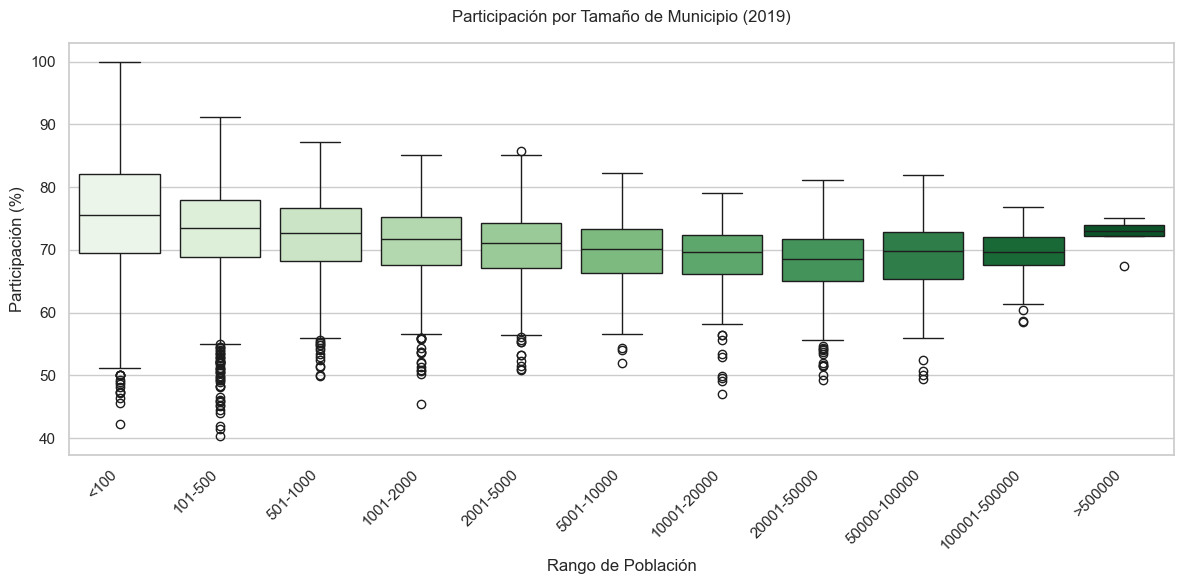

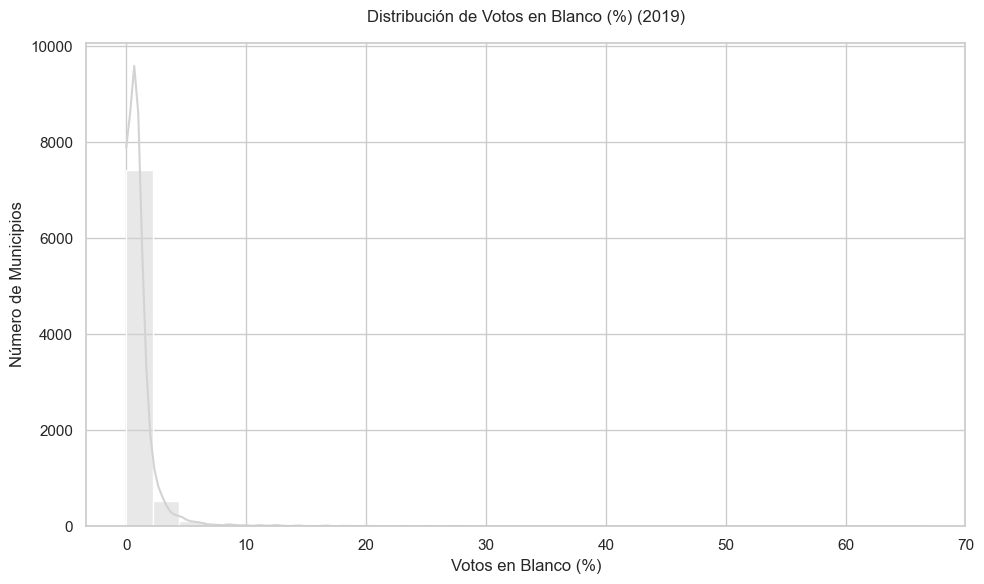

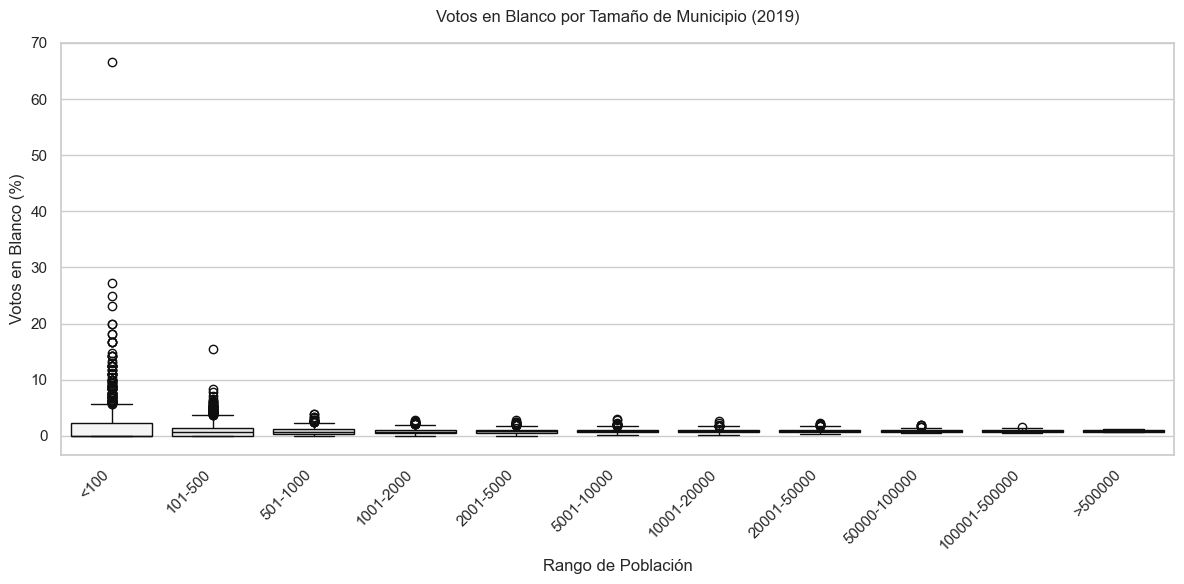

In [64]:
participacion_electoral(df_2019_datos_unificados, "2019")


--- Análisis de Votos en Blanco: Municipios < 100 hab. (2019) ---
Total de municipios analizados: 1352


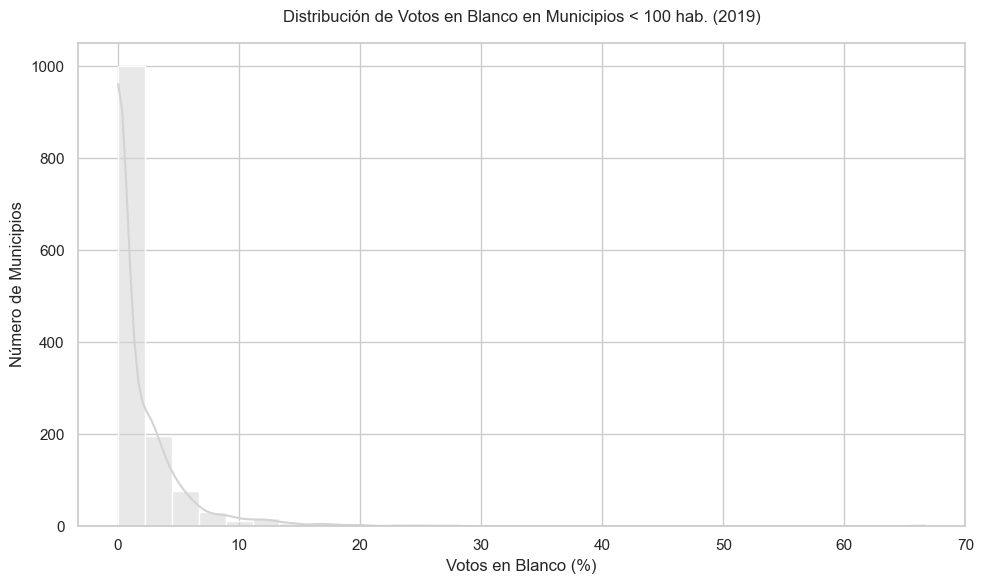

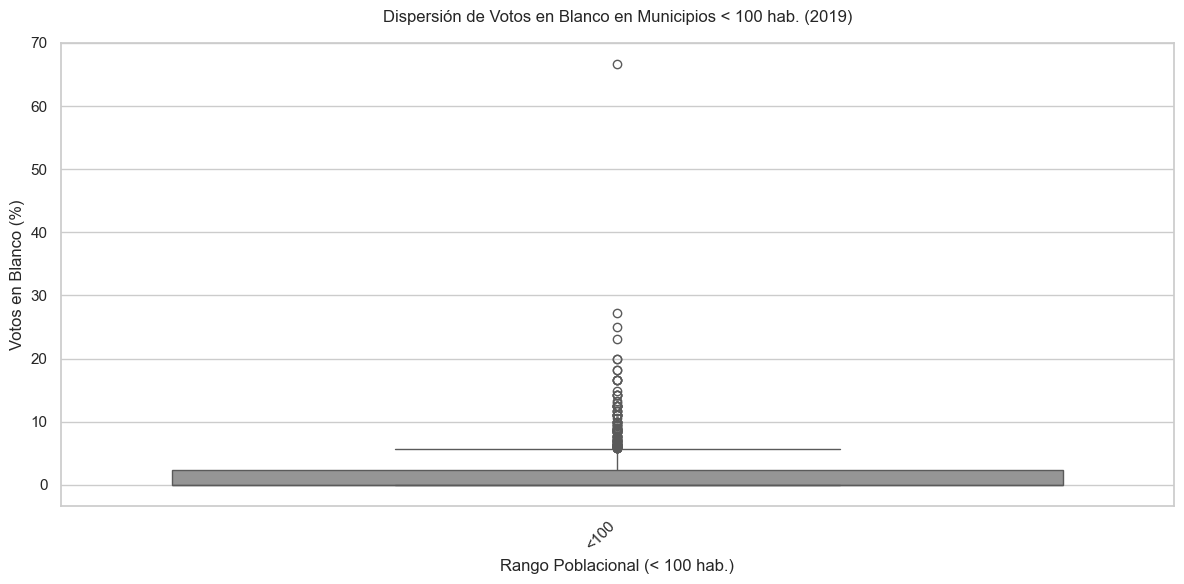

In [65]:
participacion_electoral_100(df_2019_datos_unificados, "2019")

El histograma de participación electoral se observa una distribución que sigue una curva aproximadamente normal, centrada en torno al 70-75%. La gran mayoría de los municipios presentan niveles de movilización ciudadana elevados, con una caída drástica en la frecuencia de municipios que registran una participación inferior al 50% o superior al 90%. Esta concentración sugiere un comportamiento electoral bastante homogéneo en el grueso del territorio nacional, además onservamos municipios con el 100% de participación.

Por su parte, los boxplots muestran una relación inversa entre el tamaño del municipio y la variabilidad de la participación. Los municipios más pequeños (menos de 500 habitantes) presentan los rangos más amplios y los valores máximos de participación más altos, llegando en casos al 100%. A medida que aumenta la población, la participación tiende a estabilizarse y la mediana se sitúa en valores ligeramente inferiores, aunque en las ciudades de más de 500000 habitantes se observa un repunte en la mediana de participación con una dispersión mínima, indicando un comportamiento más predecible en las grandes metrópolis.

El histograma de votos en blanco, muestra un sesgo positivo extremo, donde la inmensa mayoría de los municipios registran menos de un 2-3% de votos en blanco, lo que indica que esta opción de voto es minoritaria y poco frecuente como fenómeno masivo en la mayoría de las localidades españolas.

Los boxplots profundiza en esta tendencia, revelando que la mayor cantidad de outliers se encuentra en los municipios de menor tamaño. En localidades con menos de 100 habitantes, se registran casos excepcionales donde el voto en blanco llega a superar el 60%, un fenómeno que desaparece por completo en municipios de más de 1,000 habitantes. En las poblaciones medianas y grandes, el porcentaje de votos en blanco es notablemente bajo y extremadamente estable, lo que sugiere que el voto de protesta o indecisión bajo esta modalidad es una particularidad estadística de núcleos rurales muy reducidos. Lo que tiene una implicación directa bajo la Ley d'Hondt: al ser el voto en blanco un voto válido, eleva el umbral del 3% necesario para que una candidatura sea considerada en el reparto de escaños. En estos escenarios de alta concentración de voto en blanco, el número de votos requeridos para superar la barrera electoral aumenta, dificultando la entrada de partidos pequeños y favoreciendo indirectamente a las formaciones mayoritarias.

Para evitar el sesgo de selección y la pérdida de representatividad de la 'España Vaciada', se procederá a la imputación de variables socioeconómicas en municipios con secreto estadístico. Se utilizará la estructura de grafo para asignar a los municipios nulos la media ponderada de sus vecinos geográficos, basándose en el principio de autocorrelación espacial.

Pasamos a crear el grafo de vecinos.

In [66]:
gdf, w = generar_grafo_adyacencia()

Cargando grafo de adyacencia existente desde caché...
Grafo cargado con 8131 municipios.


In [67]:
#visualizar_grafo_maestro(gdf, w)

Una vez obtenido el grafo de colindancia municipal, generaremos un dataframe final. En él, imputaremos los valores faltantes de los municipios pequeños utilizando la media de sus municipios limítrofes. Esta decisión se fundamenta en que, al pertenecer a una misma región geográfica, es altamente probable que compartan características similares.


ANÁLISIS DE COHESIÓN VECINAL FILTRADO (2019)
Municipios con datos económicos encontrados en el grafo: 6768
Municipios finales analizados (excluyendo islas resultantes): 6753


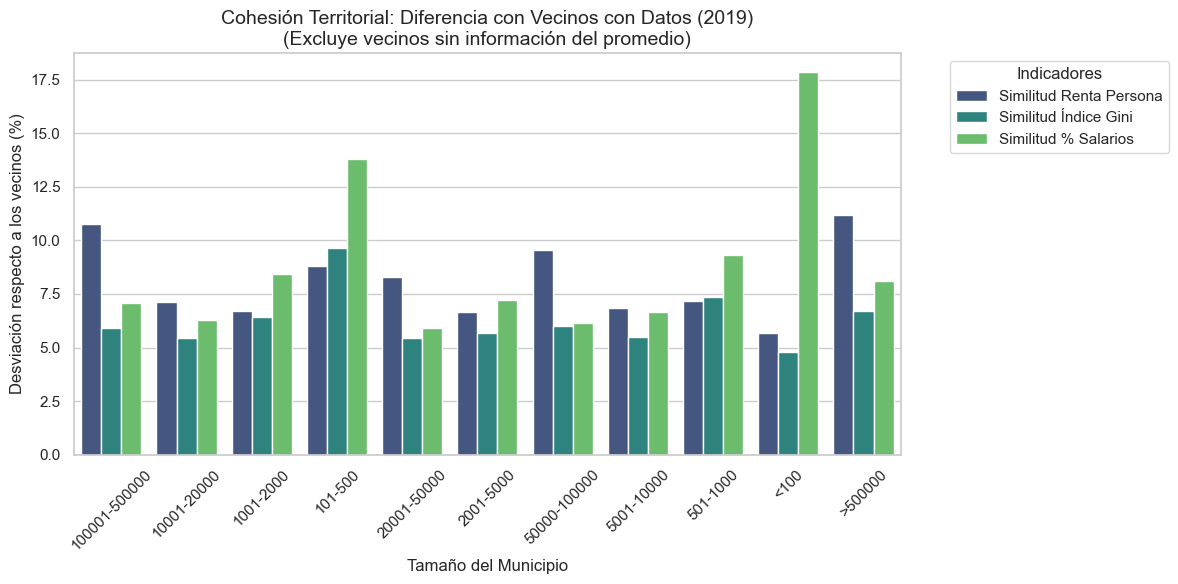

In [68]:
resumen_vecindad = analizar_similitud_vecinal_economica(df_2019_datos_unificados, w, anyo="2019")

A partir de la gráfica de desviación porcentual media respecto a la vecindad, se observa que en los municipios con menos de 100 habitantes existe una cohesión espacial alta en el Índice de Gini, pero una volatilidad crítica (cercana al 18%) en la estructura de ingresos por salarios. Ante esta evidencia de 'islas económicas' en el ámbito rural, se decide implementar una técnica de imputación híbrida basada en grafos: para las variables de baja desviación (Gini y Renta), se utilizará la media de los nodos colindantes siempre que estos pertenezcan a un estrato poblacional similar (evitando así la contaminación por parte de núcleos urbanos cercanos). por el contrario, para las variables de alta dispersión como los salarios, se optará por la mediana provincial del estrato rural. Esta estrategia permite recuperar la representatividad de la 'España Vaciada' en el modelo, garantizando que los datos imputados respeten la realidad regional observada sin introducir el ruido estadístico que generaría una media vecinal simple.

In [69]:
df_2019_completo = imputar_datos_socioeconomicos(df = df_2019_datos_unificados, w = w, anyo = 2019)

INICIANDO PROCESO DE IMPUTACIÓN SOCIOECONÓMICA (2019)
 -> Imputando Grupo B (Fuentes volátiles) mediante mediana provincial rural
 -> Imputando Grupo A (Indicadores estables) mediante adyacencia física...

Resultados de Imputación por Provincia:
 - Albacete: 3 municipios imputados.
 - Alicante/Alacant: 4 municipios imputados.
 - Almería: 1 municipios imputados.
 - Araba/Álava: 51 municipios imputados.
 - Badajoz: 1 municipios imputados.
 - Barcelona: 11 municipios imputados.
 - Bizkaia: 59 municipios imputados.
 - Burgos: 171 municipios imputados.
 - Cantabria: 2 municipios imputados.
 - Castellón/Castelló: 19 municipios imputados.
 - Ciudad Real: 2 municipios imputados.
 - Cuenca: 78 municipios imputados.
 - Cáceres: 7 municipios imputados.
 - Gipuzkoa: 44 municipios imputados.
 - Girona: 4 municipios imputados.
 - Guadalajara: 182 municipios imputados.
 - Huelva: 1 municipios imputados.
 - Huesca: 33 municipios imputados.
 - León: 6 municipios imputados.
 - Lleida: 12 municipios impu

In [70]:
df_2019_completo.isna().sum()

municipio                        0
nombre                           0
provincia                        0
superficie                       0
latitud                          0
longitud                         0
altitud                          0
rango tamaño población           0
poblacion                        0
poblacion hombres                0
poblacion mujeres                0
densidad poblacional             0
indice gini                      7
P80P20                         202
Renta media hogar                0
renta media unidad consumo       7
renta media persona              0
salarios                        51
pensiones                      251
otros ingresos                  51
otras prestaciones             251
desempleo                      251
edad media                    7981
votos totales                    0
votos blancos                    0
participacion                    0
pct_psoe                         0
pct_pp                           0
pct_vox             

Observamos que hemos reducido considerablemente el número de nulos. En el análisis de P80P20, ya vimos que los 202 valores NA corresponden a Navarra, ya que dicha comunidad/provincia no proporciona este dato, por lo tanto, resulta imposible imputarlos mediante vecinos o mediana provincial. Por otro lado, analizaremos los siete municipios a los que no se les ha podido imputar un valor en GINI y/o renta media por unidad de consumo.

In [71]:
municipios_nulos = df_2019_completo[df_2019_completo['indice gini'].isna() | df_2019_completo['renta media unidad consumo'].isna()]
print(f"Municipios con datos faltantes ({len(municipios_nulos)} detectados):")
print(municipios_nulos[['municipio', 'nombre', 'provincia', 'rango tamaño población']])

Municipios con datos faltantes (7 detectados):
    municipio                        nombre    provincia  \
331     01051           Agurain/Salvatierra  Araba/Álava   
332     01001              Alegría-Dulantzi  Araba/Álava   
333     01002                       Amurrio  Araba/Álava   
334     01049                         Añana  Araba/Álava   
337     01037                 Arraia-Maeztu  Araba/Álava   
349     01023                Elvillar/Bilar  Araba/Álava   
366     01039  Moreda de Álava/Moreda Araba  Araba/Álava   

    rango tamaño población  
331             5001-10000  
332              2001-5000  
333            10001-20000  
334                101-500  
337               501-1000  
349                101-500  
366                101-500  


Podemos ver que las siete pertenecen a la comunidad autónoma del País Vasco, la cual, al igual que Navarra, cuenta con un régimen foral propio que puede impedir que los datos de la provincia estén publicadosenel INE.


ANALIZANDO CORRELACIONES (2019)
Variables analizadas: ['superficie', 'poblacion', 'poblacion hombres', 'poblacion mujeres', 'densidad poblacional', 'indice gini', 'P80P20', 'Renta media hogar', 'renta media unidad consumo', 'renta media persona', 'salarios', 'pensiones', 'otros ingresos', 'otras prestaciones', 'desempleo', 'edad media', 'votos totales', 'votos blancos', 'participacion', 'pct_psoe', 'pct_pp', 'pct_vox', 'pct_cs', 'pct_up_sumar', 'pct_erc', 'pct_jxcat', 'pct_cup', 'pct_pnv', 'pct_ehbildu', 'pct_bng', 'pct_cc', 'pct_prc', 'pct_naplus', 'pct_teruel', 'pct_otros']
Registros completos utilizados: 143


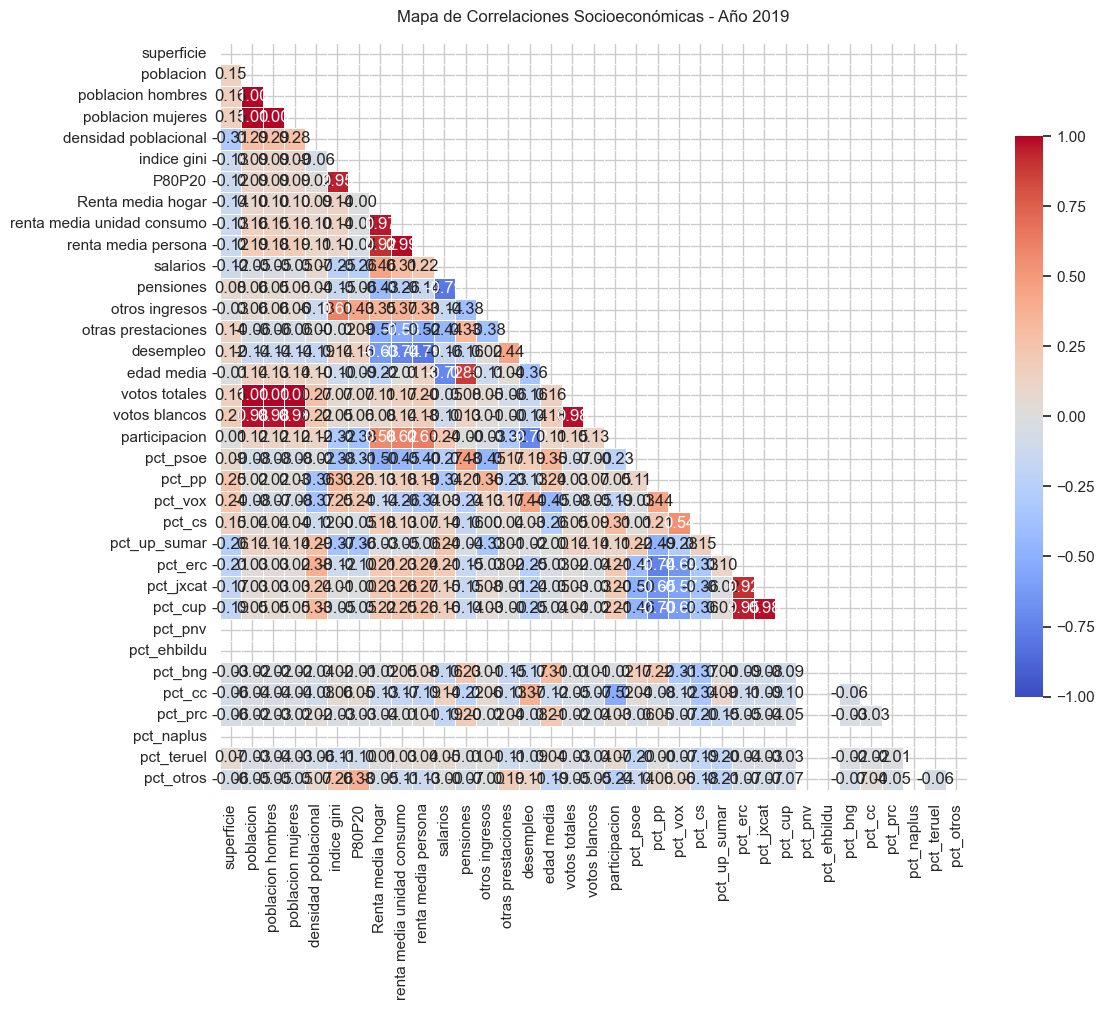

In [72]:
analizar_correlaciones_eda(df_2019_completo, anyo=2019)

Se ha identificado una fuerte multicolinealidad entre los indicadores de desigualdad, lo que justifica la elección estratégica del Índice de Gini como métrica principal frente al ratio P80/P20, dado que el primero ofrece una visión más completa de la distribución de la renta y tenemos estos datos para Navarra. De igual modo, en la dimensión de riqueza, la renta media por persona se consolida como la variable de referencia al presentar una correlación entre el 0.80 y 0.96 con el resto de indicadores de renta por hogar o unidad de consumo, lo que permite simplificar la arquitectura del modelo sin pérdida de información significativa.

Esta estructura de ingresos se ve profundamente influenciada por la situación del mercado laboral, donde el desempleo muestra una relación negativa moderada con la renta media. Mantener ambas dimensiones por separado resulta esencial para el éxito de la investigación, ya que permite al algoritmo de Gradient Boosting diferenciar entre la precariedad económica derivada de la falta de empleo y aquella de carácter estructural o histórico. Por otra parte, la relación observada entre riqueza y desigualdad es notablemente baja, lo que confirma empíricamente que un municipio con altos niveles de renta no es necesariamente más igualitario, reforzando la necesidad de incluir ambos predictores para capturar la complejidad social de cada territorio de manera independiente.

Uno de los hallazgos más determinantes de este análisis es la polarización económica entre municipios activos y envejecidos, reflejada en la potente correlación negativa entre el peso de los salarios y las pensiones. Aunque estadísticamente estas variables podrían parecer inversas, se ha optado por conservar ambas dentro del entrenamiento para dotar al algoritmo de una mayor capacidad de segmentación demográfica. Pues permite identificar perfiles municipales específicos donde la inercia del voto puede estar ligada a las demandas de la población activa o, por el contrario, a la seguridad económica de los sectores jubilados. En conjunto, esta selección final garantiza un equilibrio entre parsimonia y poder predictivo, optimizando la futura interpretación de los resultados mediante el análisis de importancia de características.

Por lo tanto, se han seleccionado el Índice de Gini por su mayor robustez estructural frente al P80/P20, la renta media por persona para evitar la redundancia estadística entre los distintos niveles de ingreso, el binomio de salarios y pensiones para segmentar el perfil sociodemográfico activo o jubilado del municipio, y el desempleo como indicador crítico de precariedad que la renta por sí sola no logra capturar.